
# 10 - Generation data analysis, interpretation and discussion

We examine the seven configurations one at a time, then compare only the planned paired groups. Our conclusions at the end relate these results to the four research questions in the dissertation proposal. This is a working analysis of the fixed expert scores, not a second scoring exercise.

We use five published result files and two fixed configuration files. We check their file hashes before reading the tables. This notebook shows counts, percentages, scores and test results. It does not open private questions, reference answers, generated answers, scoring notes or question IDs. The 140 scores are final for this analysis. Professor Peña Olarte's later comments about the overall system are separate from those scores.

The dissertation handbook asks us to show and explain results clearly and link them to the research questions and earlier chapters. We keep **what we saw**, **how we compared it** and **what we can conclude** close together. This is our analysis workspace. We check any final dissertation text against the assessment rules and original sources.



## 0. Data boundary and definitions

All seven configurations answer the same 20 checked, challenging geotechnical questions, once per question. Our main measure is fully correct answers divided by 20. An answer with no visible text still counts among those 20 and gets zero for correctness. We also report how many answers have visible text, which we call **completion**. The five other scores use a 0–2 scale for formulas, calculations, units, clarity and matching the task. We use a score only where the approved reference says it applies.

Each incorrect answer gets one main error type. We count unsupported claims separately, so this count can overlap with errors. The baseline paper uses grounding, conceptual and calculation errors. Our agreed scoring also records deficiency, no visible answer and other. A visible answer, a good score on one 0–2 measure or zero flagged unsupported claims does not automatically mean the whole answer is correct.

We use Wilson 95% intervals to show how uncertain a correct/20 percentage can be with only 20 questions. This method assumes a type of random sampling, but our fixed set of hard questions was chosen on purpose. We cannot use the interval to claim how well a model works on all questions or on repeated runs.


In [1]:

from __future__ import annotations

import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from io import BytesIO
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "configs/generation-evaluation-config.json").is_file():
    raise FileNotFoundError("The thesis repository root was not found.")
sys.path.insert(0, str(ROOT / "src"))
from geotech_rag.generation_result_figures import INPUT_SHA256, JUDGMENTS_SHA256, load_public_tables

CONFIG_SHA256 = {
    "configs/generation-evaluation-config.json": "55e1e709a5bd31486656668301d8e44c470673f14d745d7cfaae4a6c154d2667",
    "configs/generation-response-evaluation-config.json": "ffc7e54e44df830cadf3b0fddfaefdc34c0ce43fad4e99c946d7556165e3a824",
}
for relative, expected in CONFIG_SHA256.items():
    assert hashlib.sha256((ROOT / relative).read_bytes()).hexdigest() == expected, relative

# This function checks all five published aggregate fingerprints and their denominators.
load_public_tables(ROOT)
generation = json.loads((ROOT / "configs/generation-evaluation-config.json").read_text(encoding="utf-8"))
evaluation = json.loads((ROOT / "configs/generation-response-evaluation-config.json").read_text(encoding="utf-8"))
metrics = json.loads((ROOT / "results/metrics/generation-evaluation.json").read_text(encoding="utf-8"))
assert metrics["fingerprints"]["judgments_sha256"] == JUDGMENTS_SHA256
assert metrics["score_set_status"] == "final_for_analysis"
assert metrics["professor_feedback_status"] == "preliminary"

def csv_table(name):
    return pd.read_csv(ROOT / "results/tables" / name)

summary = csv_table("generation-evaluation.csv")
secondary = csv_table("generation-secondary-scores.csv")
errors = csv_table("generation-error-distribution.csv")
pairwise = csv_table("generation-pairwise-comparisons.csv")
condition_settings = {r["condition_id"]: r for r in generation["conditions"]}
CONDITIONS = tuple(condition_settings)
FIELDS = ("formula_integration", "calculation_correctness", "unit_correctness",
          "explanation_clarity", "task_adaptability")
assert CONDITIONS == ("P0", "P1", "P2", "P3", "M1", "M2", "M3")
assert list(summary["condition"]) == list(CONDITIONS)
assert len(summary) == 7 and len(secondary) == 35 and len(errors) == 42 and len(pairwise) == 10
assert sum(summary["correct"]) == 51 and sum(summary["visible_responses"]) == 131
print("Verified public aggregates:", len(INPUT_SHA256))
print("Verified frozen configurations:", len(CONFIG_SHA256))
print("Configurations:", ", ".join(CONDITIONS))
print("Judgments: 140; visible responses: 131; absent responses: 9")
print("Private per-question records accessed: False")


Verified public aggregates: 5
Verified frozen configurations: 2
Configurations: P0, P1, P2, P3, M1, M2, M3
Judgments: 140; visible responses: 131; absent responses: 9
Private per-question records accessed: False



### Reading the configuration tables

For each configuration, we first check which model was requested, whether retrieval was enabled, how many passages were requested, and which generation controls were actually sent. A blank temperature or `top_p` for M2/M3 means that parameter was **omitted**, not set to zero. The common generation policy requested one response per question and a logical maximum of 2,000 output tokens; the response-scoring policy was already frozen before the model answers were judged.

The first results table shows correct and visible answers out of 20, Wilson limits and unsupported-claims flags. The next table shows average and middle scores, how many questions each score applies to and the counts at 0, 1 and 2. The error table shows all six error types, even when the count is zero. These are summaries for each configuration; we do not show answer text or individual scores here.


In [2]:

def condition_tables(condition):
    assert condition in CONDITIONS
    setting = condition_settings[condition]
    presented = {
        "condition": condition,
        "study_role": setting["study_role"],
        "requested_model": setting["model_id"],
        "model_reference_type": setting["model_reference_type"],
        "retrieval_enabled": setting["retrieval_enabled"],
        "retrieval_k": setting["retrieval_depth_k"],
        "temperature": setting["temperature"] if setting["temperature"] is not None else "omitted",
        "top_p": setting["top_p"] if setting["top_p"] is not None else "omitted",
        "reasoning_effort": setting["reasoning_effort"] or "omitted",
        "endpoint": generation["request_policy"]["endpoint"],
        "output_token_limit": generation["request_policy"]["logical_max_output_tokens"],
        "prompt_id": generation["prompt"]["prompt_id"],
    }
    profile = summary.loc[summary["condition"].eq(condition)]
    scores = secondary.loc[secondary["condition"].eq(condition)]
    error_rows = errors.loc[errors["condition"].eq(condition)]
    assert len(profile) == 1 and len(scores) == 5 and len(error_rows) == 6
    assert int(profile.iloc[0]["correct"] + error_rows["count"].sum()) == 20
    assert int(profile.iloc[0]["no_visible_answers"] + profile.iloc[0]["visible_responses"]) == 20
    print("Frozen settings")
    display(pd.DataFrame([presented]).T.rename(columns={0: "value"}))
    print("Outcome: all rates have the same 20-question denominator")
    display(profile.reset_index(drop=True))
    print("Secondary criteria: frozen applicable denominators")
    display(scores.drop(columns="condition").reset_index(drop=True))
    print("Primary errors: one category per incorrect response")
    display(error_rows.drop(columns="condition").reset_index(drop=True))

def show_plot(fig):
    """Render a PNG explicitly because the figure module uses Matplotlib Agg."""
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=180, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


def condition_plot(condition):
    row = summary.set_index("condition").loc[condition]
    err = errors.loc[errors["condition"].eq(condition)]
    score_rows = secondary.loc[secondary["condition"].eq(condition)]
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.7), layout="constrained")
    correct, visible = int(row["correct"]), int(row["visible_responses"])
    axes[0].bar(["Correct", "Visible"], [correct, visible], color=["#087f8c", "#53677b"])
    axes[0].set_ylim(0, 21)
    axes[0].set_ylabel("Count out of 20")
    axes[0].set_title("Correctness and completion")
    for x, value in enumerate((correct, visible)):
        axes[0].text(x, min(value + 0.25, 20.25), f"{value}/20", ha="center", fontsize=10)
    used = err.loc[err["count"].gt(0)]
    if len(used):
        axes[1].barh(used["primary_error_category"].str.replace("_", " "), used["count"], color="#b65848")
        axes[1].invert_yaxis()
        axes[1].set_xlim(0, max(10, int(used["count"].max()) + 1))
        for y, value in enumerate(used["count"]):
            axes[1].text(int(value) + .1, y, str(value), va="center")
    else:
        axes[1].text(.5, .5, "No incorrect response", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Primary error types")
    axes[1].set_xlabel("Responses")
    axes[2].barh(score_rows["field"].str.replace("_", " "), score_rows["mean_score"], color="#265f8d")
    axes[2].invert_yaxis()
    axes[2].set_xlim(0, 2.15)
    axes[2].set_xlabel("Mean score (0–2)")
    axes[2].set_title("Secondary scores")
    for y, (mean, n) in enumerate(zip(score_rows["mean_score"], score_rows["applicable_questions"])):
        axes[2].text(min(float(mean) + .03, 2.02), y, f"{mean:.2f} (n={n})", va="center", fontsize=8)
    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle(f"{condition}: 20 fixed benchmark questions", fontweight="bold")
    show_plot(fig)

def score_distribution_plot(condition):
    """Show how many answers received each 0–2 score on applicable questions."""
    rows = secondary.loc[secondary["condition"].eq(condition)]
    assert len(rows) == 5
    fig, ax = plt.subplots(figsize=(9, 4.2), layout="constrained")
    y = np.arange(len(rows))
    left = np.zeros(len(rows))
    for score, color in ((0, "#bc5845"), (1, "#e2a54b"), (2, "#087f8c")):
        values = rows[f"score_{score}_count"].to_numpy(dtype=int)
        ax.barh(y, values, left=left, height=.65, color=color, label=f"Score {score}")
        for position, count in enumerate(values):
            if count >= 2:
                ax.text(left[position] + count / 2, position, str(count),
                        ha="center", va="center", color="#1b2730", fontsize=9)
        left += values
    assert np.array_equal(left, rows["applicable_questions"].to_numpy(dtype=int))
    ax.set_yticks(y, rows["field"].str.replace("_", " "))
    ax.invert_yaxis()
    ax.set_xlim(0, 21)
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_xlabel("Number of applicable questions (17, 18 or 20)")
    ax.set_title(f"{condition}: counts at each secondary score")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    show_plot(fig)


def condition_strata(condition):
    # Public strata were pooled where original categories were too small.
    for field, rows in metrics["adaptability_strata"].items():
        print("Descriptive", field, "strata (approved, pooled labels only)")
        display(pd.DataFrame([row for row in rows if row["condition"] == condition]))


## 1. Configuration P0: settings and role

We use the fixed GPT-4 snapshot without retrieval (k=0), temperature 0.1 and top-p 1.0. This is the zero-context control.

We retain the same 20 benchmark questions, approved references and expert-scoring rubric as in every other configuration. The settings table below comes directly from the frozen generation configuration; the next tables load this configuration's rows from the published aggregate files. We read the findings descriptively here and reserve significance claims for the matched-question comparisons after all seven sections.


In [3]:
condition_tables("P0")
condition_strata("P0")


Frozen settings


,value
condition,P0
study_role,paper_baseline_zero_context_control
requested_model,gpt-4-0613
model_reference_type,fixed_snapshot
retrieval_enabled,False
retrieval_k,0
temperature,0.1
top_p,1.0
reasoning_effort,omitted
endpoint,chat.completions


Outcome: all rates have the same 20-question denominator


,condition,gradable_questions,correct,accuracy,wilson95_lower,wilson95_upper,visible_responses,completion_rate,no_visible_answers,unsupported_claims_count
0,P0,20,2,0.1,0.027866,0.301034,20,1.0,0,15


Secondary criteria: frozen applicable denominators


...

,primary_error_category,count,denominator
0,grounding,7,20
1,conceptual,6,20
2,calculation,3,20
3,deficiency,2,20
4,no_visible_answer,0,20
5,other,0,20


Descriptive cognitive_level strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,P0,0,1.1,10,Apply
1,P0,2,1.2,10,not_recorded_in_reference


Descriptive problem_type strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,P0,2,1.2,10,not_recorded_in_reference
1,P0,0,1.1,10,recorded_not_stratified


### P0: within-configuration view

The three panels separate full correctness, visible-answer completion, the **primary** categories for incorrect answers and the means of the five 0–2 criteria. The category totals plus correct answers must equal 20. Each criterion retains its own applicable question denominator. This view helps identify where a configuration succeeds or fails; a difference between configurations still needs a paired comparison.


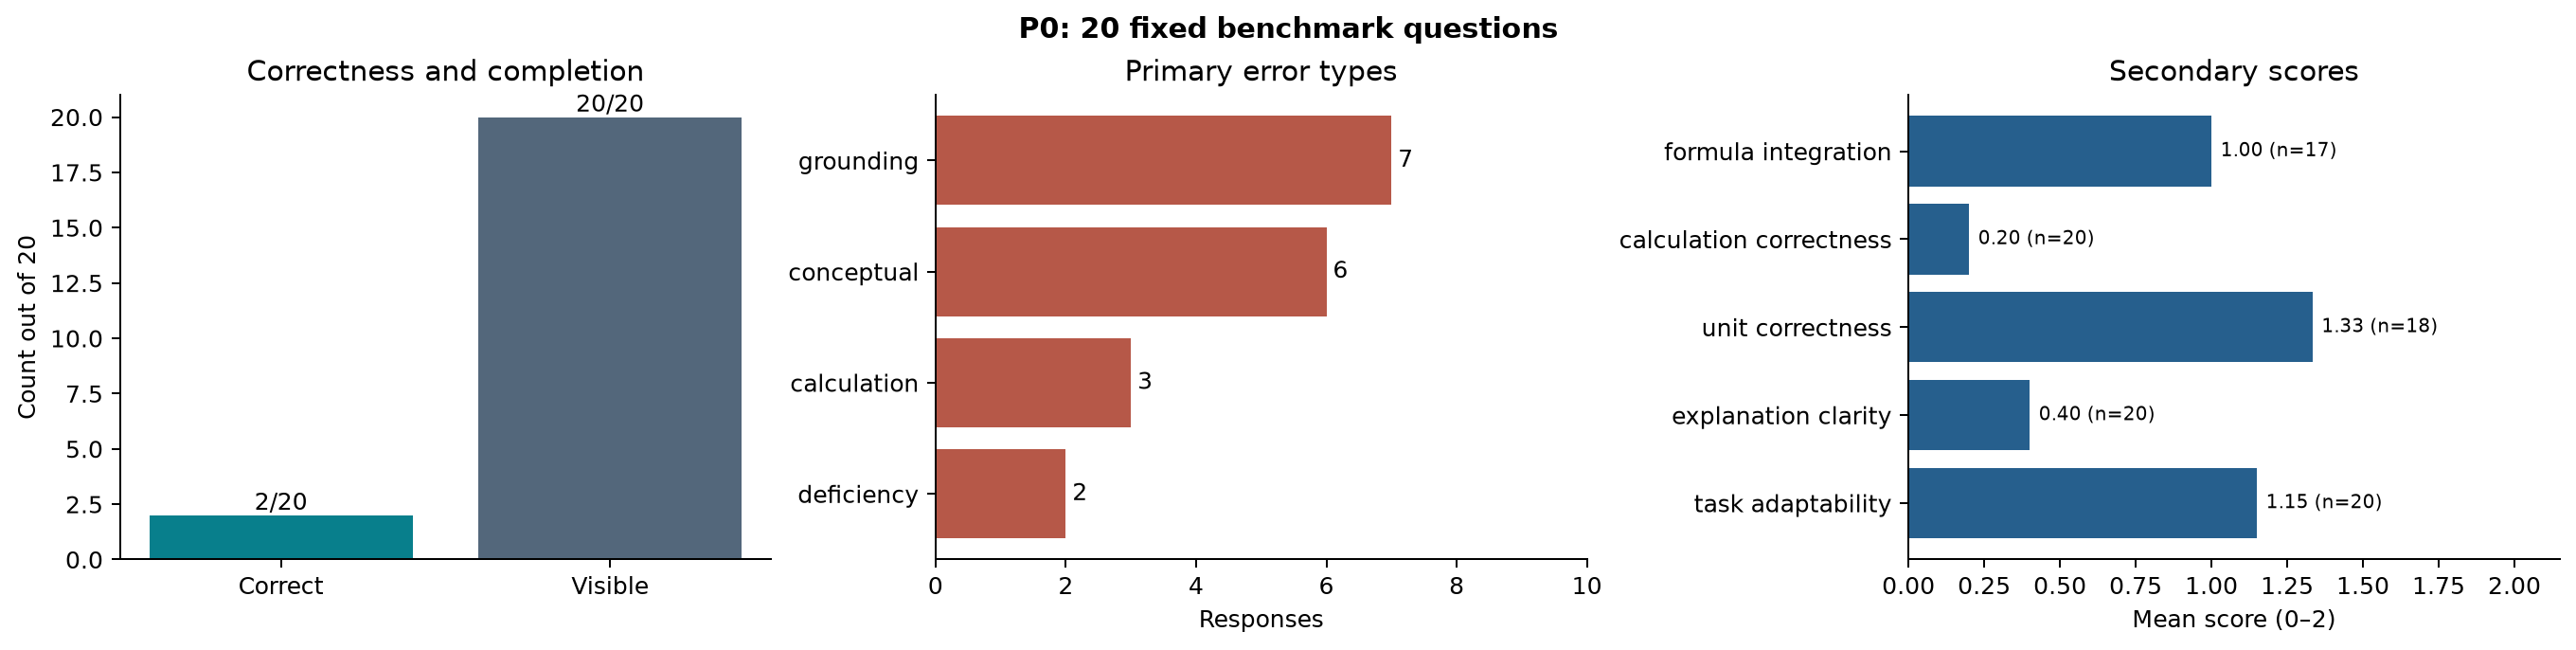

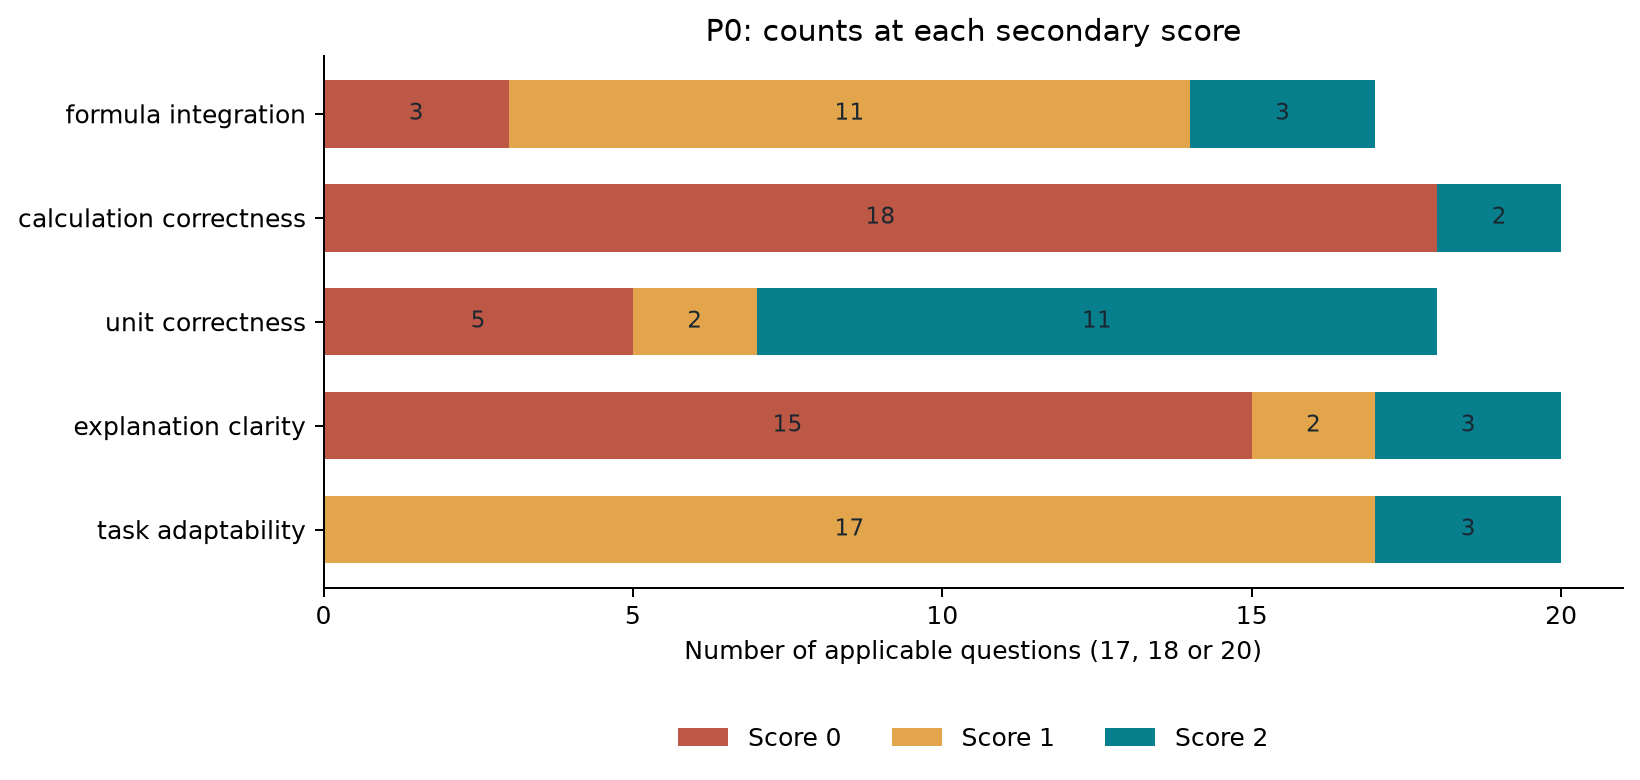

In [4]:
condition_plot("P0")
score_distribution_plot("P0")


### P0: what we learn from the figures and tables

1. **Visible does not mean correct.** All 20 P0 answers have visible text, but only 2/20 are fully correct. We can see this gap in the first plot. P0 completed every request but solved only 10% of these benchmark questions.
2. **Most incorrect answers have grounding or conceptual errors.** There are 18 incorrect answers. Seven have grounding as their main error and six have a conceptual error: 13/18 in these two groups, compared with three calculation errors and two deficiencies. The error plot shows this pattern. The error categories describe the main failure in each answer; they do not prove why the model made it.
3. **Partial scores do not rescue an incorrect solution.** The score-distribution plot shows 18/20 scores of zero for calculation correctness and 15/20 scores of zero for clarity. Formula use has 11/17 scores of one and only 3/17 scores of two. Units do better, with 11/18 scores of two. The mean-score plot is another way to view the same numbers, but the counts show where the weak scores come from. We should discuss formulas, units and full correctness separately.
4. **Task relevance and correctness are different.** Task adaptability has 17/20 scores of one and three scores of two, while full correctness remains 2/20. This suggests that an answer can be partly related to the question yet still fail to provide a correct solution.
5. **Unsupported claims need their own reading.** We have 15/20 unsupported-claims flags. These can overlap with the 18 incorrect answers, so we do not add the two counts together.

For the labelled cognitive-level group, none of the ten `Apply` questions is correct, while two of the ten without a recorded cognitive label are correct. The problem-type grouping also splits the questions into ten labelled and ten unlabelled cases. Because half the labels are missing and the named problem types are combined, we cannot claim an effect of a particular cognitive level or problem type. P0 alone also cannot tell us whether retrieval helps; that needs the paired P0–P1 comparison.


### P0 - conclusions from the 20 questions

* **P0 returned an answer every time, but rarely gave a fully correct solution.** All 20 answers had visible text, while only 2/20 were judged correct. Completion was 100%; correctness was 10%. This is why we report the two measures separately.

* **Grounding and conceptual errors were the main recorded problems.** Of the 18 incorrect answers, 7 had a grounding error and 6 had a conceptual error as their *primary* category. Together, that is 13/18 incorrect answers. Three had a calculation error and two had a deficiency. “Grounding” here means a problem such as choosing an unsuitable equation or assumption; it does not, by itself, prove that the lack of retrieval caused the error.

* **Calculations and explanations were weak across the full set.** Calculation correctness scored zero on 18/20 answers, and explanation clarity scored zero on 15/20. This does not conflict with only **three** answers having “calculation” as their primary error: an answer can have a bad or missing calculation while its *main* error is classified as grounding or conceptual.

* **Some parts of an answer could be useful without the whole answer being correct.** Formula integration scored 1 on 11/17 applicable questions, meaning partly correct use, but only 3/17 received the top score. Units received the top score on 11/18 applicable questions. A suitable unit or partly correct formula cannot make an incorrect final solution fully correct.

* **The answers often related to the task without solving it.** Task adaptability scored 1 on 17/20 answers and 2 on three answers, yet only two answers were fully correct. We should keep “responds to the task” separate from “solves the task”.

* **Unsupported claims add another concern.** Fifteen of the 20 answers were flagged for an unsupported claim. This flag can overlap with the primary error categories, so we cannot add 15 to the error counts.

The subgroup table shows 0/10 correct among questions labelled `Apply` and 2/10 among questions with no cognitive label. Half the labels are missing, so **we cannot conclude that `Apply` questions are harder** from this split.

**Overall:** P0 is a useful no-retrieval control because it consistently produced visible answers, but its solutions were usually incorrect or incomplete on this benchmark. We cannot conclude whether adding retrieval helps until we compare P0 with P1 on the **same questions**. We also cannot explain the exact mistakes in individual answers from these public summary tables alone.

## 2. Configuration P1: settings and role

We use the same fixed GPT-4 snapshot at temperature 0.1 and top-p 1.0 with FAISS retrieval enabled at k=30. This is our RAG reference for the controlled retrieval, temperature and model families.

We retain the same 20 benchmark questions, approved references and expert-scoring rubric as in every other configuration. The settings table below comes directly from the frozen generation configuration; the next tables load this configuration's rows from the published aggregate files. We read the findings descriptively here and reserve significance claims for the matched-question comparisons after all seven sections.


In [5]:
condition_tables("P1")
condition_strata("P1")


Frozen settings


,value
condition,P1
study_role,paper_baseline_rag_temperature_0_1
requested_model,gpt-4-0613
model_reference_type,fixed_snapshot
retrieval_enabled,True
retrieval_k,30
temperature,0.1
top_p,1.0
reasoning_effort,omitted
endpoint,chat.completions


Outcome: all rates have the same 20-question denominator


,condition,gradable_questions,correct,accuracy,wilson95_lower,wilson95_upper,visible_responses,completion_rate,no_visible_answers,unsupported_claims_count
0,P1,20,3,0.15,0.052369,0.360419,20,1.0,0,14


Secondary criteria: frozen applicable denominators


...

,primary_error_category,count,denominator
0,grounding,5,20
1,conceptual,7,20
2,calculation,2,20
3,deficiency,3,20
4,no_visible_answer,0,20
5,other,0,20


Descriptive cognitive_level strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,P1,1,1.2,10,Apply
1,P1,2,1.3,10,not_recorded_in_reference


Descriptive problem_type strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,P1,2,1.3,10,not_recorded_in_reference
1,P1,1,1.2,10,recorded_not_stratified


### P1: within-configuration view

The three panels separate full correctness, visible-answer completion, the **primary** categories for incorrect answers and the means of the five 0–2 criteria. The category totals plus correct answers must equal 20. Each criterion retains its own applicable question denominator. This view helps identify where a configuration succeeds or fails; a difference between configurations still needs a paired comparison.


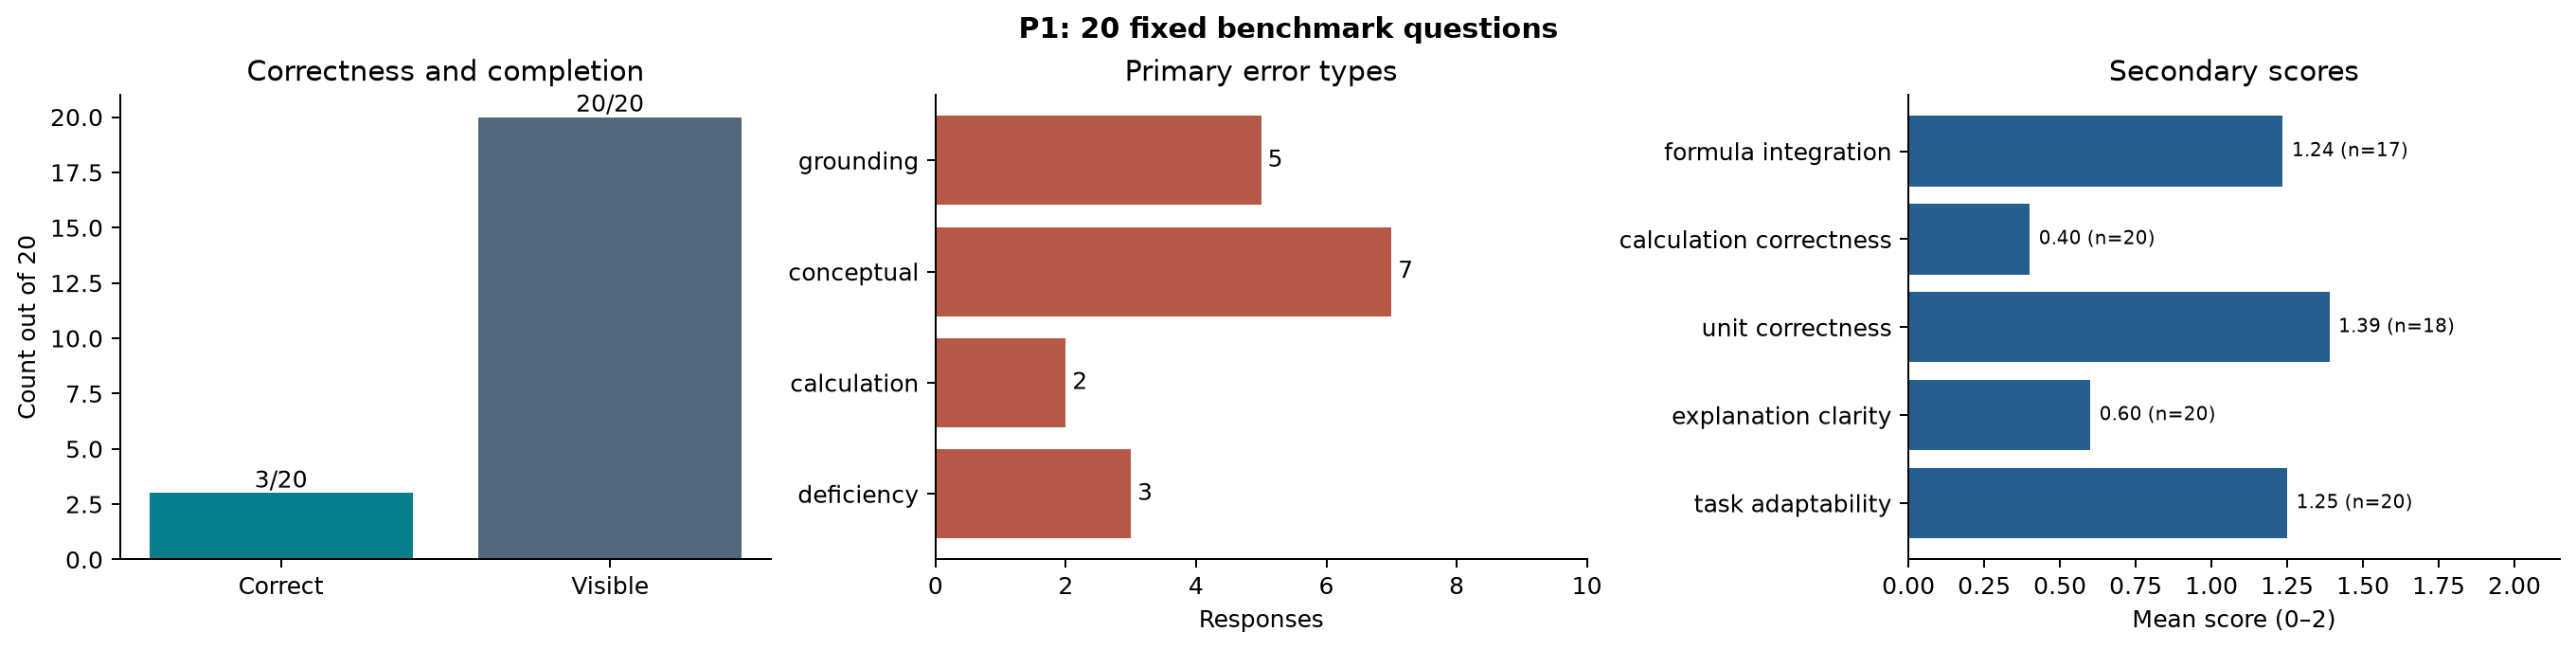

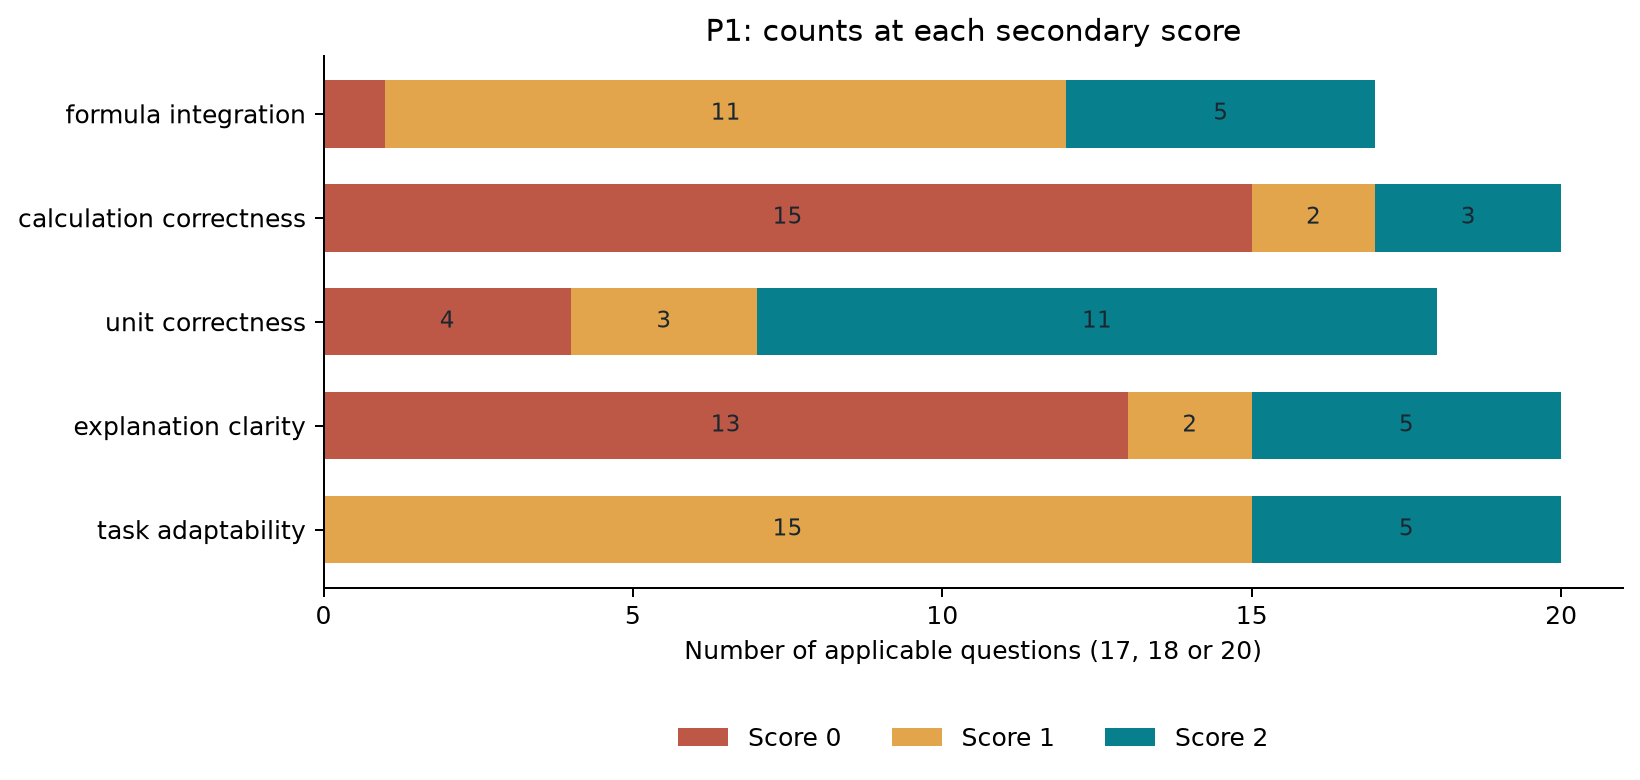

In [6]:
condition_plot("P1")
score_distribution_plot("P1")


### P1: observed findings and interpretation

We observe 3 correct answers out of 20 (15%) and 20 visible responses. Of the 17 incorrect answers, 7 are conceptual errors, 5 grounding, 2 calculation and 3 deficiency. Formula integration averages 1.24/2 across 17 applicable questions, calculation correctness 0.40/2 and clarity 0.60/2; 14 responses carry an unsupported-claims flag. Retrieval is enabled at k=30. We evaluate whether the one-answer improvement over P0 is meaningful using the paired P0–P1 results later, rather than treating 15% versus 10% as independent samples.

The problem-type and cognitive-level groups above only describe the data. Ten questions have no recorded label. The other ten cognitive labels are all `Apply`, and the problem types have to be combined because their groups are too small. We cannot draw a conclusion about one named problem type from these grouped numbers.


### P1 - conclusions from the 20 questions

- **P1 returned visible text for every question, but only 3/20 answers were fully correct.** Completion was 100% and correctness was 15%. The Wilson 95% interval is about 5.2%-36.0%, which shows how uncertain a percentage based on only 20 questions can be. These questions were selected as a hard benchmark, so the interval does not tell us P1's accuracy on all geotechnical questions.

- **Conceptual and grounding errors were the most common main errors.** Of the 17 incorrect answers, seven had a conceptual error and five had a grounding error. Together, these account for 12/17 incorrect answers. Two had a calculation error and three had a deficiency. These are the main error labels; they do not tell us the full sequence of mistakes in each answer.

- **Formula use was often partly correct, but calculations remained weak.** Formula integration scored 1 on 11/17 applicable questions and 2 on five. Calculation correctness scored 0 on 15/20 questions. Selecting or partly using a formula was often not enough to produce a correct calculation and final solution.

- **Units were stronger than the overall solutions.** Unit correctness scored 2 on 11/18 applicable questions, while only 3/20 complete answers were correct. The unit score checks one part of an answer; a suitable unit does not make an incorrect value, method or explanation correct.

- **Most explanations still had problems.** Clarity scored 0 on 13/20 answers, 1 on two and 2 on five. Task adaptability was less severe: 15 answers scored 1 and five scored 2. The answers could relate to the task while still being unclear or failing to solve it.

- **Unsupported claims were common.** Fourteen of the 20 answers were flagged. This count can overlap with the primary error types, so we report it separately.

One of the ten questions labelled `Apply` was correct, compared with two of the ten questions without a recorded cognitive label. Because half the labels are missing, and the named problem types are grouped together, we cannot draw a conclusion about P1's performance on a specific problem type or cognitive level.

**Overall:** P1 is the GPT-4 RAG reference configuration: retrieval was enabled at k=30, and it answered every question visibly. Its 3/20 correctness result and the concentration of conceptual, grounding, calculation and clarity problems show that the retrieved setup was still unreliable on this benchmark. P1 alone cannot tell us whether retrieval improved the answers. We will assess that with the paired P0–P1 comparison after the individual configuration sections.

## 3. Configuration P2: settings and role

We keep P1's fixed model and retrieval k=30 and set temperature to 0.5, with top-p 1.0.

We retain the same 20 benchmark questions, approved references and expert-scoring rubric as in every other configuration. The settings table below comes directly from the frozen generation configuration; the next tables load this configuration's rows from the published aggregate files. We read the findings descriptively here and reserve significance claims for the matched-question comparisons after all seven sections.


In [7]:
condition_tables("P2")
condition_strata("P2")


Frozen settings


,value
condition,P2
study_role,paper_baseline_rag_temperature_0_5
requested_model,gpt-4-0613
model_reference_type,fixed_snapshot
retrieval_enabled,True
retrieval_k,30
temperature,0.5
top_p,1.0
reasoning_effort,omitted
endpoint,chat.completions


Outcome: all rates have the same 20-question denominator


,condition,gradable_questions,correct,accuracy,wilson95_lower,wilson95_upper,visible_responses,completion_rate,no_visible_answers,unsupported_claims_count
0,P2,20,3,0.15,0.052369,0.360419,20,1.0,0,15


Secondary criteria: frozen applicable denominators


...

,primary_error_category,count,denominator
0,grounding,7,20
1,conceptual,3,20
2,calculation,3,20
3,deficiency,3,20
4,no_visible_answer,0,20
5,other,1,20


Descriptive cognitive_level strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,P2,1,1.1,10,Apply
1,P2,2,1.4,10,not_recorded_in_reference


Descriptive problem_type strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,P2,2,1.4,10,not_recorded_in_reference
1,P2,1,1.1,10,recorded_not_stratified


### P2: within-configuration view

The three panels separate full correctness, visible-answer completion, the **primary** categories for incorrect answers and the means of the five 0–2 criteria. The category totals plus correct answers must equal 20. Each criterion retains its own applicable question denominator. This view helps identify where a configuration succeeds or fails; a difference between configurations still needs a paired comparison.


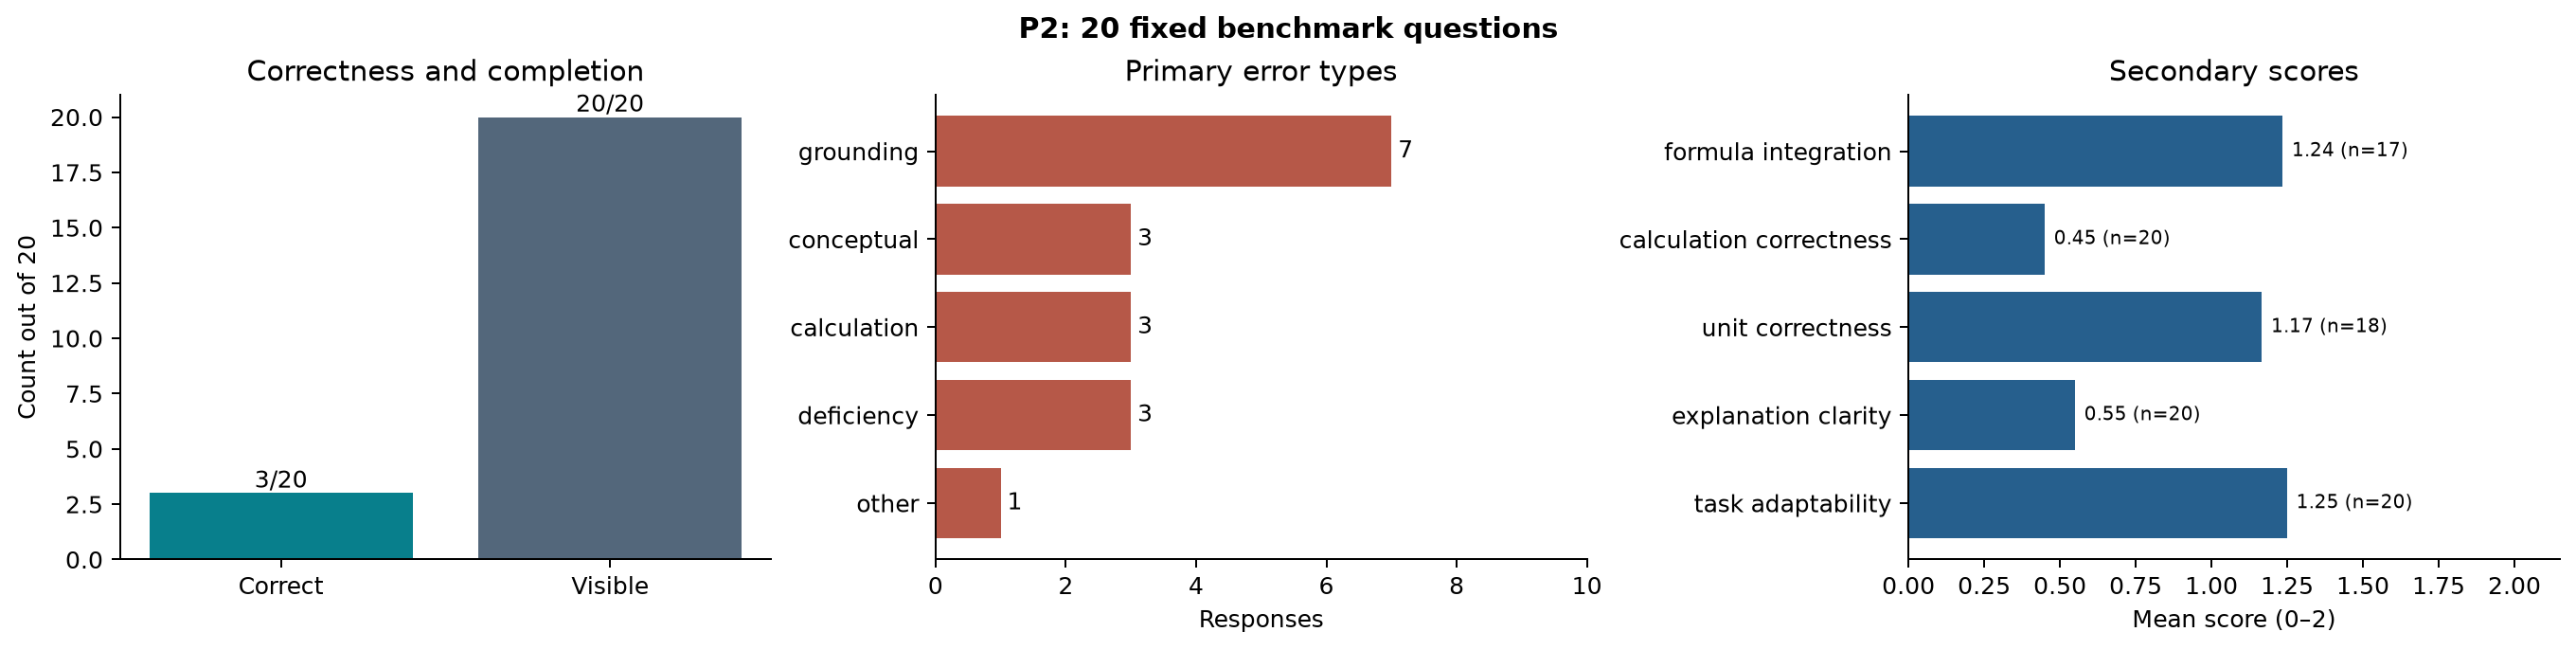

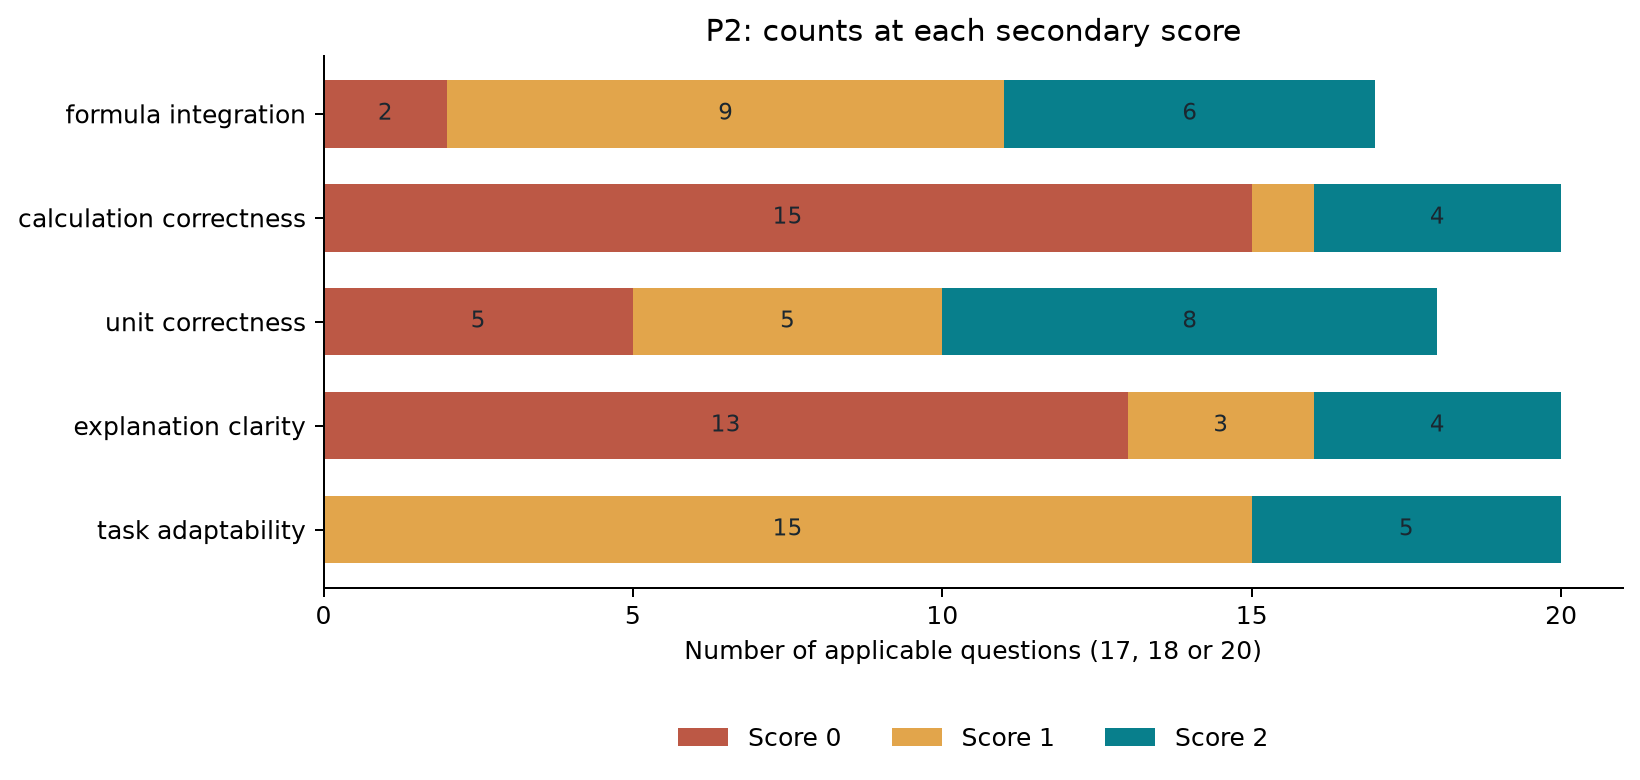

In [8]:
condition_plot("P2")
score_distribution_plot("P2")


### P2: observed findings and interpretation

We observe 3 correct answers out of 20 (15%) and 20 visible responses. The 17 incorrect answers include 7 grounding, 3 conceptual, 3 calculation, 3 deficiency and 1 other. Formula integration averages 1.24/2 and clarity 0.55/2; 15 unsupported-claims flags are recorded. The same GPT-4 snapshot and retrieval depth as P1 are used with temperature 0.5. Equal accuracy with P1 does not mean both answered the same three questions correctly; the paired comparison tests that directly.

The problem-type and cognitive-level groups above only describe the data. Ten questions have no recorded label. The other ten cognitive labels are all `Apply`, and the problem types have to be combined because their groups are too small. We cannot draw a conclusion about one named problem type from these grouped numbers.


### P2 findings

- **All 20 questions received a visible answer, but only 3 were correct.** P2 reached 15% accuracy and 100% completion. A visible response therefore did not usually provide a correct solution. The 95% Wilson interval for accuracy is about 5%-36%, which shows how uncertain a rate based on 20 questions is.

- **Grounding was the most common primary error.** Of the 17 incorrect answers, 7 were classified as grounding errors. Conceptual, calculation and deficiency errors each accounted for 3 answers; 1 was classified as other. These categories describe the main error in each incorrect answer, not every error it may contain.

- **Unsupported claims were also frequent.** We recorded the unsupported-claims flag for 15 of 20 responses. This flag is a separate measure from the 7 primary grounding errors, so we do not add the two counts or treat them as the same set of responses.

- **Calculation correctness remained weak.** Fifteen responses scored 0, one scored 1 and four scored 2. The mean was 0.45 out of 2. Since only three complete answers were correct, a top calculation score did not always mean that the whole answer met the reference requirements.

- **Formula use was stronger than calculation correctness.** On the 17 questions where formula integration applied, 6 responses scored 2, 9 scored 1 and 2 scored 0. Using a relevant formula, even well, was therefore not enough on its own to produce a correct answer.

- **Units and explanations were uneven.** Unit correctness scored 2 on 8 of its 18 applicable questions, while 5 scored 1 and 5 scored 0. Explanation clarity scored 0 on 13 of 20 questions; only 4 scored 2. These results show that a response could attempt the task while still communicating its solution poorly.

- **Most answers addressed the task only partly.** Task adaptability scored 1 on 15 questions and 2 on 5; none scored 0. This does not imply that the solutions were correct: only 3 of the 20 answers passed the full correctness check.

- **The descriptive groups are too limited for a difficulty claim.** P2 answered 1 of 10 questions labelled `Apply` correctly and 2 of 10 without a recorded cognitive-level label. The problem-type groups also contain missing or broad labels. We report these counts but do not interpret them as evidence that one type of problem is easier.

**P2 conclusion.** With retrieval enabled at temperature 0.5, P2 answered every question but solved only 3 of 20 correctly. Weak calculation scores, limited explanation clarity and frequent grounding errors help describe its failures. We will assess differences from P1 and P3 using the matched-question comparisons after reviewing each condition separately.

## 4. Configuration P3: settings and role

We keep P1's fixed model and retrieval k=30 and set temperature to 1.0, with top-p 1.0.

We retain the same 20 benchmark questions, approved references and expert-scoring rubric as in every other configuration. The settings table below comes directly from the frozen generation configuration; the next tables load this configuration's rows from the published aggregate files. We read the findings descriptively here and reserve significance claims for the matched-question comparisons after all seven sections.


In [9]:
condition_tables("P3")
condition_strata("P3")


Frozen settings


,value
condition,P3
study_role,paper_baseline_rag_temperature_1_0
requested_model,gpt-4-0613
model_reference_type,fixed_snapshot
retrieval_enabled,True
retrieval_k,30
temperature,1.0
top_p,1.0
reasoning_effort,omitted
endpoint,chat.completions


Outcome: all rates have the same 20-question denominator


,condition,gradable_questions,correct,accuracy,wilson95_lower,wilson95_upper,visible_responses,completion_rate,no_visible_answers,unsupported_claims_count
0,P3,20,2,0.1,0.027866,0.301034,20,1.0,0,18


Secondary criteria: frozen applicable denominators


...

,primary_error_category,count,denominator
0,grounding,9,20
1,conceptual,5,20
2,calculation,2,20
3,deficiency,2,20
4,no_visible_answer,0,20
5,other,0,20


Descriptive cognitive_level strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,P3,1,1.1,10,Apply
1,P3,1,1.2,10,not_recorded_in_reference


Descriptive problem_type strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,P3,1,1.2,10,not_recorded_in_reference
1,P3,1,1.1,10,recorded_not_stratified


### P3: within-configuration view

The three panels separate full correctness, visible-answer completion, the **primary** categories for incorrect answers and the means of the five 0–2 criteria. The category totals plus correct answers must equal 20. Each criterion retains its own applicable question denominator. This view helps identify where a configuration succeeds or fails; a difference between configurations still needs a paired comparison.


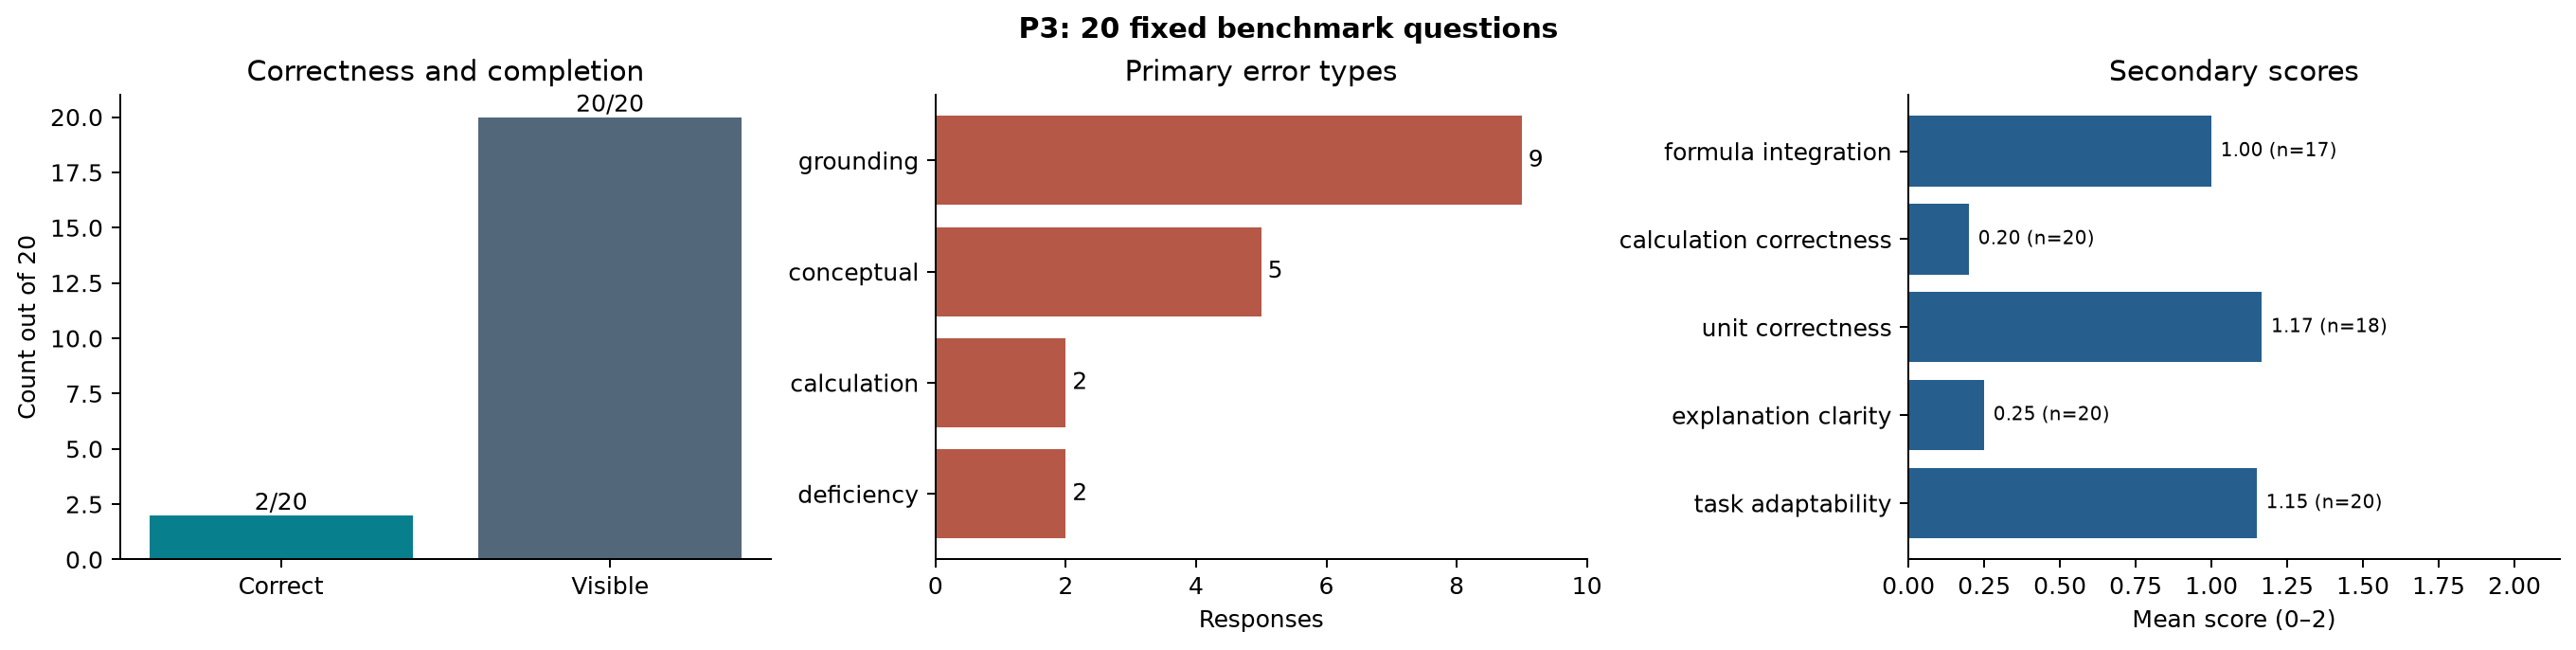

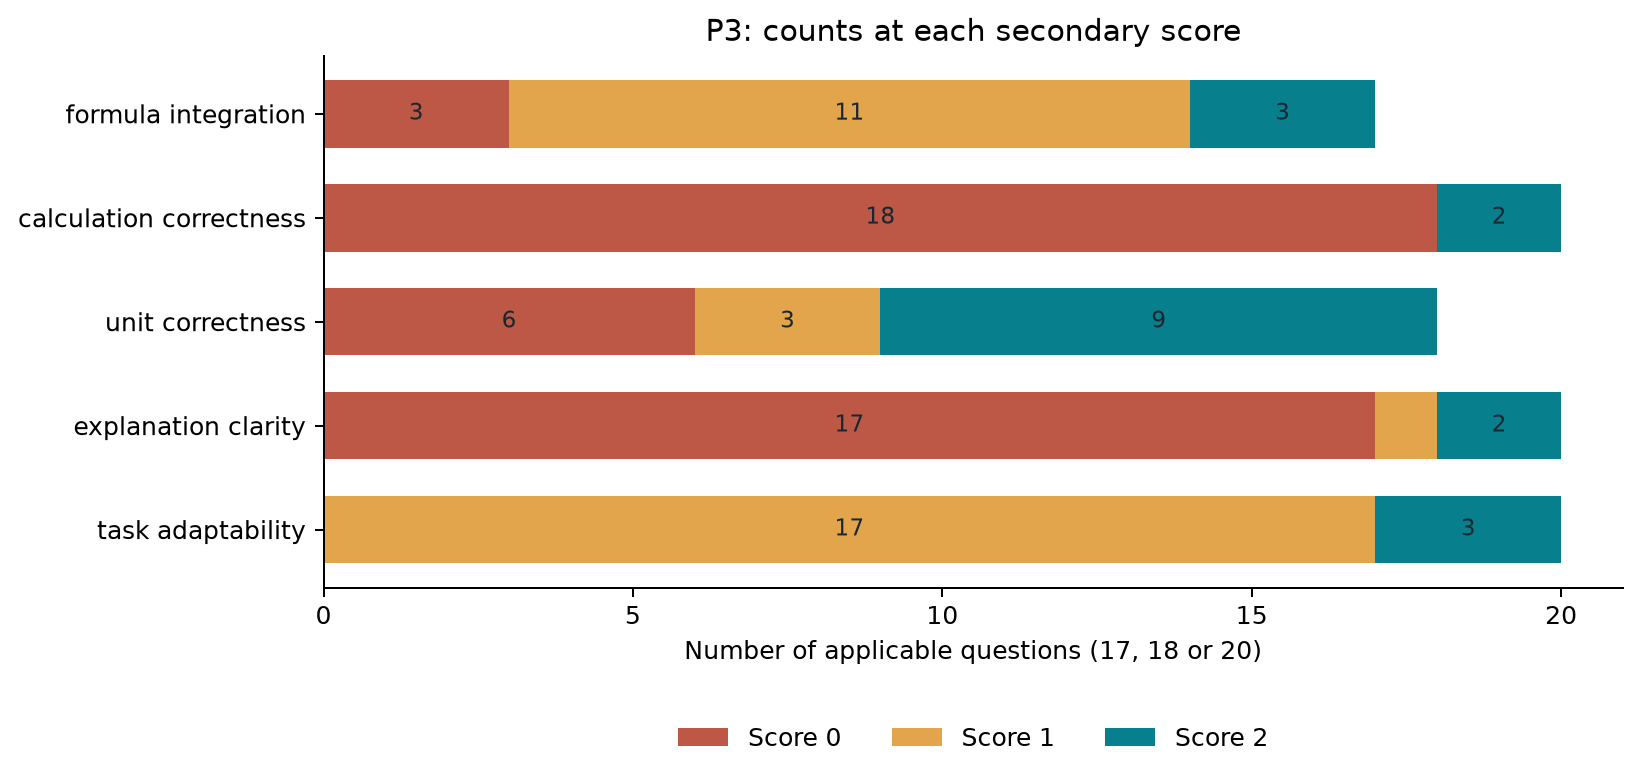

In [10]:
condition_plot("P3")
score_distribution_plot("P3")


### P3: observed findings and interpretation

We observe 2 correct answers out of 20 (10%) and 20 visible responses. Grounding is the largest primary error group (9 of the 18 incorrect answers). Calculation correctness averages 0.20/2 and explanation clarity 0.25/2. We record 18 unsupported-claims flags. Temperature is 1.0 with the same fixed GPT-4 snapshot and retrieval depth as P1/P2. We read the apparent decrease against the paired temperature results and the small question set, not as proof of a general temperature effect.

The problem-type and cognitive-level groups above only describe the data. Ten questions have no recorded label. The other ten cognitive labels are all `Apply`, and the problem types have to be combined because their groups are too small. We cannot draw a conclusion about one named problem type from these grouped numbers.


### P3 findings

- **P3 answered all 20 questions, but only 2 answers were correct.** Its accuracy was 10%, while completion was 100%. The 95% Wilson interval for accuracy is about 3%-30%. With only 20 questions, we should be careful about treating the observed rate as a precise estimate.

- **Grounding was the most common primary error.** Of the 18 incorrect answers, 9 had a grounding error as their primary category. Five had a conceptual error, 2 a calculation error and 2 a deficiency error. Each incorrect answer has one primary category, even if it contains more than one problem.

- **Unsupported-claims flags were frequent.** We recorded this flag for 18 of 20 responses. This is a separate measure from the 9 primary grounding errors, so the counts should not be added together. The aggregate results also do not tell us whether the problem came from retrieval, the selected context or how the model used that context.

- **Calculation correctness was particularly weak.** Eighteen responses scored 0 and only 2 scored 2. The mean was 0.20 out of 2. This matches the low number of fully correct answers, although the calculation score and full-answer correctness measure different things.

- **Formula use did not usually lead to a complete solution.** Formula integration applied to 17 questions: 3 responses scored 2, 11 scored 1 and 3 scored 0. Many answers therefore used formulas at least partly, while only 2 of all 20 answers met the full correctness requirements.

- **Unit scores were mixed, and explanation clarity was low.** For units, 9 of 18 applicable answers scored 2, 3 scored 1 and 6 scored 0. For explanation clarity, 17 of 20 scored 0, one scored 1 and two scored 2. The figure shows that giving units correctly on some questions did not resolve the wider problems with the answers.

- **Most responses addressed the task only partly.** Task adaptability scored 1 on 17 questions and 2 on 3 questions; none scored 0. This means the responses generally attempted the requested task, but only 2 produced a fully correct answer.

- **The descriptive groups show no clear pattern to explain P3’s result.** It answered 1 of 10 `Apply` questions and 1 of 10 questions without a recorded cognitive-level label correctly. It also answered 1 question correctly in each of the two broad problem-type groups. These labels are too incomplete to explain which kinds of questions P3 handled better.

**P3 conclusion.** At temperature 1.0, with the same retrieval setting, P3 produced a visible response for every question but solved only 2 of 20 correctly. Grounding errors, low calculation scores and low explanation clarity describe the main weaknesses in these scores. We will compare P1, P2 and P3 on the same questions later to assess what the temperature results actually support.

## 5. Configuration M1: settings and role

We use the fixed GPT-4.1 snapshot with retrieval k=30, temperature 0.1 and top-p 1.0, allowing a newer non-reasoning configuration comparison with P1.

We retain the same 20 benchmark questions, approved references and expert-scoring rubric as in every other configuration. The settings table below comes directly from the frozen generation configuration; the next tables load this configuration's rows from the published aggregate files. We read the findings descriptively here and reserve significance claims for the matched-question comparisons after all seven sections.


In [11]:
condition_tables("M1")
condition_strata("M1")


Frozen settings


,value
condition,M1
study_role,newer_non_reasoning_model_comparison
requested_model,gpt-4.1-2025-04-14
model_reference_type,fixed_snapshot
retrieval_enabled,True
retrieval_k,30
temperature,0.1
top_p,1.0
reasoning_effort,omitted
endpoint,chat.completions


Outcome: all rates have the same 20-question denominator


,condition,gradable_questions,correct,accuracy,wilson95_lower,wilson95_upper,visible_responses,completion_rate,no_visible_answers,unsupported_claims_count
0,M1,20,10,0.5,0.299298,0.700702,20,1.0,0,5


Secondary criteria: frozen applicable denominators


...

,primary_error_category,count,denominator
0,grounding,3,20
1,conceptual,3,20
2,calculation,3,20
3,deficiency,1,20
4,no_visible_answer,0,20
5,other,0,20


Descriptive cognitive_level strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,M1,6,1.6,10,Apply
1,M1,4,1.6,10,not_recorded_in_reference


Descriptive problem_type strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,M1,4,1.6,10,not_recorded_in_reference
1,M1,6,1.6,10,recorded_not_stratified


### M1: within-configuration view

The three panels separate full correctness, visible-answer completion, the **primary** categories for incorrect answers and the means of the five 0–2 criteria. The category totals plus correct answers must equal 20. Each criterion retains its own applicable question denominator. This view helps identify where a configuration succeeds or fails; a difference between configurations still needs a paired comparison.


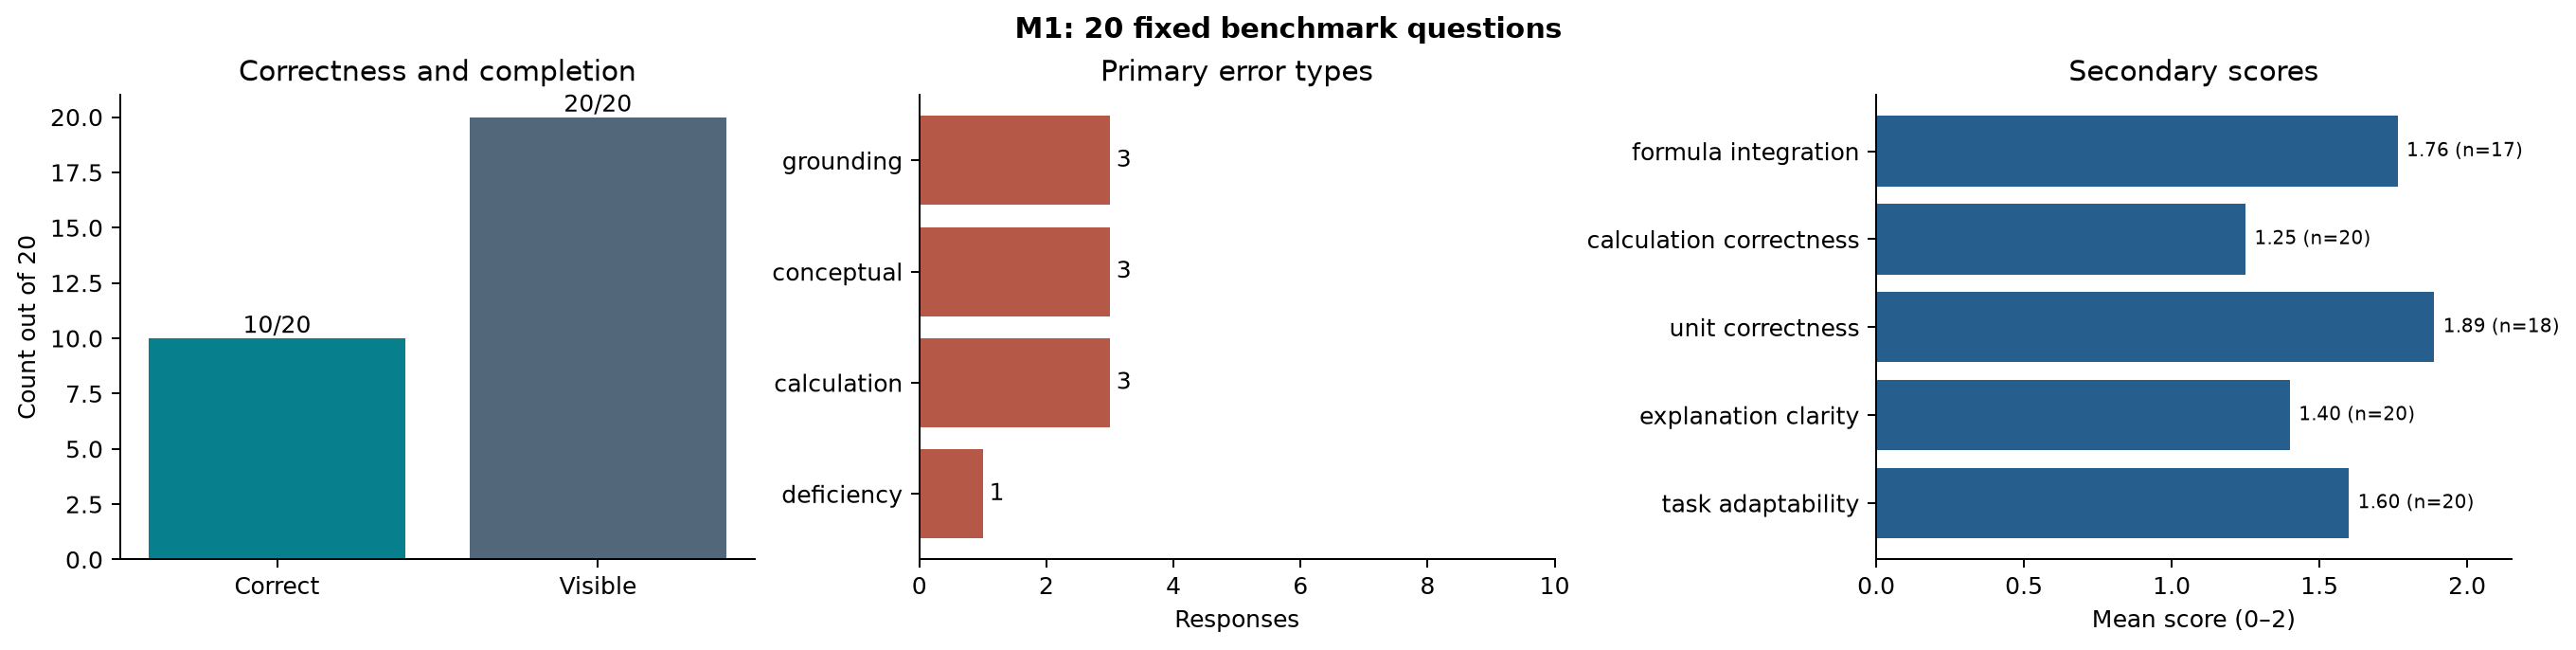

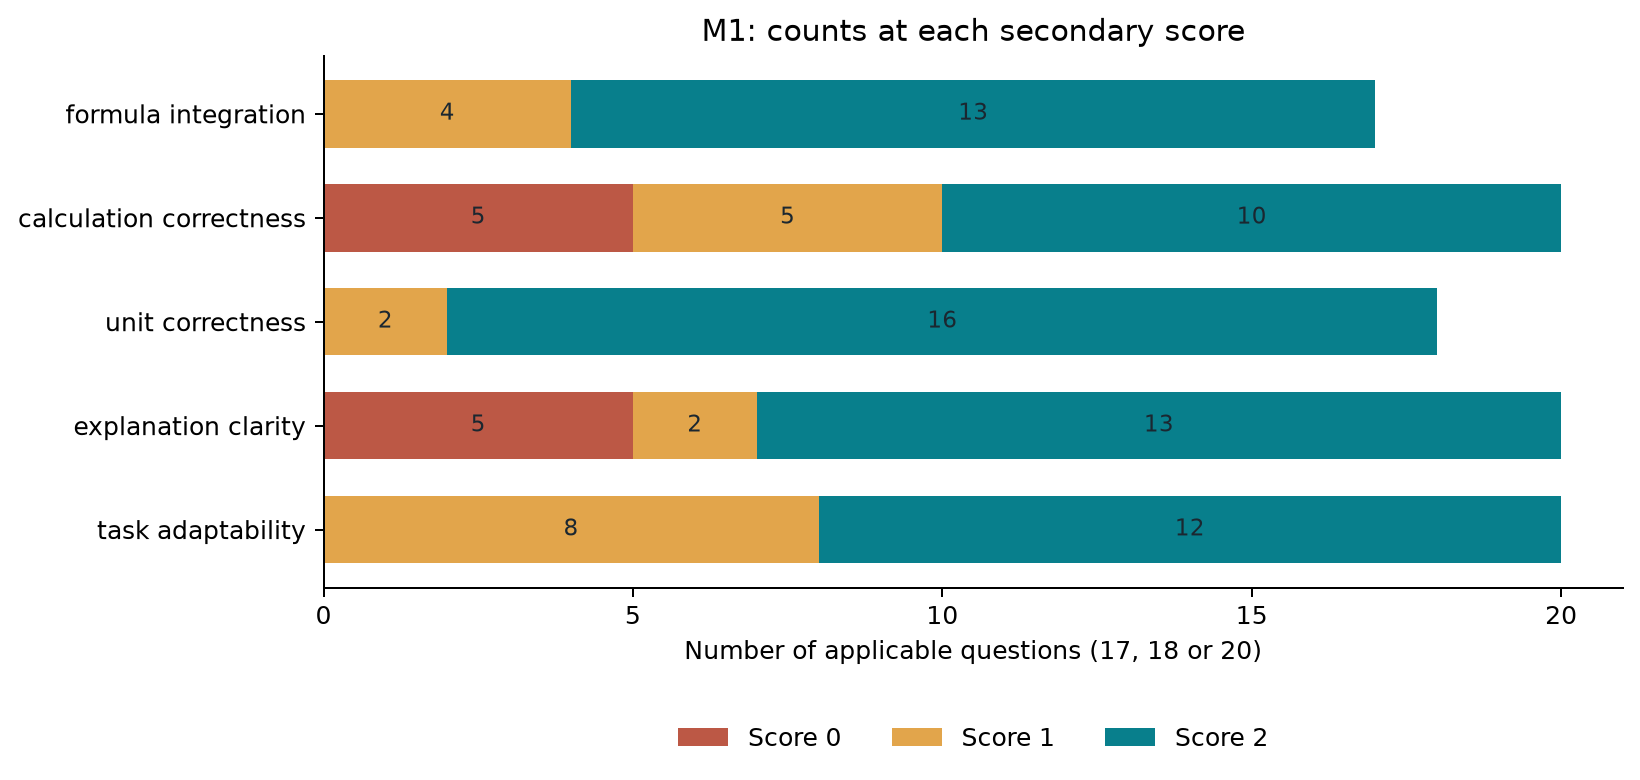

In [12]:
condition_plot("M1")
score_distribution_plot("M1")


### M1: observed findings and interpretation

We observe 10 correct answers out of 20 (50%) and all 20 responses are visible. The 10 incorrect answers include three grounding, three conceptual, three calculation and one deficiency. Formula integration averages 1.76/2, calculation correctness 1.25/2 and clarity 1.40/2; five unsupported-claims flags are recorded. M1 changes the requested model snapshot from P1 while retaining retrieval k=30 and the legacy temperature 0.1. The paired P1–M1 test later addresses whether the difference is present on matched questions; a single output per question does not estimate generation variability.

The problem-type and cognitive-level groups above only describe the data. Ten questions have no recorded label. The other ten cognitive labels are all `Apply`, and the problem types have to be combined because their groups are too small. We cannot draw a conclusion about one named problem type from these grouped numbers.


### M1 findings

- **M1 gave a visible answer to every question and answered 10 of 20 correctly.** Its accuracy was 50% and its completion rate was 100%. The 95% Wilson interval for accuracy is about 30%-70%, so the result still has considerable uncertainty with only 20 questions.

- **No single error type dominated the incorrect answers.** Of the 10 incorrect responses, 3 had a grounding error as their primary category, 3 a conceptual error, 3 a calculation error and 1 a deficiency error. These are the main recorded errors, not a count of every problem in each response.

- **Five responses received an unsupported-claims flag.** This flag is separate from the primary error category. We cannot tell from the aggregate counts alone which flagged answers also had a grounding error.

- **Formula integration was often rated highly.** On the 17 questions where it applied, 13 answers scored 2 and 4 scored 1; none scored 0. However, M1 produced only 10 fully correct answers overall. A strong formula score therefore did not guarantee that the complete solution was correct.

- **Calculation scores were more mixed.** Ten answers scored 2, five scored 1 and five scored 0. This is an important distinction from formula integration: an answer could use a suitable formula but still make a mistake when applying it or completing the solution.

- **Units were usually handled well, while explanation quality varied.** Sixteen of 18 applicable answers received the top unit score and the other 2 received a partial score. Explanation clarity scored 2 on 13 questions, 1 on 2 questions and 0 on 5 questions. Clearer explanations were common, but not present in every answer.

- **Most answers addressed the requested task well.** Task adaptability scored 2 on 12 questions and 1 on 8; none scored 0. This describes how well the responses addressed the task and does not replace the full correctness check.

- **The descriptive groups do not establish which questions M1 finds easier.** M1 answered 6 of 10 questions labelled `Apply` correctly and 4 of 10 without a recorded cognitive-level label. It also answered 6 questions in the broad recorded problem-type group and 4 in the unrecorded group. Because the labels are incomplete or broad, we keep these as descriptive counts.

**M1 conclusion.** Under its frozen settings, M1 produced all 20 responses and solved 10 questions correctly. Formula integration and unit handling received high scores on most applicable questions, while calculation mistakes and other errors still prevented some complete solutions from being correct. We will compare M1 with P1, M2 and M3 on the same questions in the model comparison section.

## 6. Configuration M2: settings and role

We use the fixed GPT-5 snapshot with retrieval k=30 and reasoning effort low. Temperature and top-p are omitted under the frozen API policy; they are not zero.

We retain the same 20 benchmark questions, approved references and expert-scoring rubric as in every other configuration. The settings table below comes directly from the frozen generation configuration; the next tables load this configuration's rows from the published aggregate files. We read the findings descriptively here and reserve significance claims for the matched-question comparisons after all seven sections.


In [13]:
condition_tables("M2")
condition_strata("M2")


Frozen settings


,value
condition,M2
study_role,fixed_reasoning_model_comparison
requested_model,gpt-5-2025-08-07
model_reference_type,fixed_snapshot
retrieval_enabled,True
retrieval_k,30
temperature,omitted
top_p,omitted
reasoning_effort,low
endpoint,chat.completions


Outcome: all rates have the same 20-question denominator


,condition,gradable_questions,correct,accuracy,wilson95_lower,wilson95_upper,visible_responses,completion_rate,no_visible_answers,unsupported_claims_count
0,M2,20,11,0.55,0.342085,0.741802,11,0.55,9,0


Secondary criteria: frozen applicable denominators


...

,primary_error_category,count,denominator
0,grounding,0,20
1,conceptual,0,20
2,calculation,0,20
3,deficiency,0,20
4,no_visible_answer,9,20
5,other,0,20


Descriptive cognitive_level strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,M2,5,1.0,10,Apply
1,M2,6,1.2,10,not_recorded_in_reference


Descriptive problem_type strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,M2,6,1.2,10,not_recorded_in_reference
1,M2,5,1.0,10,recorded_not_stratified


### M2: within-configuration view

The three panels separate full correctness, visible-answer completion, the **primary** categories for incorrect answers and the means of the five 0–2 criteria. The category totals plus correct answers must equal 20. Each criterion retains its own applicable question denominator. This view helps identify where a configuration succeeds or fails; a difference between configurations still needs a paired comparison.


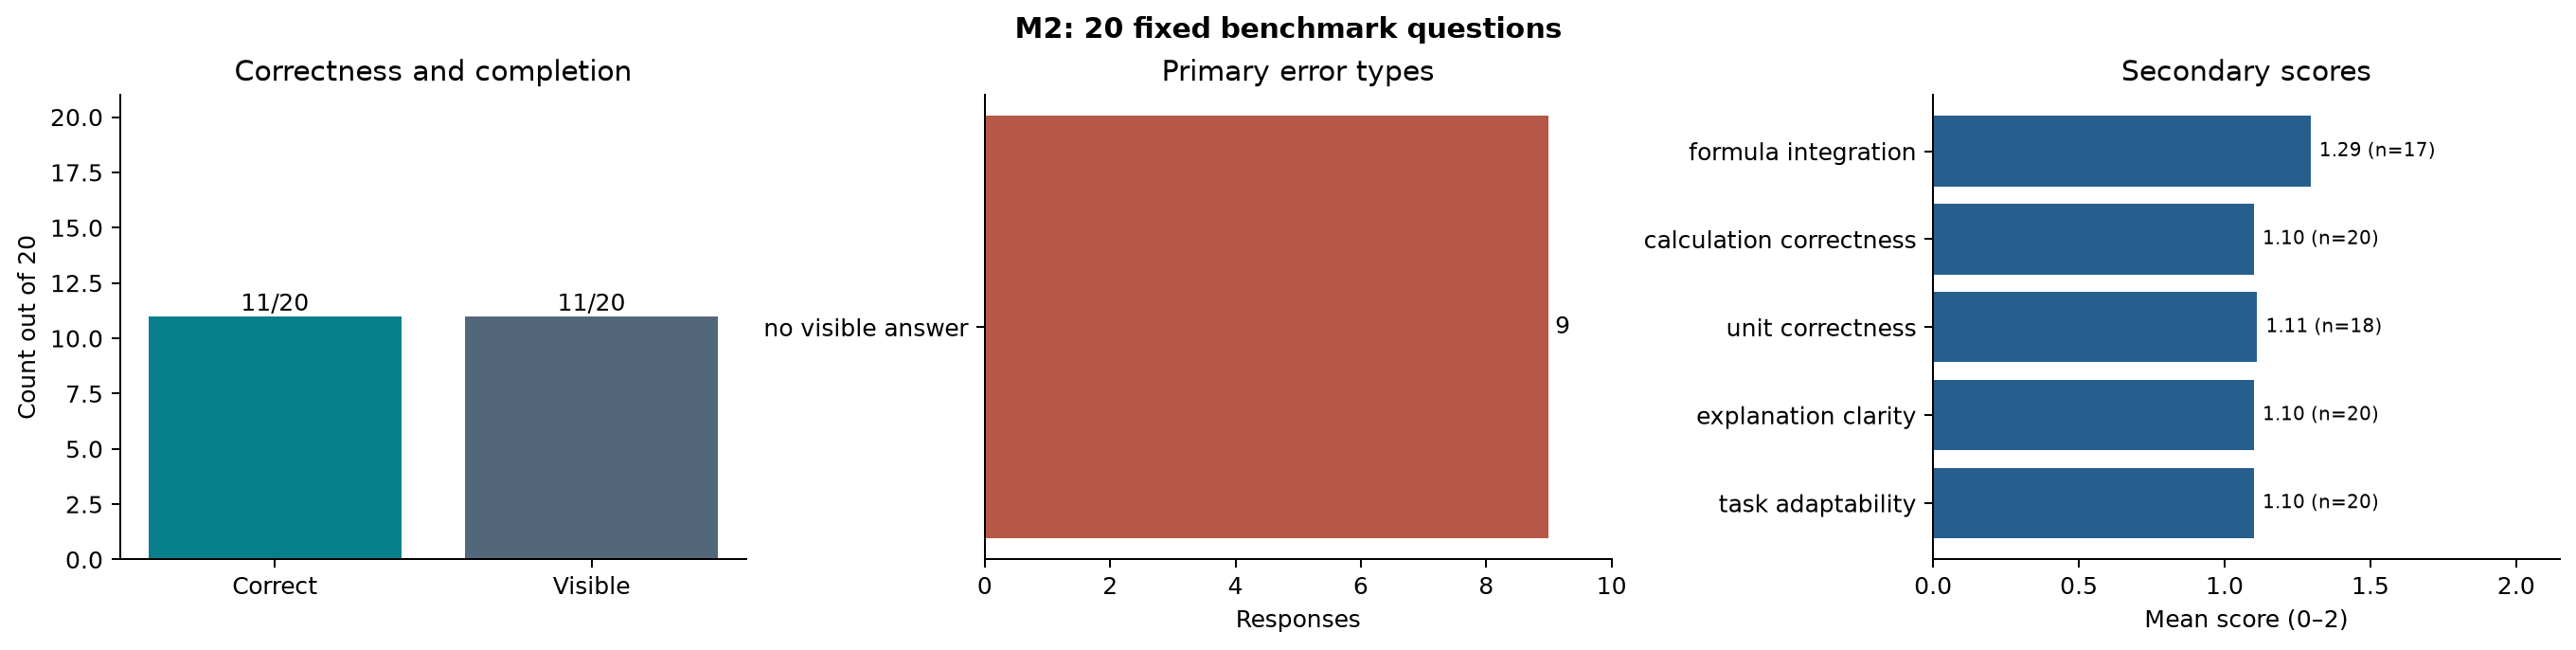

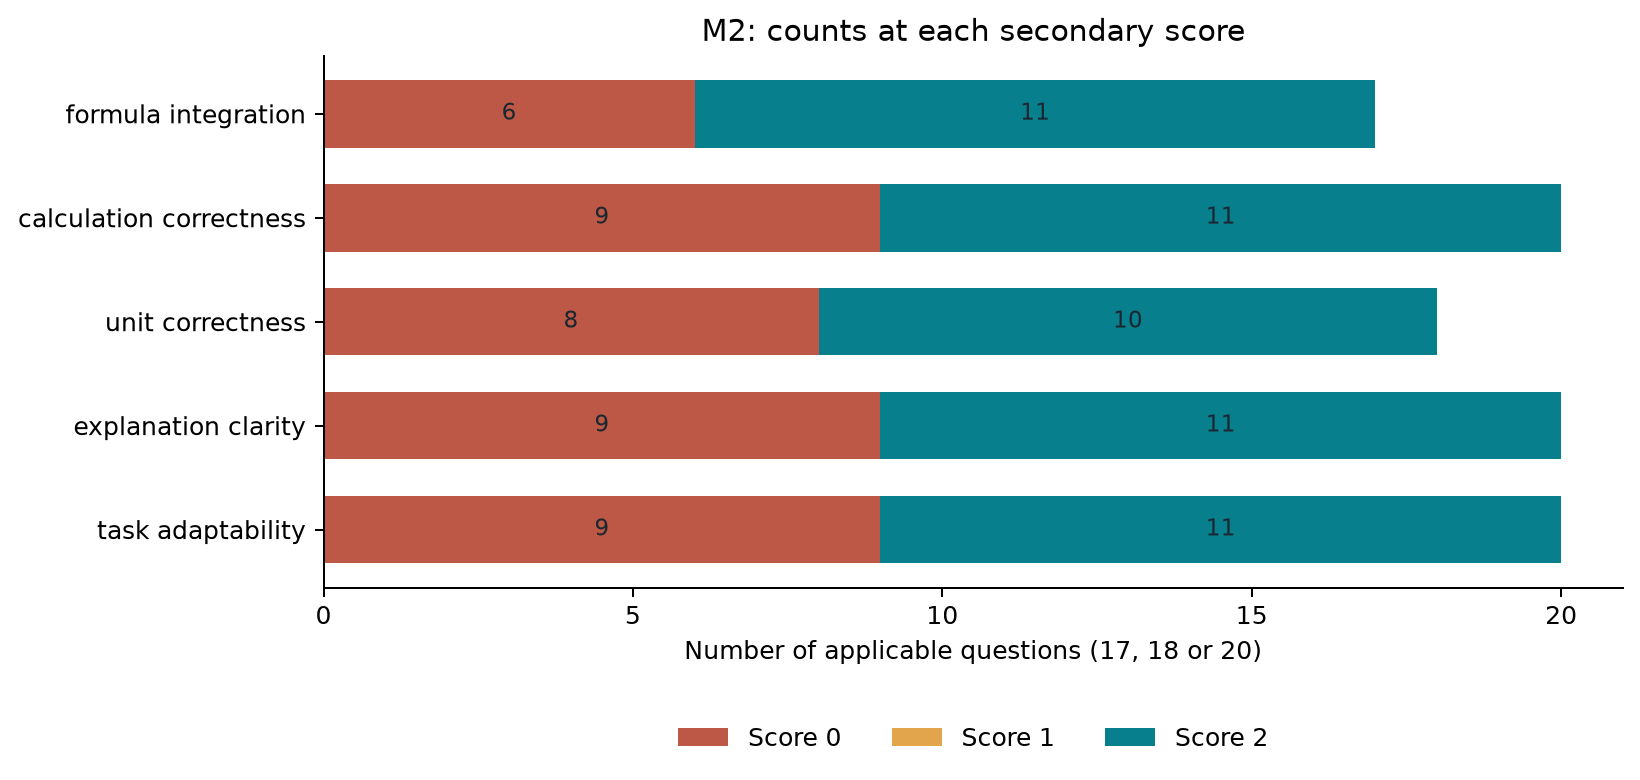

In [14]:
condition_plot("M2")
score_distribution_plot("M2")


### M2: observed findings and interpretation

We observe 11 correct answers out of the full 20 (55%) but only 11 visible responses (55% completion). All nine incorrect cases have the frozen `no_visible_answer` category. The 11 visible responses were scored correct, but 11/11 is a conditional description, **not** the benchmark accuracy or a reason to drop nine questions. Calculation correctness and clarity each average 1.10/2 across all 20, with applicable empty answers scored zero. No unsupported claim was flagged; the nine missing answers still represent a large reliability limitation. M2 uses reasoning effort `low`, with temperature and `top_p` omitted. Its comparison with P1 or M1 reflects the whole configuration rather than the model name in isolation.

The problem-type and cognitive-level groups above only describe the data. Ten questions have no recorded label. The other ten cognitive labels are all `Apply`, and the problem types have to be combined because their groups are too small. We cannot draw a conclusion about one named problem type from these grouped numbers.


### M2 findings

- **M2 produced a visible answer for only 11 of 20 questions.** All 11 visible answers were judged correct. The other 9 questions had no visible answer and remain incorrect under our frozen scoring rule. This gives M2 55% accuracy and 55% completion across the full set of 20 questions. We keep the full 20-question denominator for the main result.

- **The 9 incorrect records all have the same primary category: `no_visible_answer`.** We cannot examine those records for conceptual, calculation or grounding mistakes because there is no answer text to assess. The aggregate results also do not tell us why no answer was visible, so we should not assign a cause to the missing responses.

- **The secondary-score figure reflects the missing answers.** Calculation correctness, explanation clarity and task adaptability each have 11 scores of 2 and 9 scores of 0, with no partial scores. These low scores include the 9 questions without a visible answer; they should not be read as 9 demonstrated calculation or explanation mistakes in written answers.

- **Formula and unit scores use smaller applicable groups.** Formula integration applied to 17 questions: 11 scored 2 and 6 scored 0. Unit correctness applied to 18 questions: 10 scored 2 and 8 scored 0. There were no partial scores for either criterion. The different counts reflect which questions required formulas or units.

- **No response received an unsupported-claims flag.** This describes the recorded scores for this run. Since M2 produced text for only 11 questions, we should report the flag count alongside its completion rate.

- **The descriptive groups do not explain the missing answers.** M2 answered 5 of 10 `Apply` questions correctly and 6 of 10 questions without a recorded cognitive-level label. The broad problem-type groups show 5 and 6 correct answers. These totals do not show which individual questions had no visible answer, and the labels are too limited to support a claim about question difficulty.

**M2 conclusion.** When M2 produced a visible answer, that answer was correct in all 11 cases. Its main limitation in this evaluation was that 9 of the 20 questions had no visible answer. We therefore report both accuracy and completion as 55%, and retain the missing answers in every comparison. Later, we will compare M2 with the other conditions on the same 20 questions while keeping this difference between answer quality and answer availability clear.

## 7. Configuration M3: settings and role

We use the GPT-6 Astra mutable alias with retrieval k=30 and reasoning effort low. Temperature and top-p are omitted; the response-file fingerprint identifies this recorded run.

We retain the same 20 benchmark questions, approved references and expert-scoring rubric as in every other configuration. The settings table below comes directly from the frozen generation configuration; the next tables load this configuration's rows from the published aggregate files. We read the findings descriptively here and reserve significance claims for the matched-question comparisons after all seven sections.


In [15]:
condition_tables("M3")
condition_strata("M3")


Frozen settings


,value
condition,M3
study_role,latest_model_exploratory_comparison
requested_model,gpt-6-astra
model_reference_type,mutable_alias
retrieval_enabled,True
retrieval_k,30
temperature,omitted
top_p,omitted
reasoning_effort,low
endpoint,chat.completions


Outcome: all rates have the same 20-question denominator


,condition,gradable_questions,correct,accuracy,wilson95_lower,wilson95_upper,visible_responses,completion_rate,no_visible_answers,unsupported_claims_count
0,M3,20,20,1.0,0.838875,1.0,20,1.0,0,0


Secondary criteria: frozen applicable denominators


...

,primary_error_category,count,denominator
0,grounding,0,20
1,conceptual,0,20
2,calculation,0,20
3,deficiency,0,20
4,no_visible_answer,0,20
5,other,0,20


Descriptive cognitive_level strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,M3,10,2,10,Apply
1,M3,10,2,10,not_recorded_in_reference


Descriptive problem_type strata (approved, pooled labels only)


,condition,correct,mean_adaptability,question_count,stratum
0,M3,10,2,10,not_recorded_in_reference
1,M3,10,2,10,recorded_not_stratified


### M3: within-configuration view

The three panels separate full correctness, visible-answer completion, the **primary** categories for incorrect answers and the means of the five 0–2 criteria. The category totals plus correct answers must equal 20. Each criterion retains its own applicable question denominator. This view helps identify where a configuration succeeds or fails; a difference between configurations still needs a paired comparison.


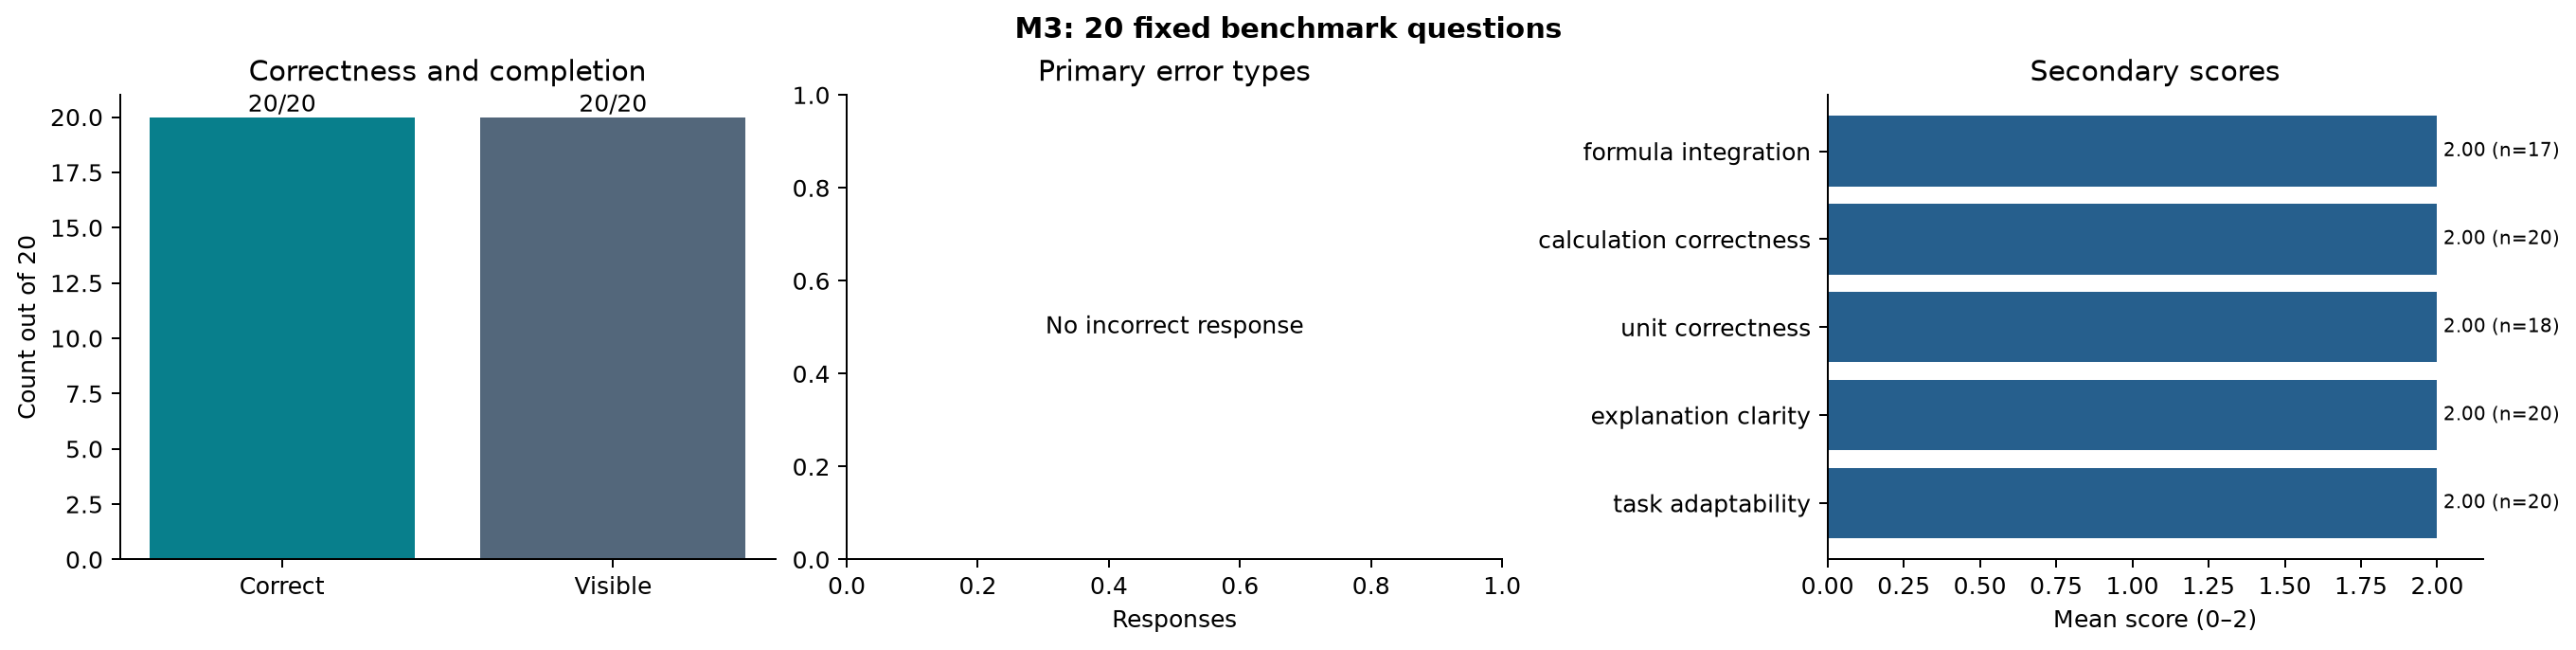

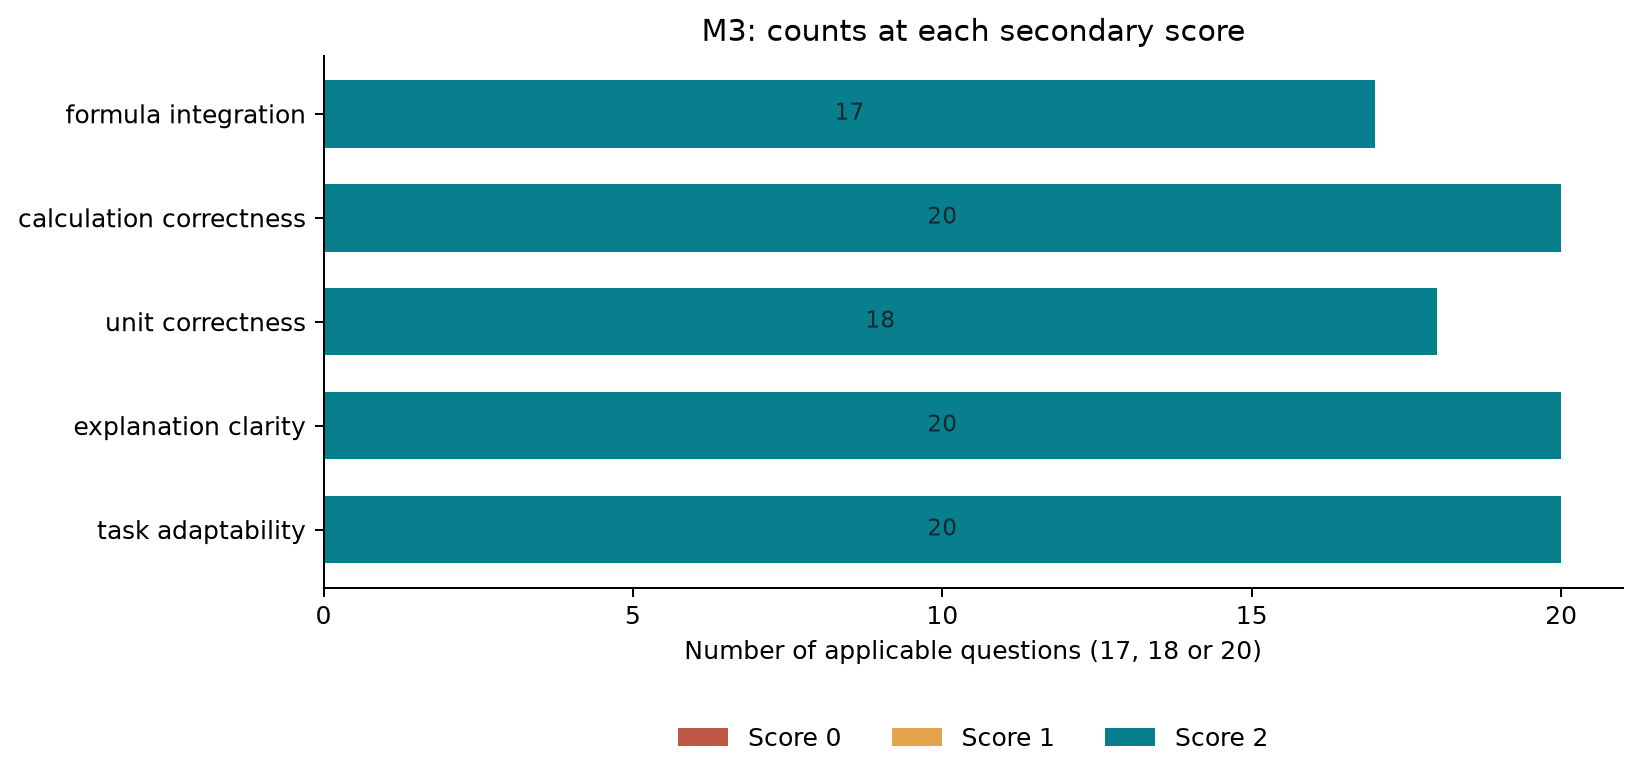

In [16]:
condition_plot("M3")
score_distribution_plot("M3")


### M3: observed findings and interpretation

We observe 20 correct answers out of 20 (100%) and all 20 responses are visible. All five secondary criterion means are 2.00/2 on their applicable questions and no primary errors or unsupported-claims flags are recorded. This describes one frozen run on the selected 20 questions; the Wilson lower limit is about 83.9% under its sampling model, and we do not claim perfect general performance. `gpt-6-astra` was a mutable model alias, so a future run with the same requested name need not use the same underlying version. P1/M1/M2/M3 comparisons assess these recorded configurations under their documented controls.

The problem-type and cognitive-level groups above only describe the data. Ten questions have no recorded label. The other ten cognitive labels are all `Apply`, and the problem types have to be combined because their groups are too small. We cannot draw a conclusion about one named problem type from these grouped numbers.


### M3 findings

- **M3 produced a visible and correct answer for all 20 questions.** Both accuracy and completion were 100% on this fixed benchmark. This is the best result observed in this evaluation, but it describes these 20 questions; it does not mean M3 will answer every other geotechnical question correctly.

- **Every applicable secondary score was 2.** Formula integration scored 2 on all 17 applicable questions and unit correctness scored 2 on all 18 applicable questions. Calculation correctness, explanation clarity and task adaptability each scored 2 on all 20 questions. There were no partial or zero scores.

- **There are no primary error categories to count.** Primary errors are assigned to incorrect responses, and none of M3’s 20 responses was judged incorrect. No response received an unsupported-claims flag either.

- **The result holds across the recorded descriptive groups.** M3 answered all 10 questions labelled `Apply` and all 10 without a recorded cognitive-level label correctly. It also answered all 10 questions in each broad problem-type group correctly. These groups do not give us a detailed breakdown of performance by problem type, because some labels are missing or broad.

- **We should keep the scope of the result clear.** The reported 95% Wilson interval is about 84%–100%, but the questions form a fixed benchmark rather than a random sample of every question a tutor could receive. The answers were also assessed by one expert. We can state exactly what happened here without claiming that future answers will always be correct.

- **The model name is a mutable alias.** The frozen responses and scores preserve what happened in this run. A later call to `gpt-6-astra` might use a different model version, so repeating the request later may not reproduce these exact answers.

**M3 conclusion.** Under the recorded settings, M3 completed and correctly answered all 20 benchmark questions and received the top score on every applicable secondary criterion. This is a strong result for this run. In the comparison section, we will test the differences on the same questions and discuss M3 as an exploratory condition with a mutable model name.


## 8. Comparing the configurations on matched questions

The seven conditions are **paired**: they all answer the same 20 questions. We analyse the three groups planned before scoring: retrieval (P0/P1), temperature (P1/P2/P3), and model/generation configuration (P1/M1/M2/M3). The latter label reflects differences in model, supported sampling controls and reasoning settings. We do not call it a clean causal test of model identity alone. We keep accuracy on the fixed 20-question denominator and show completion separately, especially for M2.

For primary correctness we use the tests computed from the private matched judgments in notebook 08. This notebook reads their public, text-free results; an aggregate count alone cannot reconstruct the question-by-question pairing. We do not calculate an unpaired chi-square test for the original paper's GPT-4 versus Llama-3 comparison because our frozen conditions do not contain that pair.

### What the statistical quantities tell us

- **Wilson interval:** gives a range around one correct/20 percentage. It does not compare two configurations and does not make our selected questions a random sample.
- **Exact McNemar test:** compares **two** configurations on the same questions. It uses only questions where exactly one configuration was correct. If there is no real difference, we would expect those cases to favour each side equally often. The table shows which side won each such case. A large *p* value does not show that the configurations are equal.
- **Cochran's Q:** checks whether **three or four** configurations differ somewhere in correctness on the same questions. It uses an approximate *p* value, so we read close results carefully with just 20 questions. It does not say which pair differs; the McNemar table helps with that.
- **Holm adjustment:** makes it harder to call a pair different just because we tested several pairs in one planned group. For each pair we read the adjusted *p* value and compare it with 0.05. A small *p* value is evidence about these answers, not proof of teaching quality or general performance.


In [17]:

FAMILIES = {
    "retrieval": ("P0", "P1"),
    "temperature": ("P1", "P2", "P3"),
    "model_generation": ("P1", "M1", "M2", "M3"),
}
assert evaluation["study_design"]["comparison_groups"] == {
    "retrieval_effect": list(FAMILIES["retrieval"]),
    "temperature_effect": list(FAMILIES["temperature"]),
    "model_generation_effect": list(FAMILIES["model_generation"]),
}

def family_results(family):
    selected = list(FAMILIES[family])
    print("Correctness and completion on the same 20 questions")
    display(summary.loc[summary["condition"].isin(selected)].reset_index(drop=True))
    print("Primary paired correctness results")
    if family in metrics["binary_omnibus"]:
        print("Omnibus Cochran Q:")
        display(pd.DataFrame([metrics["binary_omnibus"][family]]))
    display(pairwise.loc[pairwise["family"].eq(family)].reset_index(drop=True))

    profile = summary.set_index("condition").loc[selected]
    xs = np.arange(len(selected))
    fig, ax = plt.subplots(figsize=(max(6, 1.9 * len(selected)), 4.1), layout="constrained")
    lower = profile["accuracy"] - profile["wilson95_lower"]
    upper = profile["wilson95_upper"] - profile["accuracy"]
    ax.bar(xs - .18, profile["accuracy"] * 100, width=.36, color="#087f8c", label="Fully correct / 20")
    ax.errorbar(xs - .18, profile["accuracy"] * 100,
                yerr=np.vstack([lower, upper]) * 100, fmt="none", capsize=3, color="#27313c")
    ax.bar(xs + .18, profile["completion_rate"] * 100, width=.36, color="#53677b", label="Visible / 20")
    ax.set_xticks(xs, selected)
    ax.set_ylim(0, 112)
    ax.set_ylabel("Share of the same 20 questions (%)")
    ax.set_title(f"{family.replace('_', ' ').title()}: correctness and completion")
    ax.legend(loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    show_plot(fig)

    print("Criterion means (0–2; applicable denominators shown in table below)")
    criteria = secondary.loc[secondary["condition"].isin(selected)]
    display(criteria.reset_index(drop=True))
    means = criteria.pivot(index="field", columns="condition", values="mean_score")
    means = means.loc[list(FIELDS), selected]
    fig, ax = plt.subplots(figsize=(max(6, 1.9 * len(selected)), 4), layout="constrained")
    image = ax.imshow(means.to_numpy(), cmap="YlGnBu", vmin=0, vmax=2, aspect="auto")
    ax.set_xticks(range(len(selected)), selected)
    ax.set_yticks(range(len(FIELDS)), [field.replace("_", " ") for field in FIELDS])
    for i in range(len(FIELDS)):
        for j in range(len(selected)):
            value = float(means.iloc[i, j])
            ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                    color="white" if value >= 1.25 else "#17283c")
    fig.colorbar(image, ax=ax, label="Mean expert score (0–2)")
    ax.set_title("Secondary criteria by condition")
    show_plot(fig)



### Secondary paired tests: what we can infer

The five secondary scales use scores 0, 1 and 2. Formula integration is applicable to 17 prevalidated questions, unit correctness to 18, and calculation, clarity and adaptability to 20. For each family and criterion we restrict the paired test to the **same applicable question set** in every condition.

With two conditions, the paired Wilcoxon test looks at differences in the 0–2 scores for the **same question**. It ignores pairs with equal scores and tells us how many pairs were different. With three or four conditions, the Friedman test first asks whether their scores differ somewhere. The paired Wilcoxon tests then show which pairs may differ. Many scores are tied at 0, 1 or 2, so we read these tests carefully. We compare the Holm-adjusted values for the pairs. We did not make one adjustment across all five scoring measures, so these results support the main correctness result but do not count as five independent proofs.

The tables below are saved aggregate test outputs from notebook 08. Individual question scores are not reconstructed from means.


In [18]:

def ordinal_results(family):
    groups = metrics["ordinal_comparisons"][family]
    overview = []
    for field in FIELDS:
        result = groups[field]
        omnibus = result["friedman"]
        overview.append({"criterion": field, "common_applicable_questions": result["common_applicable_questions"],
                         "friedman_statistic": None if omnibus is None else omnibus["statistic"],
                         "friedman_df": None if omnibus is None else omnibus["df"],
                         "friedman_p_value": None if omnibus is None else omnibus["p_value"],
                         "number_of_pairs": len(result["paired_wilcoxon"])})
    display(pd.DataFrame(overview))
    for field in FIELDS:
        print("Paired Wilcoxon comparisons:", field)
        display(pd.DataFrame(groups[field]["paired_wilcoxon"]))


### 8.1 Retrieval: P0 compared with P1

We isolate the change from no retrieved context to k=30 while keeping the GPT-4 snapshot, temperature 0.1 and the 20 questions fixed. Exact McNemar is the primary paired test because correctness is binary. We inspect secondary means and their paired Wilcoxon results separately.


Correctness and completion on the same 20 questions


,condition,gradable_questions,correct,accuracy,wilson95_lower,wilson95_upper,visible_responses,completion_rate,no_visible_answers,unsupported_claims_count
0,P0,20,2,0.10,0.027866,0.301034,20,1.0,0,15
1,P1,20,3,0.15,0.052369,0.360419,20,1.0,0,14


Primary paired correctness results


,family,left_condition,right_condition,left_only_correct,right_only_correct,discordant,p_value,holm_adjusted_p_value
0,retrieval,P0,P1,0,1,1,1.0,1.0


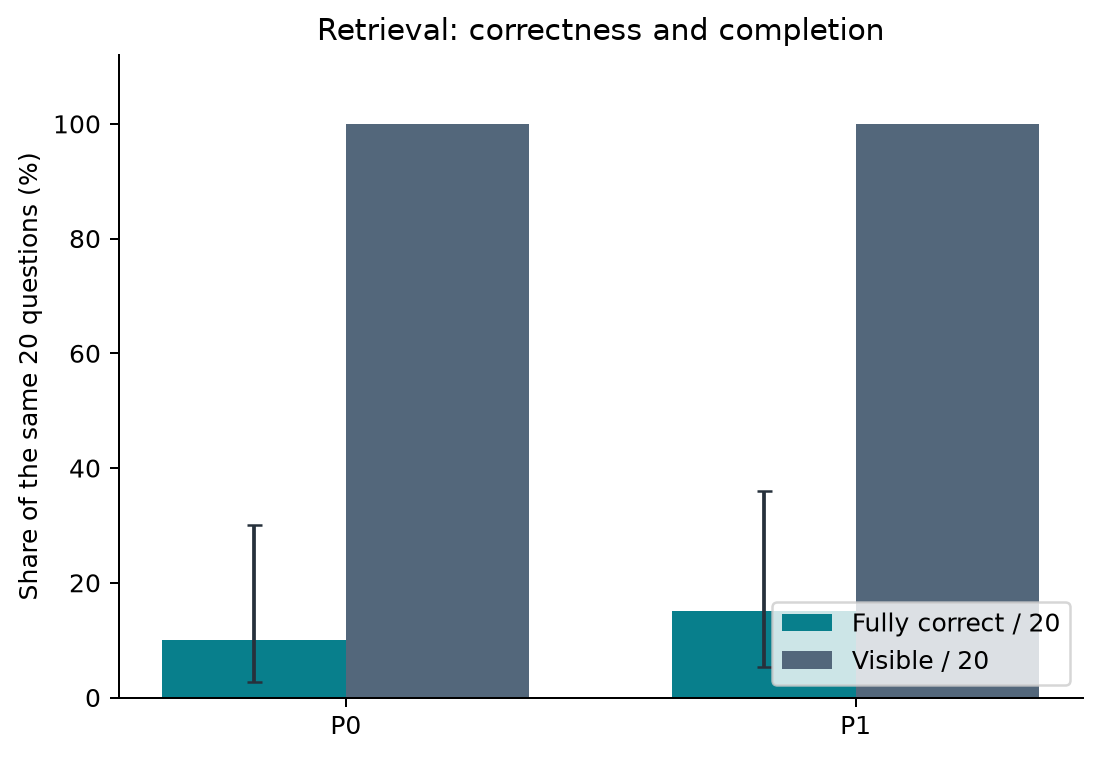

Criterion means (0–2; applicable denominators shown in table below)


,condition,field,applicable_questions,mean_score,median_score,score_0_count,score_1_count,score_2_count
0,P0,formula_integration,17,1.000000,1.0,3,11,3
1,P1,formula_integration,17,1.235294,1.0,1,11,5
2,P0,calculation_correctness,20,0.200000,0.0,18,0,2
3,P1,calculation_correctness,20,0.400000,0.0,15,2,3
4,P0,unit_correctness,18,1.333333,2.0,5,2,11
5,P1,unit_correctness,18,1.388889,2.0,4,3,11
6,P0,explanation_clarity,20,0.400000,0.0,15,2,3
7,P1,explanation_clarity,20,0.600000,0.0,13,2,5
8,P0,task_adaptability,20,1.150000,1.0,0,17,3
9,P1,task_adaptability,20,1.250000,1.0,0,15,5


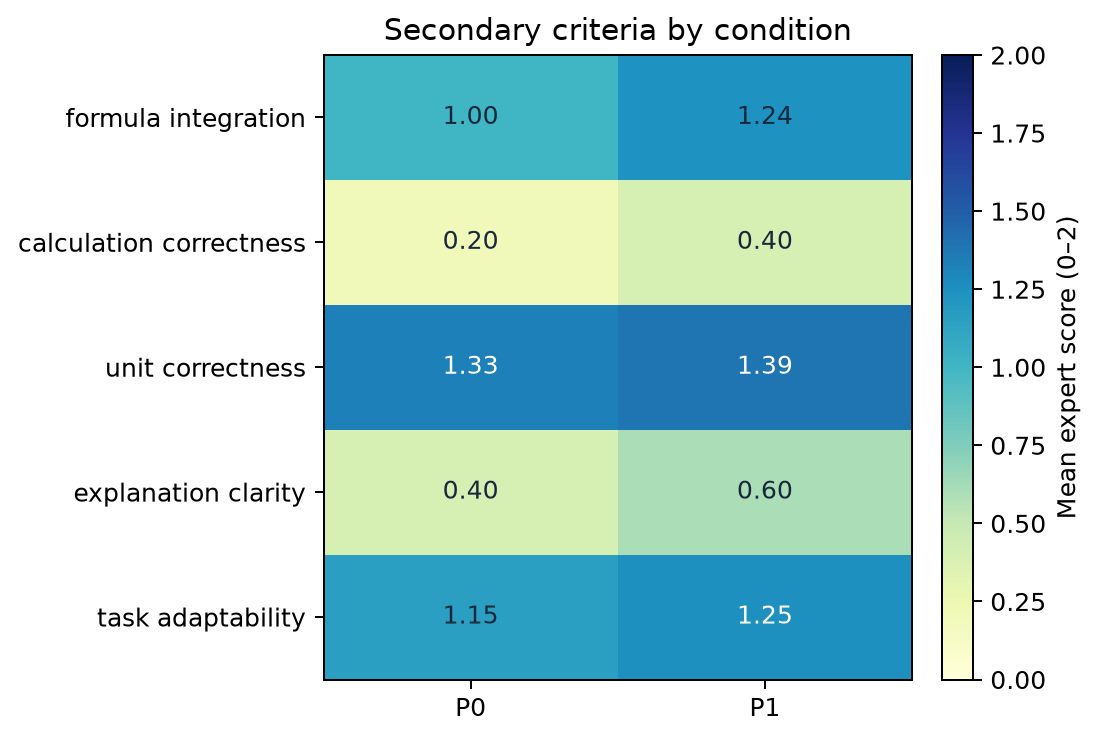

,criterion,common_applicable_questions,friedman_statistic,friedman_df,friedman_p_value,number_of_pairs
0,formula_integration,17,None,None,None,1
1,calculation_correctness,20,None,None,None,1
2,unit_correctness,18,None,None,None,1
3,explanation_clarity,20,None,None,None,1
4,task_adaptability,20,None,None,None,1


Paired Wilcoxon comparisons: formula_integration


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,0.3125,P0,5,0.3125,P1,2.5


Paired Wilcoxon comparisons: calculation_correctness


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,0.25,P0,3,0.25,P1,0.0


...

,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,0.75,P0,9,0.75,P1,19.5


Paired Wilcoxon comparisons: explanation_clarity


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,0.625,P0,4,0.625,P1,2.5


Paired Wilcoxon comparisons: task_adaptability


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,0.625,P0,4,0.625,P1,2.5


In [19]:
family_results("retrieval")
ordinal_results("retrieval")


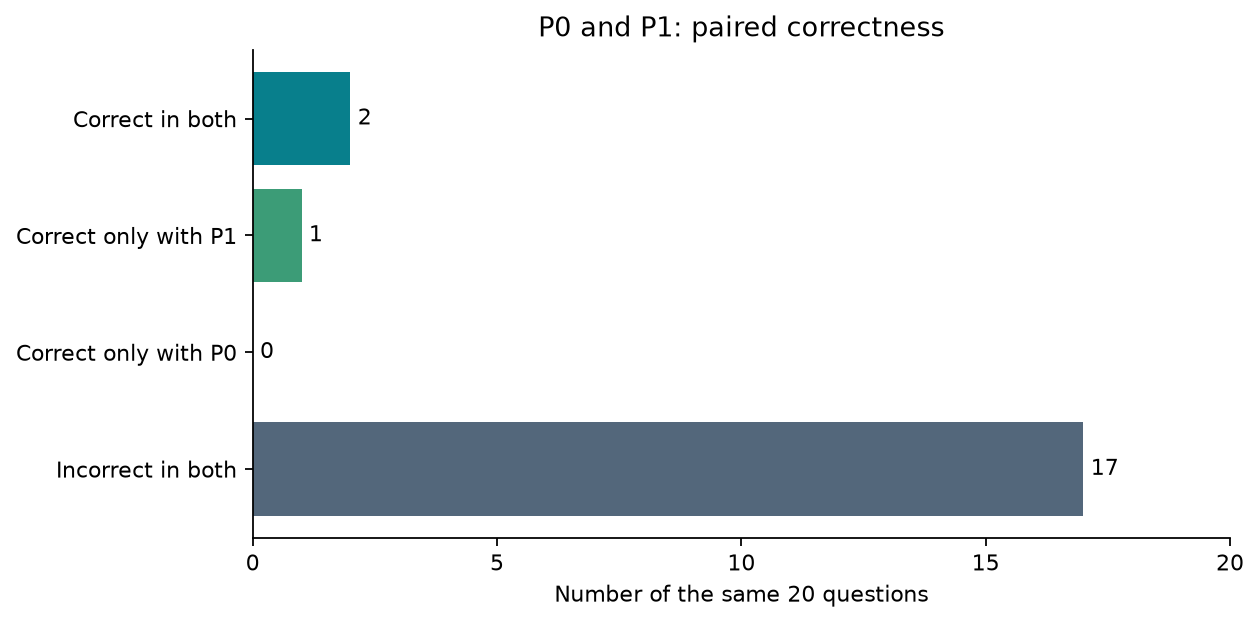

In [20]:
from io import BytesIO
from IPython.display import Image, display

retrieval_pair = pairwise.loc[
    pairwise["family"].eq("retrieval")
    & pairwise["left_condition"].eq("P0")
    & pairwise["right_condition"].eq("P1")
].iloc[0]

p0_correct = int(summary.set_index("condition").loc["P0", "correct"])
p1_correct = int(summary.set_index("condition").loc["P1", "correct"])
p0_only = int(retrieval_pair["left_only_correct"])
p1_only = int(retrieval_pair["right_only_correct"])

both_correct = p0_correct - p0_only
both_incorrect = 20 - both_correct - p0_only - p1_only

assert (p0_correct, p1_correct) == (2, 3)
assert (both_correct, p1_only, p0_only, both_incorrect) == (2, 1, 0, 17)

labels = [
    "Correct in both",
    "Correct only with P1",
    "Correct only with P0",
    "Incorrect in both",
]
counts = [both_correct, p1_only, p0_only, both_incorrect]
colors = ["#087f8c", "#3c9c77", "#b65848", "#53677b"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, counts, color=colors)
ax.invert_yaxis()
ax.set_xlim(0, 20)
ax.set_xticks([0, 5, 10, 15, 20])
ax.set_xlabel("Number of the same 20 questions")
ax.set_title("P0 and P1: paired correctness")
ax.spines[["top", "right"]].set_visible(False)

for bar, count in zip(bars, counts):
    ax.text(max(count, 0) + 0.15, bar.get_y() + bar.get_height() / 2,
            str(count), va="center")

fig.tight_layout()
buffer = BytesIO()
fig.savefig(buffer, format="png", dpi=160, bbox_inches="tight")
display(Image(data=buffer.getvalue()))
plt.close(fig)


**Finding.** Correctness changes from 2/20 to 3/20: zero questions favour P0 alone and one favours P1 alone. Exact two-sided McNemar gives *p* = 1.000. This does not provide evidence of improved binary correctness from retrieval in this set. The five secondary Wilcoxon comparisons also do not cross 0.05. We cannot infer that retrieval was technically absent or useless: this test addresses **correct answers**, not retrieval relevance on its own; the retrieval evaluation notebooks contain separate evidence about chunk quality. One discordant question offers little power, so failure to detect a difference is not evidence of equivalence.


### 8.1 Retrieval comparison: P0 and P1 findings

We compare the same 20 questions using the same GPT-4 snapshot, temperature 0.1 and prompt. P0 has no retrieved context, while P1 uses retrieval with \(k=30\). Both produced a visible answer for every question.

- **Correctness increased by one answer.** P0 answered 2/20 questions correctly and P1 answered 3/20. The paired chart shows what happened on the same questions: both were correct on 2, P1 alone was correct on 1, P0 alone was correct on 0, and both were incorrect on 17. The change in accuracy is 5 percentage points on this benchmark.

- **We use the exact McNemar test because correctness is paired and binary.** It looks only at questions where one condition was correct and the other was incorrect. Here there is just one such question, in favour of P1. The two-sided result is \(p=1.000\). This gives us no clear statistical evidence of a difference in correctness. It also does not show that retrieval has no effect: one changed question gives the test very little information.

- **Completion did not change.** Both conditions gave visible answers on all 20 questions. The correctness result is therefore not affected by missing answers in this comparison.

- **The average secondary scores are slightly higher for P1.** Formula integration increased from 1.00 to 1.24 out of 2, calculation correctness from 0.20 to 0.40, unit correctness from 1.33 to 1.39, explanation clarity from 0.40 to 0.60, and task adaptability from 1.15 to 1.25. Formula integration applies to 17 questions, units to 18, and the other criteria to 20.

- **We check secondary scores as matched scores too.** The paired Wilcoxon test compares each question's 0–2 score under P0 and P1. Its \(p\) values are 0.3125 for formula integration, 0.25 for calculation correctness, 0.75 for unit correctness, and 0.625 for both explanation clarity and task adaptability. None is below 0.05. These results do not establish a clear difference in the secondary criteria, despite the higher observed means for P1.

- **The error counts remain descriptive.** Grounding was the primary error for 7 P0 answers and 5 P1 answers; unsupported-claims flags were recorded for 15 and 14 answers respectively. These totals do not tell us which individual questions changed category. We do not use them as a separate test of retrieval quality.

**Retrieval conclusion.** Adding retrieved context at \(k=30\) coincided with one more correct answer on the fixed 20-question benchmark, while both conditions completed every response. The paired tests do not establish a clear improvement in correctness or the secondary scores. This comparison measures the final answers; the separate retrieval evaluation is needed to discuss the quality of the retrieved passages themselves.

### 8.2 Temperature: P1, P2 and P3

We compare temperature 0.1, 0.5 and 1.0 with the same GPT-4 snapshot, k=30 retrieval, top-p 1.0 and benchmark. Cochran's Q tests for any primary correctness difference; the three exact McNemar tests describe matched pairs, with Holm adjustment within this temperature family. Friedman and paired Wilcoxon results address each secondary criterion.


Correctness and completion on the same 20 questions


,condition,gradable_questions,correct,accuracy,wilson95_lower,wilson95_upper,visible_responses,completion_rate,no_visible_answers,unsupported_claims_count
0,P1,20,3,0.15,0.052369,0.360419,20,1.0,0,14
1,P2,20,3,0.15,0.052369,0.360419,20,1.0,0,15
2,P3,20,2,0.10,0.027866,0.301034,20,1.0,0,18


Primary paired correctness results
Omnibus Cochran Q:


,df,no_discordance,p_value,statistic
0,2,False,0.716531,0.666667


,family,left_condition,right_condition,left_only_correct,right_only_correct,discordant,p_value,holm_adjusted_p_value
0,temperature,P1,P2,1,1,2,1.0,1.0
1,temperature,P1,P3,1,0,1,1.0,1.0
2,temperature,P2,P3,2,1,3,1.0,1.0


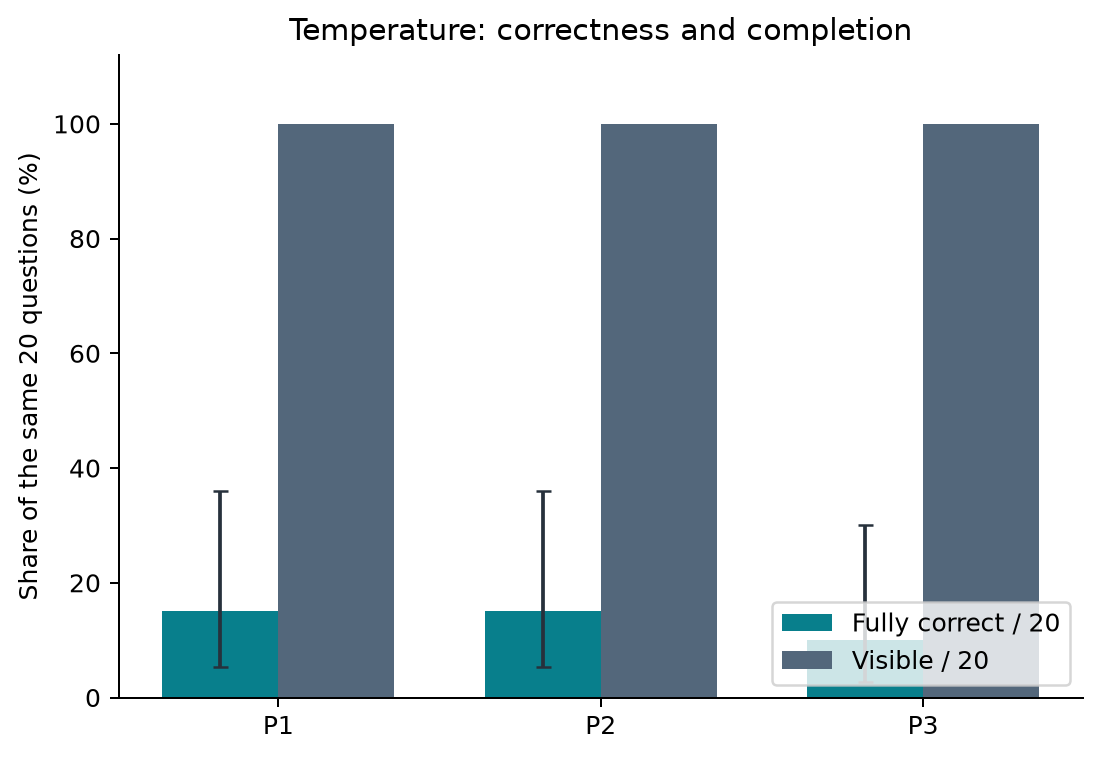

Criterion means (0–2; applicable denominators shown in table below)


,condition,field,applicable_questions,mean_score,median_score,score_0_count,score_1_count,score_2_count
0,P1,formula_integration,17,1.235294,1.0,1,11,5
1,P2,formula_integration,17,1.235294,1.0,2,9,6
2,P3,formula_integration,17,1.000000,1.0,3,11,3
3,P1,calculation_correctness,20,0.400000,0.0,15,2,3
4,P2,calculation_correctness,20,0.450000,0.0,15,1,4
5,P3,calculation_correctness,20,0.200000,0.0,18,0,2
6,P1,unit_correctness,18,1.388889,2.0,4,3,11
7,P2,unit_correctness,18,1.166667,1.0,5,5,8
8,P3,unit_correctness,18,1.166667,1.5,6,3,9
9,P1,explanation_clarity,20,0.600000,0.0,13,2,5


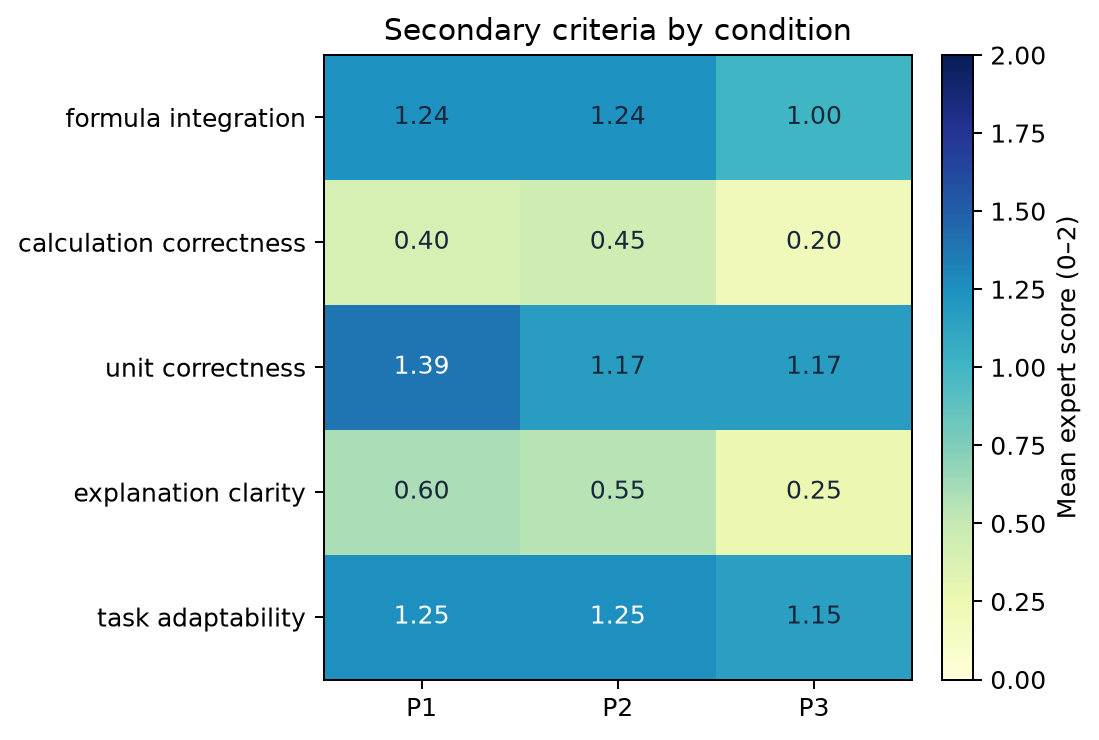

,criterion,common_applicable_questions,friedman_statistic,friedman_df,friedman_p_value,number_of_pairs
0,formula_integration,17,2.375000,2,0.304983,3
1,calculation_correctness,20,4.307692,2,0.116037,3
2,unit_correctness,18,1.542857,2,0.462352,3
3,explanation_clarity,20,5.157895,2,0.075854,3
4,task_adaptability,20,1.600000,2,0.449329,3


Paired Wilcoxon comparisons: formula_integration


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,1.00,P1,4,1.000,P2,5.0
1,0.75,P1,3,0.250,P3,0.0
2,0.75,P2,4,0.375,P3,1.5


Paired Wilcoxon comparisons: calculation_correctness


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,1.00,P1,3,1.00,P2,2.0
1,0.75,P1,3,0.25,P3,0.0
2,0.75,P2,3,0.25,P3,0.0


...

,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,1.0,P1,7,0.359375,P2,7.0
1,1.0,P1,7,0.531250,P3,10.0
2,1.0,P2,10,1.000000,P3,27.5


Paired Wilcoxon comparisons: explanation_clarity


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,1.000,P1,5,1.000,P2,6.5
1,0.375,P1,4,0.125,P3,0.0
2,0.375,P2,4,0.125,P3,0.0


Paired Wilcoxon comparisons: task_adaptability


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,1.0,P1,4,1.000,P2,5.0
1,1.0,P1,2,0.500,P3,0.0
2,1.0,P2,4,0.625,P3,2.5


In [21]:
family_results("temperature")
ordinal_results("temperature")


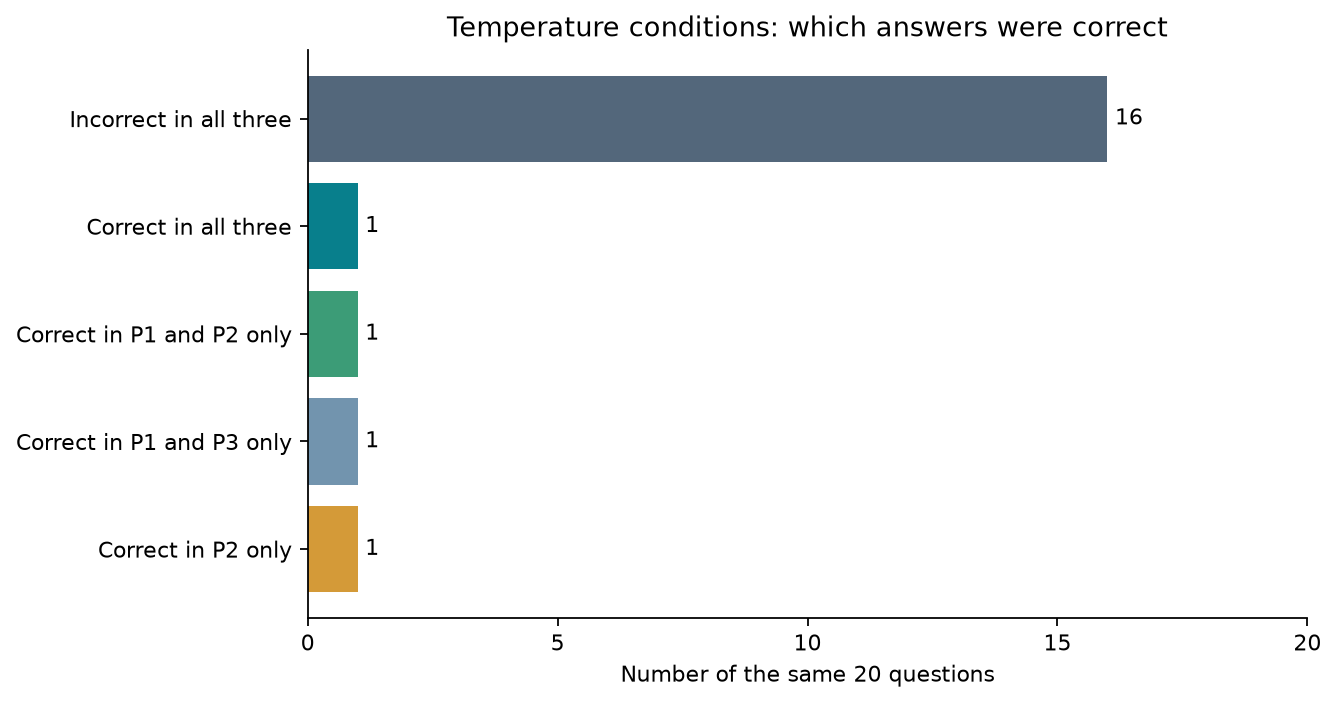

In [22]:
from io import BytesIO
from IPython.display import Image, display

temp_pairs = pairwise.loc[pairwise["family"].eq("temperature")].set_index(
    ["left_condition", "right_condition"]
)
correct = summary.set_index("condition")["correct"]

p1 = int(correct["P1"])
p2 = int(correct["P2"])
p3 = int(correct["P3"])

p1_p2 = p1 - int(temp_pairs.loc[("P1", "P2"), "left_only_correct"])
p1_p3 = p1 - int(temp_pairs.loc[("P1", "P3"), "left_only_correct"])
p2_p3 = p2 - int(temp_pairs.loc[("P2", "P3"), "left_only_correct"])

# Both P3 successes are also P1 successes, so the three-way overlap is known.
assert (p1, p2, p3) == (3, 3, 2)
assert (p1_p2, p1_p3, p2_p3) == (2, 2, 1)
all_three = p2_p3

patterns = {
    "Incorrect in all three": 20 - (
        p1 + p2 + p3 - p1_p2 - p1_p3 - p2_p3 + all_three
    ),
    "Correct in all three": all_three,
    "Correct in P1 and P2 only": p1_p2 - all_three,
    "Correct in P1 and P3 only": p1_p3 - all_three,
    "Correct in P2 only": p2 - p1_p2 - p2_p3 + all_three,
}
assert list(patterns.values()) == [16, 1, 1, 1, 1]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.barh(
    list(patterns),
    list(patterns.values()),
    color=["#53677b", "#087f8c", "#3c9c77", "#7294ae", "#d49a38"],
)
ax.invert_yaxis()
ax.set_xlim(0, 20)
ax.set_xticks([0, 5, 10, 15, 20])
ax.set_xlabel("Number of the same 20 questions")
ax.set_title("Temperature conditions: which answers were correct")
ax.spines[["top", "right"]].set_visible(False)

for bar, count in zip(bars, patterns.values()):
    ax.text(count + 0.15, bar.get_y() + bar.get_height() / 2,
            str(count), va="center")

fig.tight_layout()
buffer = BytesIO()
fig.savefig(buffer, format="png", dpi=160, bbox_inches="tight")
display(Image(data=buffer.getvalue()))
plt.close(fig)


**Finding.** Correctness is 3/20, 3/20 and 2/20. Cochran's *Q*(2) = 0.667, *p* = 0.717; all three Holm-adjusted exact McNemar *p* values are 1.000. The five secondary Friedman *p* values are above 0.05, and no pairwise secondary contrast survives its within-criterion Holm adjustment. P3 has more grounding errors and unsupported-claims flags than P1 in the published summaries, but these error frequencies are descriptive; we have no planned paired hypothesis test for each individual error category. This run does not establish a temperature-driven improvement or deterioration beyond the observed questions.


### 8.2 Temperature comparison: P1, P2 and P3 findings

We compare temperatures 0.1, 0.5 and 1.0 while keeping the GPT-4 snapshot, retrieval depth \(k=30\), prompt and 20 questions fixed. All three conditions produced a visible answer for every question.

- **The number of correct answers stayed low.** P1 and P2 each answered 3/20 correctly (15%), while P3 answered 2/20 (10%). The matched chart shows more than these totals: 16 questions were incorrect in all three conditions, and only 1 was correct in all three. P1 and P2 each had correct answers that the other did not.

- **We first test the three conditions together using Cochran's Q.** This test asks whether binary correctness differs anywhere across the three temperatures on the same questions. It gives \(Q(2)=0.667\) and \(p=0.717\). We do not find clear evidence of an overall correctness difference.

- **We then look at each matched pair using exact McNemar tests.** P1 and P2 each had one question correct that the other missed. P1 alone was correct on one question when compared with P3; for P2 versus P3, two questions favoured P2 and one favoured P3. All three Holm-adjusted \(p\) values are 1.000. Holm adjustment accounts for testing three pairs in this temperature group. These results do not establish which temperature is better.

- **The secondary-score means also show some differences, especially for P3.** Formula integration averaged 1.24, 1.24 and 1.00 for P1, P2 and P3. Calculation correctness averaged 0.40, 0.45 and 0.20; explanation clarity averaged 0.60, 0.55 and 0.25. These are observed differences on 0–2 scales, with 17 applicable questions for formulas and 20 for calculation and clarity.

- **We use the Friedman test for each secondary criterion because all three conditions answered the same questions.** The test asks whether their matched 0–2 scores differ somewhere across the temperatures. Its \(p\) values are 0.305 for formulas, 0.116 for calculation, 0.462 for units, 0.076 for clarity and 0.449 for task adaptability. None is below 0.05. None of the paired secondary comparisons is below 0.05 after its Holm adjustment either.

- **The error counts add context but are descriptive.** Grounding was the primary error for 5 P1 answers, 7 P2 answers and 9 P3 answers. Unsupported-claims flags were recorded for 14, 15 and 18 responses respectively. These counts increase across the three conditions in this run, but we have not tested a matched change in these error categories. We should not treat them as proof that raising temperature causes more grounding errors.

**Temperature conclusion.** With this GPT-4 snapshot and retrieval setup, changing temperature from 0.1 to 0.5 or 1.0 did not produce a clear improvement in correctness on the 20 benchmark questions. P3 had lower observed correctness and clarity, but the paired tests do not establish a reliable temperature effect. The small number of correct answers also limits what these comparisons can tell us.

### 8.3 Model and generation configurations: P1, M1, M2 and M3

We hold the 20 questions and retrieval k=30 fixed. P1 and M1 share temperature 0.1 and top-p 1.0; M2 and M3 use reasoning effort low with both sampling controls omitted. We therefore call these **configuration comparisons**. We test binary correctness with Cochran's Q followed by Holm-adjusted exact McNemar pairs. The 0–2 criteria use Friedman and Holm-adjusted paired Wilcoxon results; completion remains a separate outcome.


Correctness and completion on the same 20 questions


,condition,gradable_questions,correct,accuracy,wilson95_lower,wilson95_upper,visible_responses,completion_rate,no_visible_answers,unsupported_claims_count
0,P1,20,3,0.15,0.052369,0.360419,20,1.00,0,14
1,M1,20,10,0.50,0.299298,0.700702,20,1.00,0,5
2,M2,20,11,0.55,0.342085,0.741802,11,0.55,9,0
3,M3,20,20,1.00,0.838875,1.000000,20,1.00,0,0


Primary paired correctness results
Omnibus Cochran Q:


,df,no_discordance,p_value,statistic
0,3,False,7.400764e-07,31.285714


,family,left_condition,right_condition,left_only_correct,right_only_correct,discordant,p_value,holm_adjusted_p_value
0,model_generation,P1,M1,0,7,7,0.015625,0.031250
1,model_generation,P1,M2,0,8,8,0.007812,0.023438
2,model_generation,P1,M3,0,17,17,0.000015,0.000092
3,model_generation,M1,M2,2,3,5,1.000000,1.000000
4,model_generation,M1,M3,0,10,10,0.001953,0.009766
5,model_generation,M2,M3,0,9,9,0.003906,0.015625


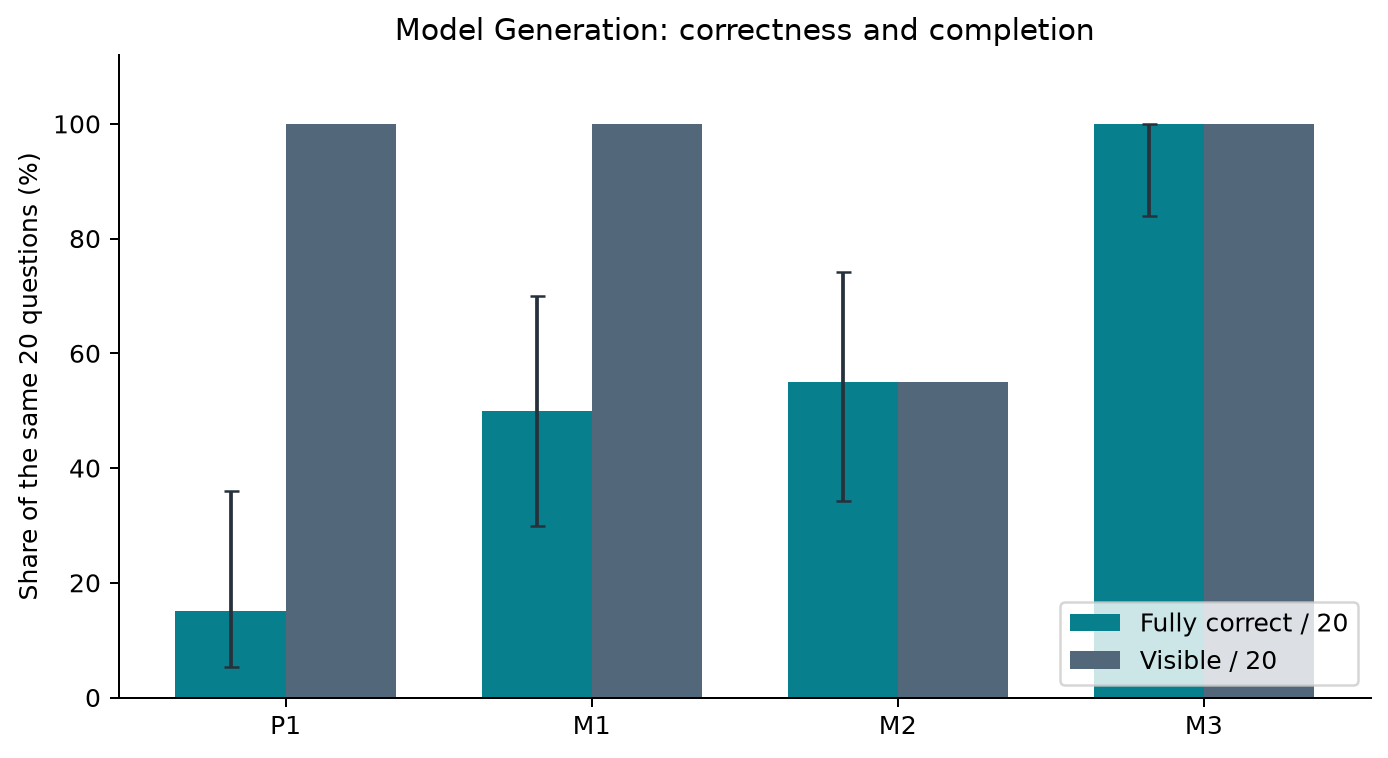

Criterion means (0–2; applicable denominators shown in table below)


,condition,field,applicable_questions,mean_score,median_score,score_0_count,score_1_count,score_2_count
0,P1,formula_integration,17,1.235294,1.0,1,11,5
1,M1,formula_integration,17,1.764706,2.0,0,4,13
2,M2,formula_integration,17,1.294118,2.0,6,0,11
3,M3,formula_integration,17,2.000000,2.0,0,0,17
4,P1,calculation_correctness,20,0.400000,0.0,15,2,3
5,M1,calculation_correctness,20,1.250000,1.5,5,5,10
6,M2,calculation_correctness,20,1.100000,2.0,9,0,11
7,M3,calculation_correctness,20,2.000000,2.0,0,0,20
8,P1,unit_correctness,18,1.388889,2.0,4,3,11
9,M1,unit_correctness,18,1.888889,2.0,0,2,16


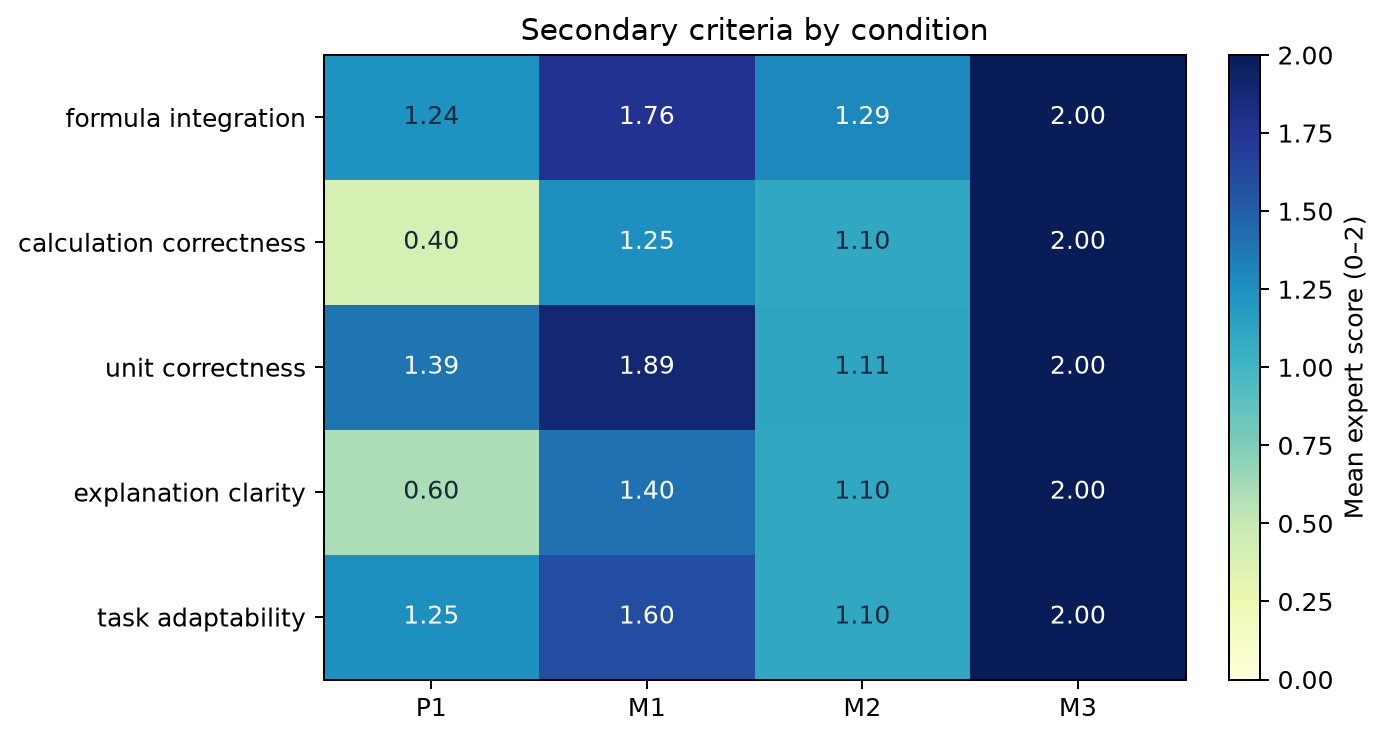

,criterion,common_applicable_questions,friedman_statistic,friedman_df,friedman_p_value,number_of_pairs
0,formula_integration,17,18.852632,3,2.932661e-04,6
1,calculation_correctness,20,31.071429,3,8.211136e-07,6
2,unit_correctness,18,15.000000,3,1.816649e-03,6
3,explanation_clarity,20,24.270270,3,2.193589e-05,6
4,task_adaptability,20,22.549180,3,5.013371e-05,6


Paired Wilcoxon comparisons: formula_integration


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,0.019531,P1,9,0.003906,M1,0.0
1,1.000000,P1,12,1.000000,M2,36.0
2,0.002930,P1,12,0.000488,M3,0.0
3,0.234375,M1,7,0.078125,M2,2.5
4,0.250000,M1,4,0.125000,M3,0.0
5,0.125000,M2,6,0.031250,M3,0.0


Paired Wilcoxon comparisons: calculation_correctness


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,0.002441,P1,12,0.000488,M1,0.0
1,0.023438,P1,9,0.011719,M2,1.5
2,0.000092,P1,17,0.000015,M3,0.0
3,0.554688,M1,9,0.554688,M2,16.5
4,0.007812,M1,10,0.001953,M3,0.0
5,0.011719,M2,9,0.003906,M3,0.0


...

,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,0.140625,P1,8,0.046875,M1,3.0
1,0.671875,P1,8,0.335938,M2,10.0
2,0.062500,P1,7,0.015625,M3,0.0
3,0.058594,M1,9,0.011719,M2,1.5
4,0.671875,M1,2,0.500000,M3,0.0
5,0.046875,M2,8,0.007812,M3,0.0


Paired Wilcoxon comparisons: explanation_clarity


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,0.023438,P1,10,0.005859,M1,1.5
1,0.140625,P1,10,0.070312,M2,9.5
2,0.000366,P1,15,0.000061,M3,0.0
3,0.250000,M1,6,0.250000,M2,4.5
4,0.046875,M1,7,0.015625,M3,0.0
5,0.019531,M2,9,0.003906,M3,0.0


Paired Wilcoxon comparisons: task_adaptability


,holm_adjusted_p_value,left_condition,nonzero_pairs,p_value,right_condition,statistic
0,0.046875,P1,7,0.015625,M1,0.0
1,0.650879,P1,16,0.650879,M2,56.0
2,0.000366,P1,15,0.000061,M3,0.0
3,0.046875,M1,10,0.017578,M2,4.5
4,0.031250,M1,8,0.007812,M3,0.0
5,0.019531,M2,9,0.003906,M3,0.0


In [23]:
family_results("model_generation")
ordinal_results("model_generation")


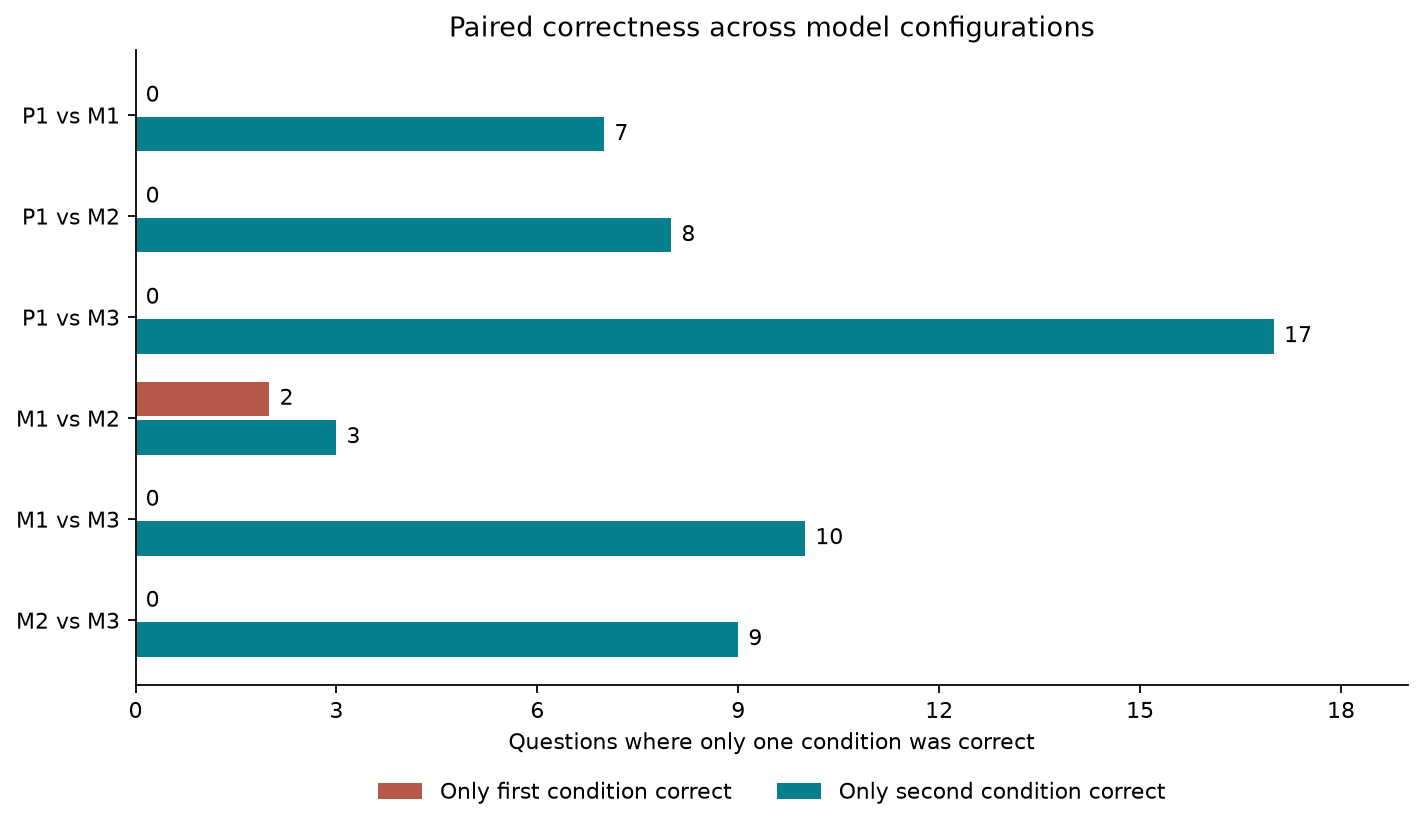

In [24]:
from io import BytesIO
from IPython.display import Image, display
import numpy as np

model_pairs = pairwise.loc[
    pairwise["family"].eq("model_generation")
].reset_index(drop=True)

labels = (
    model_pairs["left_condition"] + " vs " + model_pairs["right_condition"]
).tolist()
first_only = model_pairs["left_only_correct"].astype(int).to_numpy()
second_only = model_pairs["right_only_correct"].astype(int).to_numpy()

assert dict(zip(labels, zip(first_only, second_only))) == {
    "P1 vs M1": (0, 7),
    "P1 vs M2": (0, 8),
    "P1 vs M3": (0, 17),
    "M1 vs M2": (2, 3),
    "M1 vs M3": (0, 10),
    "M2 vs M3": (0, 9),
}

y = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 5.3))

ax.barh(
    y - 0.19, first_only, height=0.34,
    color="#b65848", label="Only first condition correct"
)
ax.barh(
    y + 0.19, second_only, height=0.34,
    color="#087f8c", label="Only second condition correct"
)

for positions, counts in ((y - 0.19, first_only), (y + 0.19, second_only)):
    for position, count in zip(positions, counts):
        ax.text(count + 0.15, position, str(count), va="center")

ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlim(0, 19)
ax.set_xticks([0, 3, 6, 9, 12, 15, 18])
ax.set_xlabel("Questions where only one condition was correct")
ax.set_title("Paired correctness across model configurations")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
buffer = BytesIO()
fig.savefig(buffer, format="png", dpi=160, bbox_inches="tight")
display(Image(data=buffer.getvalue()))
plt.close(fig)


**Finding.** Binary correctness rises from P1's 3/20 to M1's 10/20, M2's 11/20 and M3's 20/20. Cochran's *Q*(3) = 31.286 (*p* ≈ 7.40 × 10⁻⁷). Adjusted exact McNemar values versus P1 are 0.03125 (M1), 0.02344 (M2) and about 0.0000916 (M3). M3 also differs from M1 (0.00977) and M2 (0.01563); M1 and M2 do not differ on binary correctness in this test (*p* = 1.000). We also observe that M2 returns no visible answer nine times, whereas M1 and M3 return 20 visible answers. The apparent success of M2's visible responses cannot erase that completion failure.

All five model-generation Friedman tests are below 0.05, but their paired tests and Holm-adjusted values must be read **criterion by criterion** from the tables above. In particular, a high M2 score on its 11 visible answers cannot be substituted for its means on all 20 applicable answers. We do not attribute the observed differences solely to model age or intelligence: reasoning controls and supported sampling parameters differ, and the M3 requested identifier is a mutable alias.


### 8.3 Model and generation configuration comparison: findings

We compare P1, M1, M2 and M3 on the same 20 questions, with retrieval set to \(k=30\). P1 and M1 use the same temperature and `top_p`, so their comparison mainly changes the requested model snapshot. M2 and M3 use low reasoning effort and omit those sampling controls. We therefore compare the **recorded configurations**, rather than treating every difference as an effect of model identity alone.

- **Correctness differed clearly across the four configurations.** P1 answered 3/20 correctly, M1 answered 10/20, M2 answered 11/20 and M3 answered 20/20. Cochran's Q tests whether correctness differs somewhere across these four conditions on the same questions. It gives \(Q(3)=31.286\), \(p<0.001\). This tells us there is a difference somewhere, but does not identify every pair.

- **The paired chart shows which conditions gained correct answers.** In the P1–M1 comparison, M1 alone was correct on 7 questions and P1 alone on none. The corresponding counts are 8–0 for M2 against P1 and 17–0 for M3 against P1. M3 also answered 10 questions correctly that M1 missed and 9 that M2 missed, with no questions favouring M1 or M2 over M3.

- **The six exact McNemar tests check those pairs.** We use Holm-adjusted \(p\) values because we make six paired comparisons in this group. The differences for P1–M1 (\(p=0.0313\)), P1–M2 (\(p=0.0234\)), P1–M3 (\(p<0.001\)), M1–M3 (\(p=0.0098\)) and M2–M3 (\(p=0.0156\)) are below 0.05. For M1–M2, two questions favoured M1 and three favoured M2; the adjusted \(p\) value is 1.000. We do not have clear evidence that one of those two performed better on binary correctness.

- **M2's completion result changes how we read its accuracy.** It answered 11 questions visibly and all 11 were correct, but it gave no visible answer to the other 9. Those nine remain incorrect in the planned 20-question analysis. M1 answered all 20 questions and got 10 correct. M2's 11/20 and M1's 10/20 should therefore be read alongside their completion rates of 55% and 100%.

- **The secondary criteria also differ across the four configurations.** Friedman tests compare the matched 0–2 scores for each criterion. All five have \(p<0.05\). This says that scores differ somewhere within this group for each criterion; the paired Wilcoxon results show which specific pairs have evidence of a difference.

| Secondary criterion | Pairs with Holm-adjusted \(p<0.05\) |
| --- | --- |
| Formula integration | P1–M1; P1–M3 |
| Calculation correctness | P1–M1; P1–M2; P1–M3; M1–M3; M2–M3 |
| Unit correctness | M2–M3 |
| Explanation clarity | P1–M1; P1–M3; M1–M3; M2–M3 |
| Task adaptability | P1–M1; P1–M3; M1–M2; M1–M3; M2–M3 |

- **A higher mean is not always a clear paired difference.** For example, M3 has the top unit score on every applicable question, but the P1–M3 unit comparison has an adjusted \(p=0.0625\), above 0.05. We use the matched tests rather than judging differences from the heatmap colours alone. These secondary tests also involve many tied scores and separate criteria, so we use them to describe the result alongside primary correctness.

- **M2's zero secondary scores mostly reflect unavailable answers.** Its nine missing answers receive zero on calculation, clarity and adaptability under the frozen scoring rule. We should not describe those zeros as nine demonstrated mistakes in written solutions.

**Model comparison conclusion.** M1 performed better than P1 on this benchmark, while M3 answered all 20 questions correctly and scored above the other configurations in the primary paired comparisons. M1 and M2 had similar numbers of correct answers, but very different completion rates. These findings describe the frozen runs and their settings. In particular, M3 uses a mutable model alias, so its perfect result here is not a guarantee about a later run or about other questions.


## 9. Research-question synthesis for the dissertation discussion

We use the proposal's four research questions below. The analysis of 140 expert scores answers the response-quality parts. The final dissertation also needs to connect these observations to the architecture, retrieval evaluation, implementation audit and literature already documented elsewhere. We distinguish what the frozen measurements establish from what would require additional evidence.



### RQ1 - How effectively can we apply Tophel et al. (2025) to build a working geotechnical RAG tutor?

We applied the main parts of Tophel et al.’s method to build and test a textbook-based RAG prototype. We extracted teaching content from *Principles of Geotechnical Engineering*, split it into searchable passages, created embeddings, stored them in FAISS, retrieved passages for each question, and passed those passages to a language model. We then evaluated answers to the same 20 challenging textbook questions across seven configurations. This demonstrates a working **retrieval and answer-generation pipeline**. It does not, by itself, demonstrate a finished student-facing tutor or improved student learning.

| Stage                | What we implemented and checked                                                                                                                                                                                              | What it tells us                                                                                                                                                                                             |
| -------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Textbook preparation | We kept teaching content separate from textbook problems and selected answers. The final extraction contained 670 non-empty retrieval records.                                                                               | The search index was built from permitted source content, without putting benchmark questions or answers into it.                                                                                            |
| Chunking             | We used the reported `CharacterTextSplitter` settings of 200 characters and a configured overlap of 10. Our documented choice of line separator produced 5,113 chunks, none longer than 200 characters.                      | We reproduced the reported chunk size and overlap while recording the extra choices the paper did not specify. The overlap is a target, so neighbouring chunks do not always share exactly 10 characters.    |
| Search index         | We embedded all 5,113 chunks with the requested OpenAI embedding model and built an exact FAISS index. An independent audit checked the vectors, their order, their source records and sample searches.                      | The index contains the intended chunks and returns results in the checked order. This establishes that the search component was built correctly; it does not show that every result helps answer a question. |
| Retrieval            | We selected the top 30 chunks per question using a separate relevance evaluation. At this depth, at least one passage with direct evidence appeared for 19/20 questions, and at least one useful passage appeared for 20/20. | The search usually made useful textbook material available on this particular benchmark. One question had no direct evidence even within the first 40 results.                                               |
| Answer generation    | We generated and scored 140 answers: one answer to each of the 20 questions in each of seven configurations. Six configurations used retrieval at depth 30; P0 did not use retrieval.                                        | We could run the complete experiment and assess its answers under fixed rules. Answer quality must still be judged separately from whether the pipeline runs.                                                |

**Retrieval worked more often than the baseline configuration answered correctly.** The 19/20 direct-evidence result describes whether relevant material appeared somewhere among the 30 retrieved chunks. P1, our GPT-4 RAG reference at temperature 0.1, gave a fully correct answer to only 3/20 questions. Its remaining 17 answers included five classified as grounding errors, seven as conceptual errors, two as calculation errors and three as deficient answers. Its mean calculation score was 0.40/2 and its mean explanation-clarity score was 0.60/2. These results show that making source material available did not ensure that this configuration used it to produce a complete, correct solution. The aggregate counts alone cannot tell us exactly why each answer failed.

We also compared P1 with P0, the same GPT-4 snapshot answering without retrieval. P0 answered 2/20 correctly and P1 answered 3/20. Two questions were correct in both conditions, one was correct only with P1, and 17 were incorrect in both. The exact paired McNemar test gave *p* = 1.000. We therefore observed one additional correct answer with retrieval, but this small comparison does not establish a reliable improvement in answer correctness. It does not cancel the separate finding that retrieval found direct evidence for 19/20 questions: **finding evidence and using it correctly are different steps**.

The answer results also depend strongly on the generation configuration. With the same benchmark and retrieval depth, M1 answered 10/20 correctly, M2 answered 11/20 and M3 answered 20/20 in its recorded run. M2 returned visible answers for only 11/20 questions; all nine missing answers count as incorrect. M3’s requested model name was a mutable alias, so its result describes the responses we recorded rather than every future version under that name. These differences show that the working pipeline can produce substantially different outcomes under different configurations. Because their model and generation settings are not all identical, we cannot assign the differences to model identity alone.

Our implementation follows the **reported components** of Tophel et al.’s method, but it is a documented reconstruction rather than a copy of their exact system. The paper does not give enough detail to reproduce its precise PDF extraction, embedding model, retrieval depth, software versions or answer-scoring rules. We recorded and checked our own choices for these missing details. We also left uncertain mathematical symbols in the extracted text without inventing replacements, and our baseline does not reconstruct table cells or formulas from page images. These limits matter for a subject where equations, units and tables are often needed.

Tophel et al. report much higher GPT-4 percentages, including 95% at temperature 0.1. We should present those figures as background, **not subtract them from our 15% P1 result as though they measured the same outcome**. Their exact scoring calculation cannot be reconstructed from the paper: for example, 82.5% cannot result from one binary correct/incorrect judgment on exactly 20 questions. Their exact model snapshot and implementation details are also not established as identical to ours.

**Answer to RQ1.** We were able to apply the published approach effectively as a **working, auditable RAG experiment**: we built the textbook search system, found direct evidence for 19/20 benchmark questions at our selected retrieval depth, ran the answer pipeline and scored all seven planned configurations. We cannot claim that this made the GPT-4 reference a reliable tutor on these hard questions, since it answered only 3/20 correctly. Nor have we tested whether students can use the prototype effectively or learn more from it. The strongest conclusion is that the method is practical to implement and evaluate, while the quality of the final tutor answers depends on more than successful retrieval.


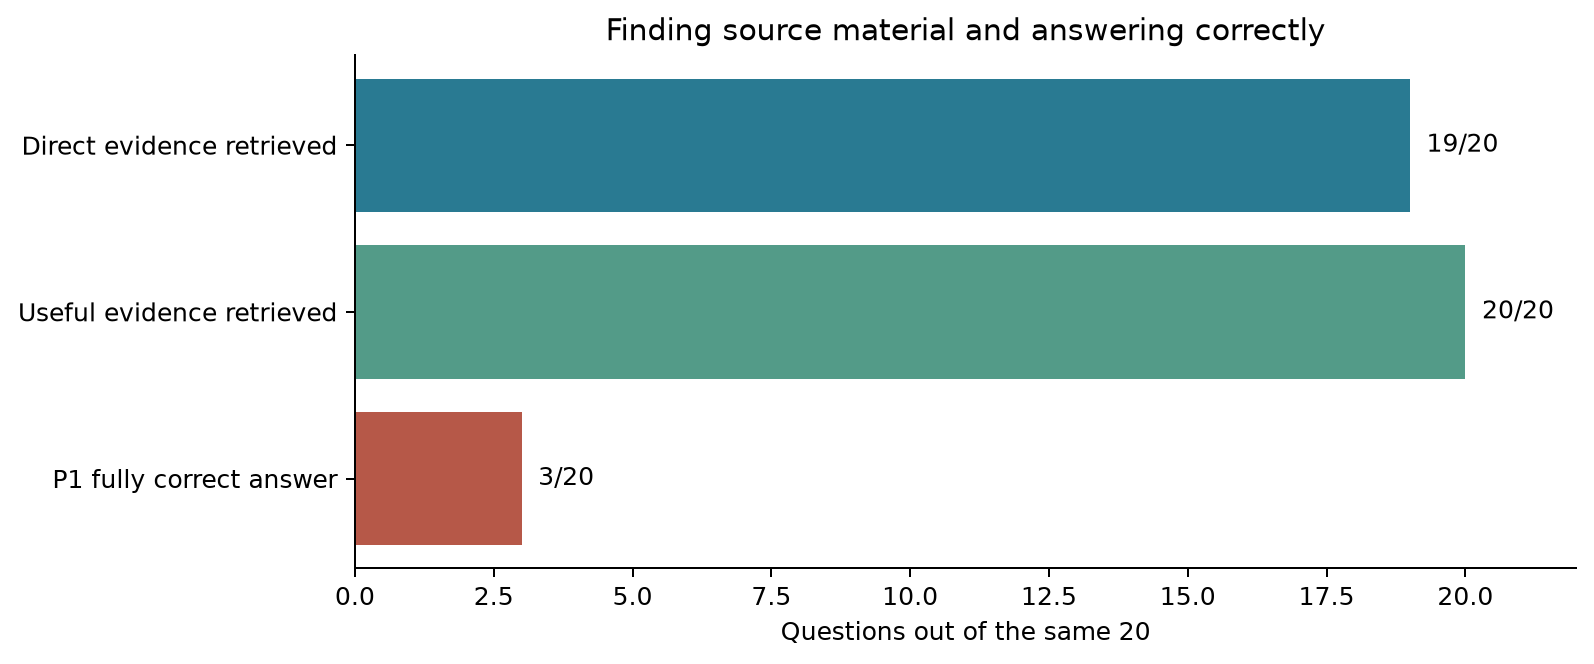

In [25]:
import re
from io import BytesIO
from IPython.display import Image, display

decision = (ROOT / "docs/retrieval-depth-selection-decision.md").read_text(
    encoding="utf-8"
)

def retrieval_count(label):
    match = re.search(
        rf"^\|\s*{re.escape(label)}\s*\|\s*(\d+)\s*/\s*(\d+)\s*\|",
        decision,
        flags=re.MULTILINE,
    )
    if match is None:
        raise ValueError(f"Could not find {label} in the retrieval decision record")
    count, total = map(int, match.groups())
    assert total == 20
    return count

direct = retrieval_count("Direct-evidence hit count")
useful = retrieval_count("Useful-evidence hit count")
p1 = summary.set_index("condition").loc["P1"]
assert int(p1["gradable_questions"]) == 20

labels = [
    "Direct evidence retrieved",
    "Useful evidence retrieved",
    "P1 fully correct answer",
]
counts = [direct, useful, int(p1["correct"])]

fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.barh(
    labels,
    counts,
    color=["#297a92", "#539b88", "#b65848"],
)
ax.invert_yaxis()
ax.set_xlim(0, 22)
ax.set_xlabel("Questions out of the same 20")
ax.set_title("Finding source material and answering correctly")
ax.spines[["top", "right"]].set_visible(False)

for bar, count in zip(bars, counts):
    ax.text(count + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{count}/20", va="center")

fig.tight_layout()
png = BytesIO()
fig.savefig(png, format="png", dpi=180, bbox_inches="tight")
display(Image(data=png.getvalue()))
plt.close(fig)

### RQ2 - How do newer models perform in this tutor setup?

Tophel et al. (2025) evaluated GPT-4 and Llama-3. In our experiment, P1 is the closest available GPT-4 reference. We compare it with three later configurations using the same 20 hard questions, textbook index, retrieval depth of 30 and tutor prompt. We did not run Llama-3, so the comparisons below are between **our own four configurations**. The paper’s published percentages provide background, but they cannot be treated as scores produced by our grading rules.

| Configuration    | Fully correct | Visible answers | Incorrect visible answers | No visible answer |
| ---------------- | ------------: | --------------: | ------------------------: | ----------------: |
| P1 - GPT-4       |          3/20 |           20/20 |                        17 |                 0 |
| M1 - GPT-4.1     |         10/20 |           20/20 |                        10 |                 0 |
| M2 - GPT-5       |         11/20 |           11/20 |                         0 |                 9 |
| M3 - GPT-6 Astra |         20/20 |           20/20 |                         0 |                 0 |

**The newer configurations gave more fully correct answers in this run.** Compared with P1, M1 answered seven additional questions correctly, M2 answered eight additional questions correctly and M3 answered 17 additional questions correctly. None of these three configurations lost a question that P1 had answered correctly. The paired comparison graph makes this clearer than percentages alone because it shows what happened on the *same questions*.

We used **Cochran’s Q** to check whether the four configurations had the same pattern of correct and incorrect answers across the 20 questions. This test is suitable here because correctness is either 0 or 1 and every configuration answered the same question set. It found a difference somewhere among the four configurations: *Q*(3) = 31.29, *p* ≈ 0.00000074. That result does not tell us which pairs differ, so we also used exact **McNemar tests**. Each McNemar test looks only at questions where one configuration was correct and the other was incorrect. We adjusted the six pairwise *p* values with the **Holm method**, because testing six pairs gives more chances to find a small *p* value by accident.

| Pair      | Correct only with the first | Correct only with the second | Holm-adjusted *p* |
| --------- | --------------------------: | ---------------------------: | ----------------: |
| P1 and M1 |                           0 |                            7 |           0.03125 |
| P1 and M2 |                           0 |                            8 |           0.02344 |
| P1 and M3 |                           0 |                           17 |          0.000092 |
| M1 and M2 |                           2 |                            3 |           1.00000 |
| M1 and M3 |                           0 |                           10 |           0.00977 |
| M2 and M3 |                           0 |                            9 |           0.01563 |

On this benchmark, the adjusted tests support a correctness difference between P1 and each later configuration. They also support a difference between M3 and each of M1 and M2. **M1 and M2 did not show a clear difference in fully correct answers**: each was better on some questions, and their totals differed by only one. A *p* value of 1.000 here does not prove that M1 and M2 perform equally.

**M2 needs a separate explanation.** All 11 answers it visibly returned were judged fully correct. However, it returned no visible answer for the other nine questions. Our main accuracy measure therefore remains **11/20**, and its completion rate is also **11/20**. Reporting only 11/11 among its visible answers would hide a major problem for a tutor: a student cannot use an answer that never appears. We have not established from these scores why those nine responses had no visible text.

The five scores from 0 to 2 add more detail. M1’s mean formula, calculation, clarity and task-adaptability scores were higher than P1’s, and those four paired differences passed the Holm-adjusted tests within their respective criteria. For example, calculation correctness rose from **0.40/2 for P1 to 1.25/2 for M1**. M2’s calculation mean was **1.10/2**, but its nine missing answers received zero where the criterion applied. M3 scored **2.00/2 on every applicable criterion** in this recorded run. These scores describe different parts of answer quality; none replaces the fully correct/20 result. We used a Friedman test for each criterion to check all four configurations together, followed by paired Wilcoxon tests with Holm adjustment within that criterion. All five Friedman tests found differences, but we should read the paired results one criterion at a time. We did not make one further adjustment across all five criteria, so these findings support the main result rather than acting as five separate proofs of it.

There are two limits when we interpret this as a comparison of model generations. **P1 and M1** have the closest matching generation controls: both use temperature 0.1 and `top_p` 1.0. **M2 and M3** use low reasoning effort and omit those sampling controls. We therefore compare the full configurations, rather than claiming that changing the model name alone caused every difference. Also, M3 was requested through a **mutable model alias**. Its 20/20 result belongs to the answers saved in this run; a later request to the same alias might use a different model version.

**Answer to RQ2.** Within our fixed tutor experiment, M1, M2 and M3 each answered more of the 20 hard questions correctly than the GPT-4 reference P1, with paired test results supporting those differences. M3 gave the strongest recorded result, while M2 showed that high correctness on returned answers can come with poor completion. These results tell us how the tested configurations performed on this benchmark. They do not establish that every newer model version will perform the same way, or that our percentages can be directly compared with those reported by Tophel et al. (2025).


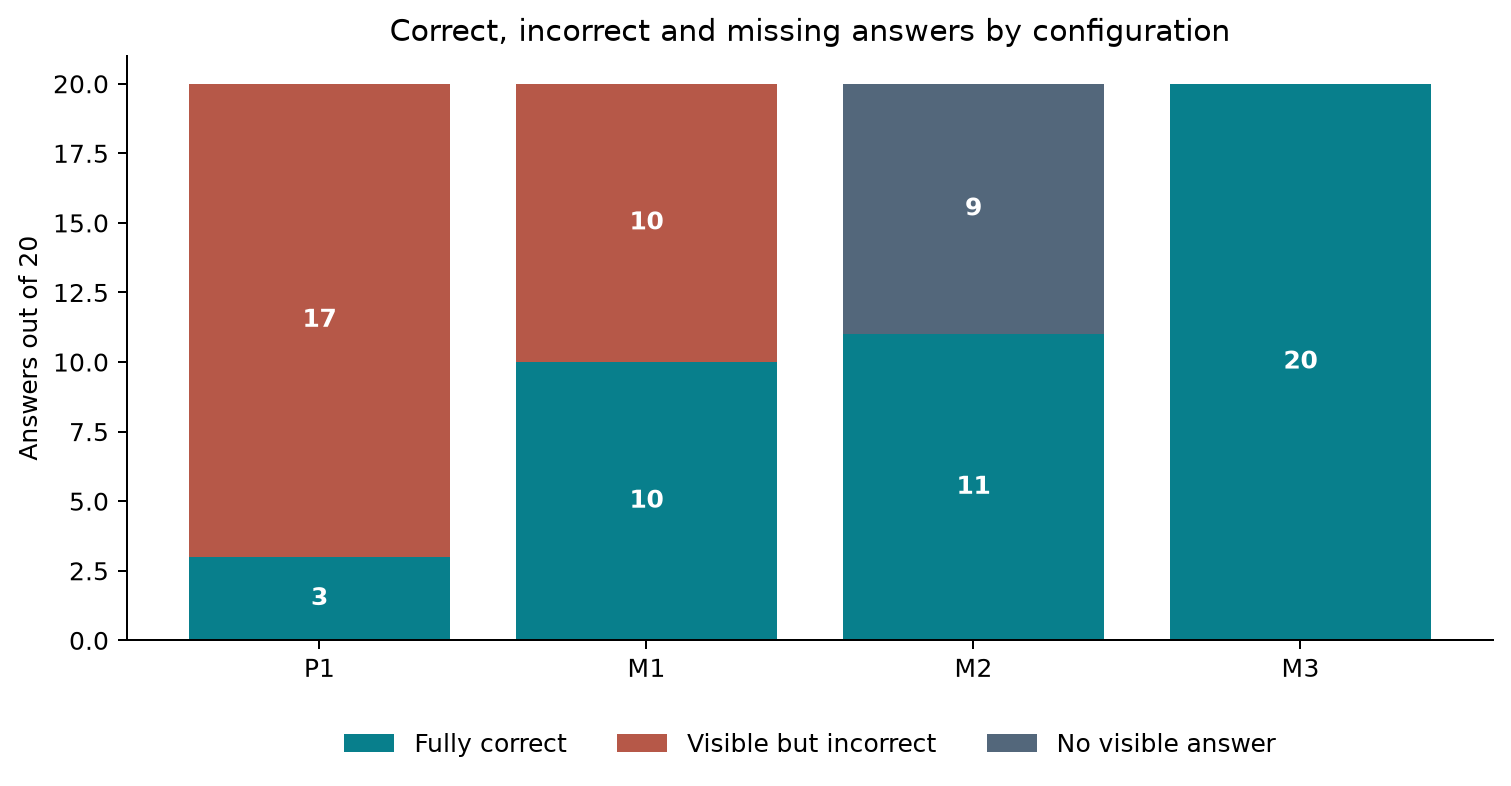

In [26]:
from io import BytesIO
from IPython.display import Image, display

names = ["P1", "M1", "M2", "M3"]
rows = summary.set_index("condition").loc[names]

correct = rows["correct"].astype(int)
visible_wrong = (
    rows["visible_responses"] - rows["correct"]
).astype(int)
missing = (
    rows["gradable_questions"] - rows["visible_responses"]
).astype(int)

assert (rows["gradable_questions"] == 20).all()
assert (visible_wrong >= 0).all()
assert (missing == rows["no_visible_answers"]).all()
assert ((correct + visible_wrong + missing) == 20).all()

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8.5, 4.5))

parts = [
    ("Fully correct", correct, "#087f8c"),
    ("Visible but incorrect", visible_wrong, "#b65848"),
    ("No visible answer", missing, "#53677b"),
]
bottom = np.zeros(len(names), dtype=int)

for label, values, color in parts:
    bars = ax.bar(x, values.to_numpy(), bottom=bottom,
                  label=label, color=color)
    for bar, value in zip(bars, values):
        if value:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                str(value),
                ha="center", va="center", color="white",
                fontweight="bold",
            )
    bottom += values.to_numpy()

ax.set_xticks(x, names)
ax.set_ylim(0, 21)
ax.set_ylabel("Answers out of 20")
ax.set_title("Correct, incorrect and missing answers by configuration")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=3, frameon=False)

fig.tight_layout()
png = BytesIO()
fig.savefig(png, format="png", dpi=180, bbox_inches="tight")
display(Image(data=png.getvalue()))
plt.close(fig)

### RQ3 - How do controlled setting changes affect accuracy and explanation quality?

We examined two changes in the final answer experiment. First, we compared the GPT-4 reference without retrieval (P0) and with retrieval at depth 30 (P1). Second, we kept retrieval and the GPT-4 snapshot fixed while changing temperature across P1, P2 and P3. Each condition answered the same 20 questions once. This lets us compare answers to the same question, rather than treating the results as separate groups of questions.

| Comparison   | Fully correct answers | Mean explanation clarity, out of 2 | What changed                                                            |
| ------------ | --------------------- | ---------------------------------- | ----------------------------------------------------------------------- |
| P0 → P1      | 2/20 → 3/20           | 0.40 → 0.60                        | Retrieval was added at `k=30`; temperature stayed at 0.1.               |
| P1 → P2 → P3 | 3/20 → 3/20 → 2/20    | 0.60 → 0.55 → 0.25                 | Temperature changed from 0.1 to 0.5 to 1.0; retrieval stayed at `k=30`. |

**Adding retrieval.** P1 gave one more fully correct answer than P0. On the paired questions, two answers were correct in both conditions, one was correct only with P1, and none was correct only with P0. The other 17 were incorrect in both. We used an exact **McNemar test** because each question has a correct/incorrect result under both settings. The test focuses on questions where those results differ. Here only **one question** differed, giving *p* = 1.000. We therefore cannot establish an improvement in fully correct answers from this comparison. Explanation clarity rose from 0.40/2 to 0.60/2, but its paired score comparison also did not pass the planned significance check. The increase is an observation from these 20 answers, not a confirmed general effect.

This does not mean the search system failed. In its separate retrieval evaluation, the selected depth of 30 found direct evidence for 19/20 questions. The P0–P1 test asks a different question: whether supplying retrieved material changed the **final graded answers** from this GPT-4 configuration. Relevant material can be retrieved without being used correctly in the response.

**Changing temperature.** P1 and P2 each answered 3/20 questions correctly; P3 answered 2/20. Sixteen questions were incorrect at **all three** temperatures. We used **Cochran’s Q** to check whether correctness differed anywhere across these three settings while accounting for the fact that they answered the same questions. It gave *Q*(2) = 0.667, *p* = 0.717. The three follow-up exact McNemar comparisons all had Holm-adjusted *p* values of 1.000. These tests do not provide evidence of a correctness difference on this benchmark.

We see a descriptive change in explanation quality at the highest temperature. Mean clarity was 0.60/2 at temperature 0.1, 0.55/2 at 0.5 and 0.25/2 at 1.0. At temperature 1.0, **17/20** explanations received a clarity score of zero, compared with **13/20** at each of the lower temperatures. Formula integration, calculation correctness and task adaptability also had lower mean scores for P3 than for P1 and P2. However, the paired tests of the 0–2 criteria did not establish a temperature difference. P3 also had nine answers classified mainly as grounding errors, compared with five for P1 and seven for P2. We did not plan a separate statistical test for each error category, so we report those counts as observations. We cannot conclude from one answer per question and temperature that increasing temperature generally causes poorer explanations or more grounding errors.

The earlier **retrieval-depth evaluation** tested a different part of the system. Direct evidence appeared for 18/20 questions within the first 25 retrieved chunks and 19/20 within the first 30. Looking through rank 40 still gave direct evidence for 19/20. We chose `k=30` using the rule fixed for that evaluation: first maximise the number of questions with direct evidence, then use the other stated tie-breakers if needed. At this depth, useful evidence was found for 20/20 questions, but only about 56% of the retrieved chunks were judged useful. The mean retrieved context was about 1,936 tokens. This shows a trade-off: asking for more chunks can bring in missing evidence, but it also adds material the model must sort through. **We did not generate and score answers at `k=25` or `k=40`**, so these retrieval figures cannot tell us whether either depth would improve final accuracy or clarity. Also, we selected the depth using these same 20 questions; it has not been shown to be the best depth for a new question set.

**Chunk size and overlap were fixed for answer generation.** We kept the paper’s reported chunk size of 200 and configured overlap of 10 in every retrieval-enabled condition. During corpus preparation, we compared ways of splitting the extracted text and chose a line boundary that kept the 5,113 final chunks within the 200-character limit while preserving their source lines. That work justified the implementation choice. It was **not** a test of how changing chunk size or overlap affects generated answers, because we did not build and evaluate alternative final answer conditions for those values.

**Answer to RQ3.** On these 20 hard questions, adding retrieval gave one additional correct GPT-4 answer, and changing temperature produced totals of three, three and two correct answers. The paired tests did not establish an accuracy or explanation-quality effect for either comparison. The separate retrieval study showed why we selected depth 30, but it measured evidence coverage rather than final answer quality. We therefore answer the question for **retrieval on/off and temperature** in this recorded run. The effects of changing retrieval depth, chunk size or overlap on final answers remain open and would need new controlled generation runs.


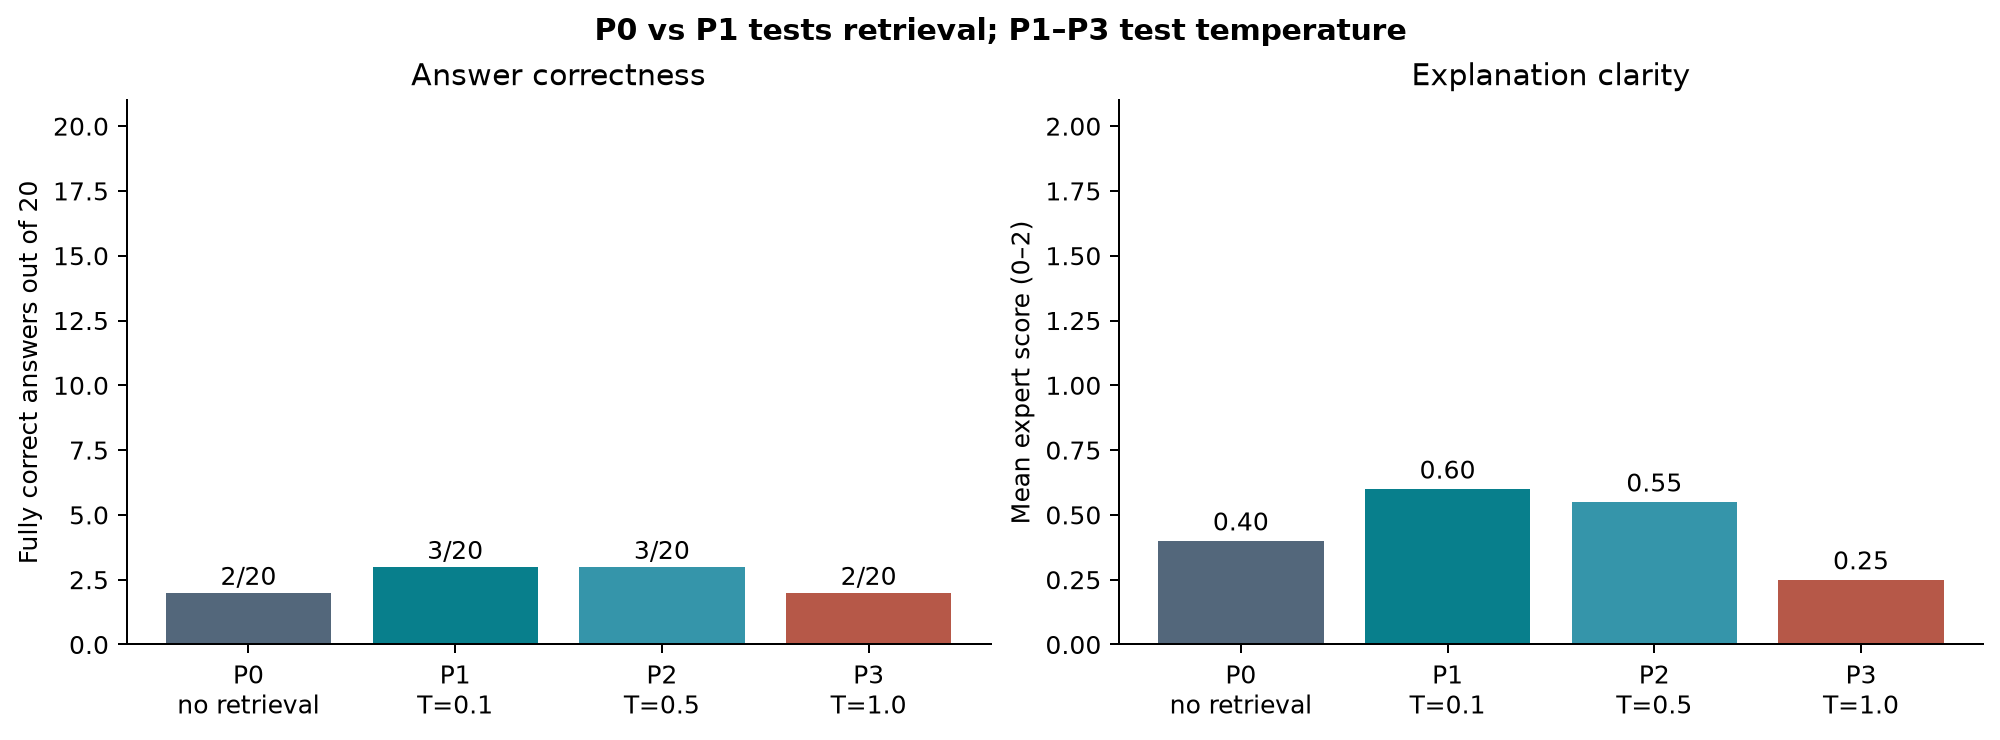

In [27]:
from io import BytesIO
from IPython.display import Image, display

names = ["P0", "P1", "P2", "P3"]
labels = ["P0\nno retrieval", "P1\nT=0.1", "P2\nT=0.5", "P3\nT=1.0"]
colors = ["#53677b", "#087f8c", "#3595aa", "#b65848"]

correct = summary.set_index("condition").loc[names, "correct"].astype(int)
clarity = secondary.set_index(["condition", "field"]).loc[
    [(name, "explanation_clarity") for name in names],
    "mean_score",
].astype(float)

assert len(correct) == len(clarity) == 4
assert (summary.set_index("condition").loc[names, "gradable_questions"] == 20).all()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")

axes[0].bar(labels, correct.to_numpy(), color=colors)
axes[0].set_ylim(0, 21)
axes[0].set_ylabel("Fully correct answers out of 20")
axes[0].set_title("Answer correctness")
for x, value in enumerate(correct):
    axes[0].text(x, value + 0.3, f"{value}/20", ha="center")

axes[1].bar(labels, clarity.to_numpy(), color=colors)
axes[1].set_ylim(0, 2.1)
axes[1].set_ylabel("Mean expert score (0–2)")
axes[1].set_title("Explanation clarity")
for x, value in enumerate(clarity):
    axes[1].text(x, value + 0.04, f"{value:.2f}", ha="center")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "P0 vs P1 tests retrieval; P1–P3 test temperature",
    fontweight="bold",
)
png = BytesIO()
fig.savefig(png, format="png", dpi=180, bbox_inches="tight")
display(Image(data=png.getvalue()))
plt.close(fig)

### RQ4 - How can we address limitations of the baseline approach?

Tophel et al. (2025) discuss difficulties with formulas and reasoning, and note that their evaluation did not provide images or graphs as inputs. Our proposal asks whether some of these limits can be addressed. Our results help us identify where the problems appear and which changes would be worth testing. We need to distinguish **better scores under a different configuration** from **a tested fix for the underlying problem**.

**Formula use and calculations.** The expert scored formula integration on the same 17 applicable questions in each condition, and calculation correctness on all 20 questions. A score of 2 is the highest score for that criterion.

| Configuration | Formula score 2 | Calculation score 2 | Fully correct answer |
| ------------- | --------------: | ------------------: | -------------------: |
| P1            |            5/17 |                3/20 |                 3/20 |
| M1            |           13/17 |               10/20 |                10/20 |
| M2            |           11/17 |               11/20 |                11/20 |
| M3            |           17/17 |               20/20 |                20/20 |

P1 often received some credit for using formulas, but it gave only three fully correct answers. This matters because including a relevant equation does not guarantee correct substitutions, calculations, units or final results. M1 received the top formula score on 13/17 applicable questions, compared with 5/17 for P1. Their paired formula-score comparison passed its within-criterion Holm adjustment (*p* = 0.01953). M3 received the top formula and calculation scores on every applicable question in its recorded run. These are meaningful improvements **on this benchmark**. We cannot say that we tested and proved a dedicated formula-repair method: the experiment changed generation configurations, and we did not add a separate formula-checking step.

There is also a limit in the source text. We preserved uncertain mathematical symbols from the textbook extraction because automatically replacing them could change the meaning of an equation. The baseline pipeline does not reconstruct those symbols or turn tables into checked mathematical records. Preserving the original extraction avoids an unverified “repair,” but it does not solve formula readability. We also cannot tell from the public totals which individual wrong answer was caused by a damaged source equation.

A clear next experiment would add **source-checked formula records** and a **calculation and unit check** before the tutor returns an answer. We would first verify each formula against its textbook page, including its conditions and units. Then we would run the current pipeline and the checked-formula version on the same new formula-heavy questions. The comparison should report fully correct answers, formula scores, calculation scores and unit scores. This would test whether the added checks actually improve results, rather than assuming they will.

**Reasoning and consistent answers.** P1’s 17 incorrect answers included seven whose main error was conceptual and five whose main error was grounding. This shows that choosing and applying the right engineering idea remained difficult for that configuration. M1 had fewer incorrect answers overall, while M3 had none in this recorded set. However, each configuration produced **one answer per question**. We did not repeat the same question several times under the same settings, so we cannot measure whether a model gives a correct answer consistently across runs. Differences between models or temperatures are not a substitute for that repeat test.

We could address this in two linked steps. First, test a check that compares the answer’s chosen method with the retrieved source, the problem’s stated conditions and the final units. Second, generate several answers per question under each fixed setting and record how often the result, method and correctness change. We would compare the checked and unchecked versions on a separate question set. A check would count as useful only if it improved correctness or consistency without creating more missing answers.

**Images, graphs and tables.** Tophel et al. point out that models were not given images or graphs as inputs, even though geotechnical problems can involve charts and diagrams. Our experiment also does not test a separate image-input method. Keeping table captions and page references during textbook extraction is useful for finding the source, but it does not mean the tutor can read values from a chart or understand a diagram. We therefore cannot claim that the multimodal limitation has been addressed.

To test it, we would need a small set of questions that genuinely require a figure, graph or structured table. The reference answers would need to specify which visual facts are required. We could then compare the current text-only pipeline with a documented image-enabled pipeline on the same questions, checking the extracted values, engineering method, final answer and explanation. We would keep those results separate from the existing 20-question experiment.

**Returning an answer at all.** Our evaluation also exposed a practical limit: M2 returned no visible answer for nine of the 20 questions. All 11 visible M2 answers were fully correct, but that does not make the nine missing answers useful to a student. We recorded them as incorrect and reported completion separately. We have not established the technical cause from the expert scores. The next step would be to inspect the saved response status and token-use records, identify where visible output was lost, and test one request or output-budget change at a time. Any improvement should be measured using both **correct answers out of all questions** and **visible answers out of all questions**.

**Answer to RQ4.** We can identify concrete ways to work on formula reliability, reasoning consistency, visual questions and missing answers. The recorded results show that some newer configurations gave much better formula, calculation and overall correctness scores on these 20 questions, especially M3. They do **not** show that we implemented and tested a targeted fix for formulas, repeated-run consistency or image understanding. Those claims require the separate comparisons described above. The current study gives us a tested baseline and clear measures for deciding whether each proposed change really helps.


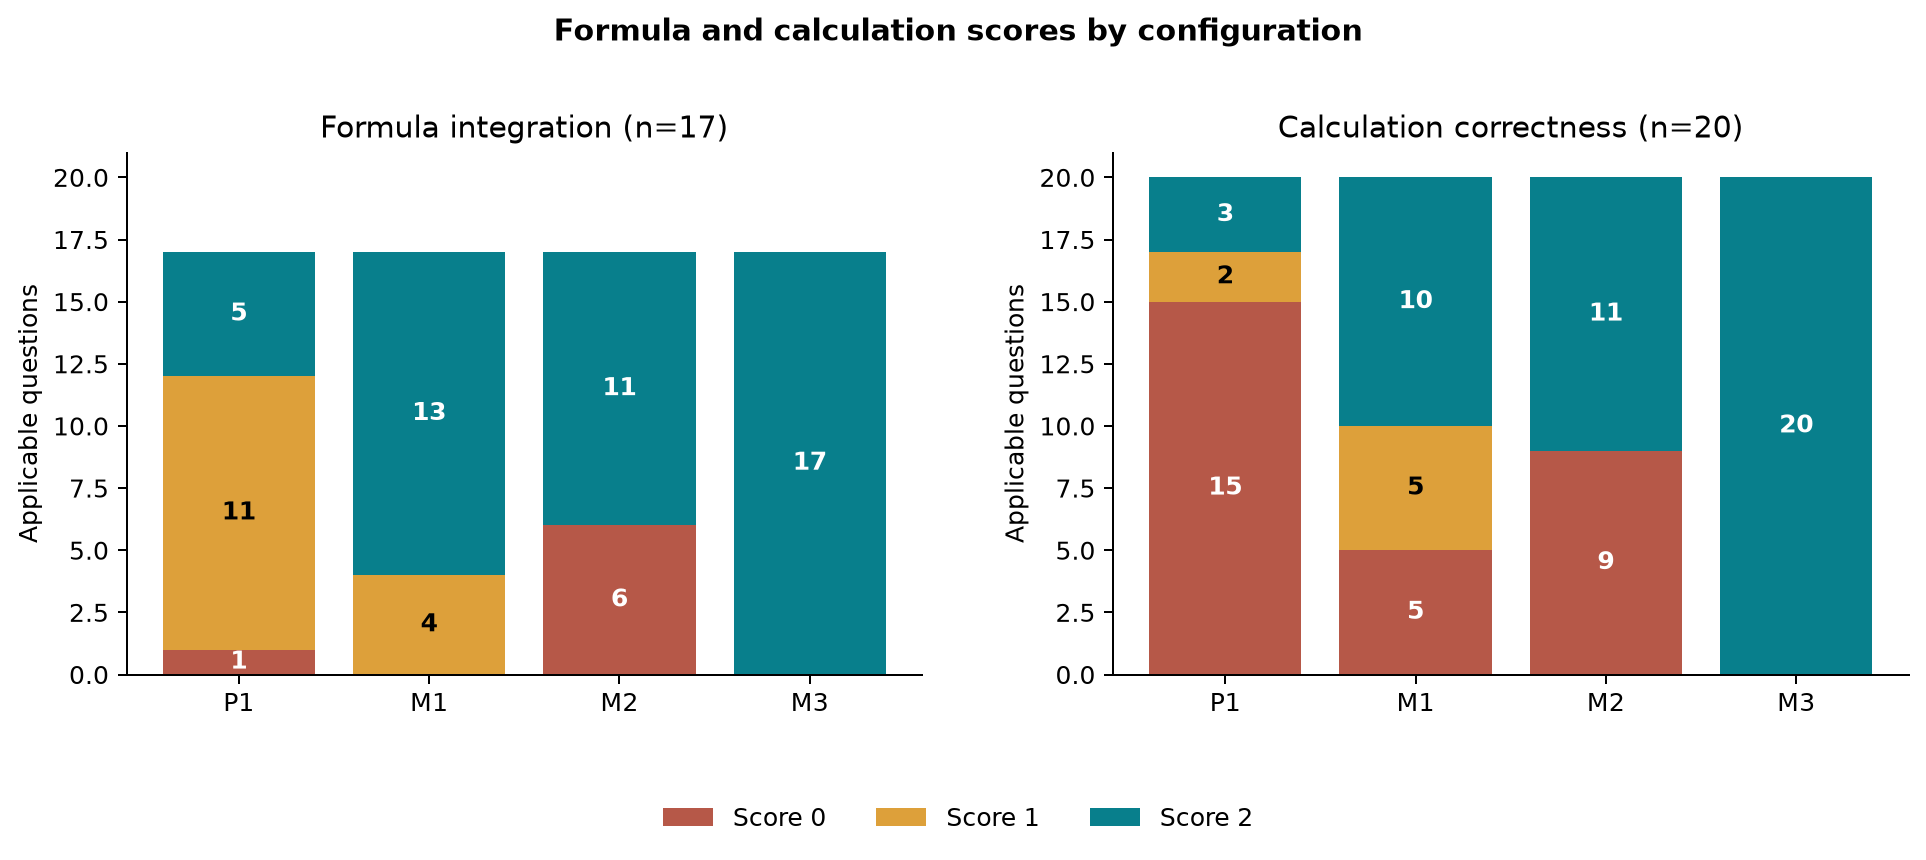

In [29]:
from io import BytesIO
from IPython.display import Image, display

names = ["P1", "M1", "M2", "M3"]
score_columns = ["score_0_count", "score_1_count", "score_2_count"]
score_labels = ["Score 0", "Score 1", "Score 2"]
score_colors = ["#b65848", "#dda03a", "#087f8c"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, field, title, expected_n in [
    (axes[0], "formula_integration", "Formula integration (n=17)", 17),
    (axes[1], "calculation_correctness", "Calculation correctness (n=20)", 20),
]:
    rows = secondary.set_index(["condition", "field"]).loc[
        [(name, field) for name in names]
    ]
    assert (rows["applicable_questions"] == expected_n).all()
    assert (rows[score_columns].sum(axis=1) == expected_n).all()

    bottom = np.zeros(len(names), dtype=int)

    for column, label, color in zip(
        score_columns, score_labels, score_colors
    ):
        values = rows[column].to_numpy(dtype=int)
        bars = ax.bar(names, values, bottom=bottom,
                      color=color, label=label)

        for bar, value in zip(bars, values):
            if value:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    str(value),
                    ha="center",
                    va="center",
                    color="black" if label == "Score 1" else "white",
                    fontweight="bold",
                )
        bottom += values

    ax.set_title(title)
    ax.set_ylabel("Applicable questions")
    ax.set_ylim(0, 21)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Formula and calculation scores by configuration",
    y=0.97,
    fontweight="bold",
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.04),
    ncol=3,
    frameon=False,
)
fig.subplots_adjust(
    left=0.08, right=0.98,
    top=0.82, bottom=0.24,
    wspace=0.24,
)

png = BytesIO()
fig.savefig(png, format="png", dpi=180, bbox_inches="tight")
display(Image(data=png.getvalue()))
plt.close(fig)

## 10. What we can conclude from this study

We built and evaluated a working textbook-based retrieval and answer pipeline. The retrieval study found direct evidence for 19/20 hard questions at our chosen depth of 30. We then scored 140 generated responses from seven configurations on those same 20 questions. These steps show that the system can be built, searched and evaluated using a recorded method.

The results also show why we must judge **the answer**, not only the search result. The GPT-4 RAG reference P1 answered 3/20 questions fully correctly even though retrieval usually found relevant material. Adding retrieval to this GPT-4 setting changed one question from incorrect to correct, but the paired test did not establish an improvement. The three tested temperatures gave 3/20, 3/20 and 2/20 correct answers, with no established difference in the planned paired tests.

The model-configuration comparison gave clearer differences on this benchmark. M1 answered 10/20 correctly, M2 answered 11/20 and M3 answered 20/20 in the recorded run. The paired results supported a difference between P1 and each of these settings. M2 also returned no visible answer for nine questions, so its 11/20 correctness must always be read together with its 11/20 completion. M3’s perfect recorded result does not establish perfect performance on future questions or under later versions of its mutable model alias.

Our formula and calculation scores help explain what “better answers” means beyond a single accuracy percentage. M1 and M3 received many more top scores than P1 on these criteria. We have **not** tested a separate formula-checking method, a visual-input method or repeated answers under the same settings. Those remain proposed experiments. We also kept chunk size and retrieval depth fixed during final answer generation, so we cannot estimate how changing either one would affect the final answers.

These conclusions have several limits. The 20 questions were selected because they are challenging; they are not a random sample of every geotechnical question. We generated one response per question and condition, so we did not measure variation between repeated runs. One expert scored the answers and saw the seven blinded responses to each question together; we have no second rater with which to measure agreement. We used Holm adjustments within each planned family of comparisons and within each secondary criterion, but not across all five secondary criteria. We therefore treat the secondary tests as supporting evidence. We also did not test student use or learning outcomes.

Our strongest conclusion is that **the method produced a working and well-recorded RAG experiment, while answer reliability depended greatly on the tested configuration**. Retrieval quality, final correctness and response completion each need their own measure. The notebook gives us evidence for the dissertation discussion and identifies the next changes to test; it does not turn untested improvements into results.
